In [1]:
import os 
import sys
sys.path.append("../../")

import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pickle
import pandas as pd 

from sklearn.metrics import r2_score 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian, decimate
from evaluation.calc_stats import * 
from scipy.stats import pearsonr 

import warnings
warnings.filterwarnings("ignore")
torch.set_warn_always(False)

torch.manual_seed(0)
np.random.seed(0)

%matplotlib inline
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

### Load spikes and neuromodulation signal

In [2]:
data_dir = '../../data/recordings/nk341_mPFC/' 
out_dir = "../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 10, 600
t_start_post_trial, t_end_post_trial = 6_669, 7_869 # nk341 mPFC
# t_start_post_trial, t_end_post_trial = 4992, 5622 # nk339 mPFC
# t_start_post_trial, t_end_post_trial = 4700, 5150 # nk340 mPFC
# t_start_post_trial, t_end_post_trial = 4848, 5848 # nk341 BLA

bin_size = 0.05
bs = 512 # batch size 
fr_threshold = 0.5

threshold_neurons = True
z_score = False
deconvolve = False 
convolve_spikes = True
normalize_neuromod = True
center = False

In [3]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'electrophysiology')
    files = [f for f in os.listdir(spikes_dir) if os.path.isfile(os.path.join(spikes_dir, f))]
    files = sorted(files)
    t_start, t_end = 0, 0
    for f in files:
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))
    
    # remove twenty seconds in the end  
    t_end = t_end - 20
    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)
    if threshold_neurons:
        rates = spike_counts.mean(axis=1) / bin_size 
        low_firing = np.where(rates < fr_threshold)[0] 
        print(f'{len(low_firing)} neurons removed') 
        spike_counts = np.delete(spike_counts, low_firing, axis=0)
    print(np.isnan(spike_counts).any())
    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    if deconvolve:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_deconvolved_2.csv', header=None).to_numpy().flatten()
    else:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_full.csv', header=None).to_numpy().flatten()
    # downsample
    fs, target_fs = 1000, 1 / bin_size
    downsample_factor = int(fs / target_fs)
    downsampled_signal = decimate(lc_neuromod, downsample_factor, ftype='fir', zero_phase=True)
    print(f'length of downsampled signal: {len(downsampled_signal)}')
    print(f'length of original signal: {len(lc_neuromod)}') 
    lc_neuromod = downsampled_signal 
    
    # select in window 
    lc_neuromod = lc_neuromod[int(t_start/bin_size):int(t_end/bin_size)]
    # replace nans with zero 
    lc_neuromod = np.nan_to_num(lc_neuromod)
    # z-score 
    if z_score:
        neuromod_activity = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    else:
        neuromod_activity = lc_neuromod
    # center 
    if center:
        neuromod_activity += np.abs(neuromod_activity.min())
    # mean-center the neurons 
    spike_counts = spike_counts - spike_counts.mean(axis=1, keepdims=True)
    # spike_counts = (spike_counts - np.expand_dims(spike_counts.mean(axis=1), -1)) / np.expand_dims(spike_counts.std(axis=1), -1)
    print(np.isnan(spike_counts).any())
    if convolve_spikes:
        kernel_size = 25
        sigma = 5
        
        gaussian_kernel = gaussian(kernel_size, sigma) 
        # Make it causal: Zero out future values
        # gaussian_kernel[:kernel_size // 2] = 0
        gaussian_kernel /= gaussian_kernel.sum()
        smoothed_spikes = []
        for n in range(spike_counts.shape[0]):
            smoothed_spikes.append(convolve(spike_counts[n], gaussian_kernel, mode='full'))
        spike_counts = np.array(smoothed_spikes)
    # load trials info 
    print(np.isnan(spike_counts).any())
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, neuromod_activity, trials_df 

In [4]:
spikes, spike_counts, neuromod_activity, trials_df = load_data()

t_end = 7869
84 neurons removed
False
length of downsampled signal: 157771
length of original signal: 7888521
False
False


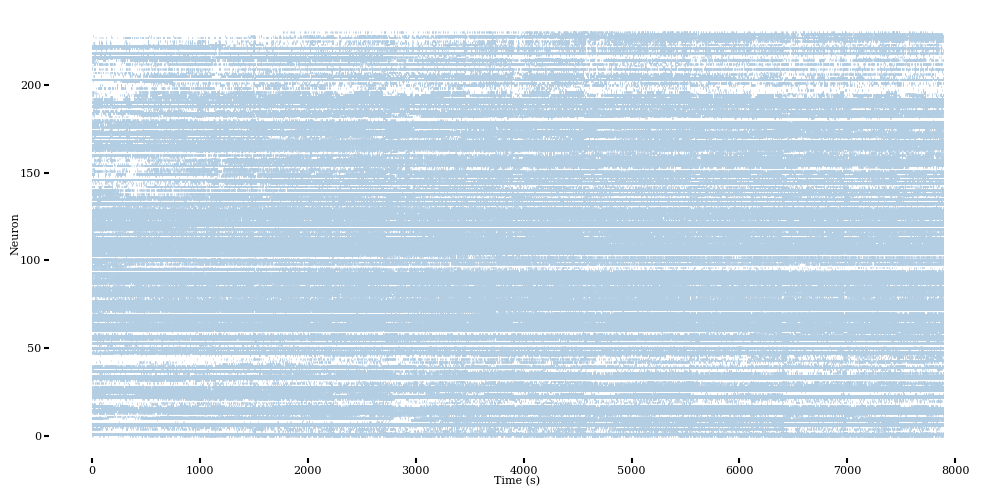

In [5]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

In [6]:
trials_df[trials_df['trialtype'] == 'ODOR-ON_1']

,id,t,trialtype,cs,us,vacuum,opto_on,opto_off,ustype,us_stop,cstype,first_lick
0,1,630.818133,ODOR-ON_1,NaN,631.343300,NaN,NaN,NaN,Odor,641.322667,NaN,631.344
1,2,671.726933,ODOR-ON_1,NaN,672.246433,NaN,NaN,NaN,Odor,682.248533,NaN,NaN
2,3,712.516267,ODOR-ON_1,NaN,713.060933,NaN,NaN,NaN,Odor,723.054933,NaN,NaN
113,114,4652.842667,ODOR-ON_1,NaN,4653.361467,NaN,NaN,NaN,Odor,4663.364267,NaN,4654.484
114,115,4693.760000,ODOR-ON_1,NaN,4694.276833,NaN,NaN,NaN,Odor,4704.256000,NaN,NaN
115,116,4734.566400,ODOR-ON_1,NaN,4735.084467,NaN,NaN,NaN,Odor,4745.088000,NaN,NaN


### Split baseline period into training and testing samples and filter out neurons with little activity

In [7]:
"""
stimulus array contains 9 variables
stimulus 0 - tone 1
stimulus 1 - tone 2
stimulus 2 - tone 3
stimulus 3 - white noise 
stimulus 4 - airpuff 
stimulus 5 - 5% sucrose 
stimulus 6 - 10% sucrose 
stimulus 7 - quinine
stimulus 8 - odor 
"""
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block 

def get_trial_blocks(trial_type):
    trial_times = trials_df[trials_df['trialtype'] == trial_type]['t'].astype('int').to_list()
    trial_blocks = []
    for t in trial_times:
        t_start, t_end = t - 10, t + 10
        trial_blocks.append([t_start, t_end])
    return trial_blocks

def get_white_noise_trial(cs):
    trial_dur = 6
    stim_arr_white_noise = np.zeros((9, int(trial_dur / bin_size),))
    trial_start = cs 
    pip_dur = 100 
    pip_interval = 200 
    stim_idx = 0
    for i in range(20):
        stim_arr_white_noise[3, int(stim_idx + pip_dur / (bin_size * 1000))] = 1.0 
        stim_idx += int(pip_dur / (bin_size * 1000)) + int(pip_interval / (bin_size * 1000))
    return stim_arr_white_noise

def get_airpuff_trial(cs, us):
    trial_dur = 13.5 # 13.5 seconds 
    tone_dur = 100 # 100 ms  
    airpuff_dur = 100 # 100 ms 
    airpuff_interval = 100 # 100 ms 
    tone_interval = 900 
    
    stim_arr_airpuff = np.zeros((9, int(trial_dur / bin_size),))
    stim_idx = 0
    for i in range(10):
        stim_arr_airpuff[2, int(stim_idx):int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(tone_interval / (bin_size * 1000))
    # now add the unconditioned stimulus 
    stim_idx = (us - cs) / bin_size 
    for i in range(15):
        stim_arr_airpuff[4, int(stim_idx):int(stim_idx + airpuff_dur / (bin_size * 1000))] = 1.0 
        stim_idx += int(airpuff_dur / (bin_size * 1000)) + int(airpuff_interval / (bin_size * 1000))
    return stim_arr_airpuff

def get_reward_block(block_idx):
    block_start_idx = 7 * block_idx 
    trial_dur = 215 # 215s
    tone_dur = 1000 # 1000 ms
    lag_dur = 500 # 500 ms
    reward_dur = 2000 # 2000

    stim_arr_reward = np.zeros((9, int(trial_dur / bin_size),))
    trial_blocks = []
    # Add 4 trials of reward 1
    reward_1_us = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_1_LAG_2000_VACUUM_1']['cs'].to_list()[block_start_idx:block_start_idx + 7]
    for i in range(4):
        tone_1_onset = reward_1_us[i]
        trial_start = (tone_1_onset - reward_1_us[0]) // bin_size
        stim_idx = int(trial_start)
        # Add 1s tone 
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # Provide reward 
        stim_arr_reward[5, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0
        trial_blocks.append([trial_start, int(stim_idx + reward_dur / (bin_size * 1000))])
        
    # omission (tone without reward)
    omission_onset = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_2500']['cs'].to_list()[block_idx]
    trial_start = (omission_onset - reward_1_us[0]) / bin_size 
    stim_idx = int(trial_start) 
    stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
    trial_blocks.append([trial_start, int(stim_idx + tone_dur / (bin_size * 1000))])

    # reward 2 
    reward_2_us = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_2_LAG_2000_VACUUM_1']['cs'].to_list()[block_idx*3:block_idx*3 +3]
    for i in range(3):
        trial_start = (reward_2_us[i] - reward_1_us[0]) // bin_size 
        stim_idx = int(trial_start)
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # provide 10% sucrose drop 
        stim_arr_reward[6, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0 
        stim_idx += reward_dur / (bin_size * 1000)
        trial_blocks.append([trial_start, int(stim_idx)])
        
    # quinine 
    quinine_onset = trials_df[trials_df['trialtype'] == 'TONE_1_LAG_500_REW_3_LAG_2000_VACUUM_1']['cs'].to_list()[block_idx]
    trial_start = (quinine_onset - reward_1_us[0]) / bin_size
    stim_idx = int(trial_start)
    stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
    stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
    # provide quinine drop 
    stim_arr_reward[7, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0    
    stim_idx += int(reward_dur / (bin_size * 1000))
    trial_blocks.append([trial_start, stim_idx])

    # reward 1 again 
    for i in range(4, 7):
        tone_1_onset = reward_1_us[i]
        trial_start = (tone_1_onset - reward_1_us[0]) // bin_size
        stim_idx = int(trial_start)
        # Add 1s tone 
        stim_arr_reward[0, stim_idx:int(stim_idx + tone_dur / (bin_size * 1000))] = 1.0
        stim_idx += int(tone_dur / (bin_size * 1000)) + int(lag_dur / (bin_size * 1000))
        # Provide reward 
        stim_arr_reward[5, stim_idx:int(stim_idx + reward_dur / (bin_size * 1000))] = 1.0
        trial_blocks.append([trial_start, int(stim_idx + reward_dur / (bin_size * 1000))])
    return stim_arr_reward, trial_blocks, reward_1_us[0]


## Analysis of models trained on baseline period

In [8]:
# define training samples
x_train = None 
s_train = None 
stim_arr_train = None 

spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
x_train = [spike_counts_pt_baseline]
s_train = [s_pt_baseline] 
stim_arr_train = [np.zeros((9, s_pt_baseline.shape[0]))]
seq_periods = [[0, s_pt_baseline.shape[0]]]
# get first 4 white noise blocks 
white_noise_trial_dur = 6 # 6 seconds
white_noise_trials_cs = trials_df[trials_df['trialtype'] == 'TONE_2']['cs'].to_list()
zero_arr = np.zeros((9, int(15 / bin_size))) 

for trial_idx, trial in enumerate(white_noise_trials_cs):
    spike_counts_white_noise, s_white_noise = get_block(spike_counts, neuromod_activity, trial, trial + white_noise_trial_dur)
    # get stimulus 
    stim_white_noise_trial = get_white_noise_trial(trial) 
    x_train.append(spike_counts_white_noise)
    s_train.append(s_white_noise) 
    stim_arr_train.append(stim_white_noise_trial) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_white_noise.shape[0]])

# get first 3 airpuff blocks 
airpuff_trial_dur = 13.5
airpuff_trial_cs = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['cs'].to_list()
airpuff_trial_us = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['us'].to_list()

for trial_idx, trial in enumerate(airpuff_trial_cs):
    spike_counts_airpuff, s_airpuff = get_block(spike_counts, neuromod_activity, trial, trial + airpuff_trial_dur)
    us = airpuff_trial_us[trial_idx]
    stim_airpuff = get_airpuff_trial(trial, us) 

    x_train.append(spike_counts_airpuff)
    s_train.append(s_airpuff) 
    stim_arr_train.append(stim_airpuff) 
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_airpuff.shape[0]])

# get first 7 reward blocks
# fig, ax = plt.subplots(4, 1, figsize=(10, 15))
reward_eval_blocks = []
for i in range(7):
    # get stimuli 
    stim_arr_rewards, trial_blocks, reward_trial_start = get_reward_block(i)
    spike_counts_reward, s_reward = get_block(spike_counts, neuromod_activity,reward_trial_start, reward_trial_start + 215)
    # s_reward = (s_reward - s_reward.min()) / (s_reward.max() - s_reward.min()) 
    
    x_train.append(spike_counts_reward)
    s_train.append(s_reward)
    stim_arr_train.append(stim_arr_rewards)
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_reward.shape[0]])

    reward_eval_blocks.append(trial_blocks)

# get all 6 odor trials 
odor_trials_cs = trials_df[trials_df['trialtype'] == 'ODOR-ON_1']['us'].to_list()
odor_trial_dur = 10 # 10s each 
for trial_idx, trial in enumerate(odor_trials_cs):
    spike_counts_odor, s_odor = get_block(spike_counts, neuromod_activity, trial, trial + odor_trial_dur)
    stim_odor = np.zeros((9, len(s_odor)))
    x_train.append(spike_counts_odor)
    s_train.append(s_odor)
    stim_arr_train.append(stim_odor)
    seq_periods.append([seq_periods[-1][1], seq_periods[-1][1] + s_odor.shape[0]])

x_train = np.hstack(x_train)
s_train = np.hstack(s_train) 
stim_arr_train = np.hstack(stim_arr_train) 
max_neuromod = s_train.max()
min_neuromod = s_train.min()
# normalize neuromdoulators 
s_train = (s_train - s_train.min()) / (s_train.max() - s_train.min())

In [11]:
len(seq_periods)

28

### Load models

In [143]:
models = {}
# neuromodulation = ['None', 'additive', 'postsynaptic', 'presynaptic', 'rank']
# for neuromod in neuromodulation:
#     try:
#         vae, params, task_params, training_params = load_model(f'../../models/dtt/all_{neuromod}_rank_20_147_baseline')
#         models[neuromod] = vae
#     except: 
#         print(f'Not found: {neuromod}')  
model_names = ['None_stim', 'additive_stim', 'postsynaptic_stim']
seeds = [0, 4, 5]
model = {}
for i, model in enumerate(model_names):
    if 'stim' in model:
        model_name = model.split('_')[0]
        vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model_name}_rank_20_seed_{seeds[i]}_stim')
    else:
        vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model}_rank_20_seed_{seeds[i]}')
    models[model] = vae

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_u', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_u', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1


### 2. Baseline evaluation

#### 2.1. Generate spikes for baseline testing period

In [9]:
def get_trajectory(t_start, t_end, vae, neuromod, stim, use_index=False):
    """
    Args:
        t_start (int): bin index in which to start the trajectory
        t_end (int): bin index in which to end the trajectory 
        vae (VAE): the model 
        neuromod: the neuromodulation type
    Returns:
        obs (torch.tensor; num_neurons x T): Generated trajectory
    """
    if use_index:
        spike_counts_val, neuromod_val = x_train[:, t_start:t_end], s_train[t_start:t_end]
        s_test_block = torch.from_numpy(neuromod_val).view(1, 1, -1).to(torch.float32)
    else:
        spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
        s_test_block = None 
        
    T = neuromod_val.shape[0]
    spike_counts_val = torch.from_numpy(spike_counts_val).to(torch.float32)
    z_hat, _, _, _ = vae.encoder(spike_counts_val.unsqueeze(0))
    z0 = z_hat[:, :, 0].squeeze()
    if stim is not None:
        sim_v = True
    else:
        stim=None 
        sim_v = False
    if 'deconv' in neuromod:
        s_test_block = torch.from_numpy(neuromod_activity_deconv_val).to(torch.float32).view(1, 1, -1)
    elif 'whisking' in neuromod:
        s_test_block = torch.from_numpy(whisking_val).to(torch.float32).view(1, 1, -1)
    elif 'None' not in neuromod and use_index == False:
        s_test_block = torch.from_numpy(neuromod_val).to(torch.float32).view(1, 1, -1)
        s_test_block = (s_test_block - min_neuromod) / (max_neuromod - min_neuromod) 
    if 'additive' in neuromod:
        if stim is None:
            Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s=True)
            # print(type(S))
            # print(S)
            obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
        else:
            Z, V, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim.unsqueeze(0), s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s=True)
            obs = vae.rnn.get_observation(Z, s=S, v=V, noise_scale=0)[0, :, :, 0]
    elif 'None' in neuromod:
        if stim is None:
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim, noise_scale=1, sim_v=sim_v, sim_s=False)
            obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
        else:   
            Z, V = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim if stim is None else stim.unsqueeze(0), noise_scale=1, sim_v=sim_v, sim_s=False)
            obs = vae.rnn.get_observation(Z, v=V, noise_scale=0)[0, :, :, 0]
    else: 
        if stim is None:
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim, s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s = False)
            obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
        else:
            Z, V = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, u=stim if stim is None else stim.unsqueeze(0), s=s_test_block, noise_scale=1, sim_v=sim_v, sim_s = False)
            obs = vae.rnn.get_observation(Z, v=V, noise_scale=0)[0, :, :, 0]
    return obs 



In [21]:
def plot_bar(stats: np.array, block_idx: int, title, width=0.4):
    means = [stats[model].mean(axis=0)[block_idx] for model in stats.keys()]
    stds = [stats[model].std(axis=0)[block_idx] for model in stats.keys()] 
    std_err = [stds[i] / len(stats[model]) for i, model in enumerate(stats.keys())]

    x = np.arange(len(means))
    fig, ax = plt.subplots(figsize=(10,8))
    ax.bar(x, means, width, yerr=std_err, alpha=0.7, capsize=5)

    for i, cat in enumerate(stats.keys()):
        x_jittered = x[i] + np.random.uniform(-width/4, width/4, stats[cat].shape[0])
        ax.scatter(x_jittered, stats[cat][:, block_idx], s=10)
    ax.set_xticklabels(list(model_mres.keys()))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xticks(x)
    ax.set_title(title, fontsize=15)

def plot_group_bar(stats: np.array, title, width=0.1):
    means = {block: [stats[model].mean(axis=0)[block] for model in stats.keys()] for block in range(3)}
    stds = {block: [stats[model].std(axis=0)[block] for model in stats.keys()] for block in range(3)}
    
    x = np.arange(len(list(means.keys())))
    print(len(x))
    fig, ax = plt.subplots(figsize=(10, 8)) 
    for i, group in enumerate(stats.keys()):
        offsets = x - width / 2 + i * width 
        mean_values = [means[block][i] for block in range(len(list(means.keys())))]
        ax.bar(offsets, mean_values, width, label=group, alpha=0.7)

In [ ]:
model_kl_divs, model_mres, model_pshs

In [ ]:
plot_bar(model_mres, 0, 'Mean-rate error')

In [ ]:
plot_bar(model_kl_divs, 0, 'KL-Divergence')

In [ ]:
plot_bar(model_pshs, 0, 'Hellinger Distance')

In [ ]:
model_set

In [69]:
def plot_raw_traces(tch, num_neurons, num_cols, column_titles, stud, figsize=(6, 6), T=1000):
    num_rows, num_cols = num_neurons, num_cols
    with plt.rc_context({'font.size': 4}):
        fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
        c = ['r', 'g', 'blue', 'black', 'orange', 'brown']
        column_titles = ["Ground Truth"] + list(column_titles) 
        print(column_titles)
        neurons = np.random.choice(range(0, 94), size=num_neurons, replace=False)
        # Set titles for the top row
        for col, title in enumerate(column_titles):
            ax[0, col].set_title(title, fontsize=12)
        for i, neuron in enumerate(neurons):
            ax[i, 0].plot(tch[neuron, :T], c=c[0])
            ymin, ymax = tch[neuron, :].min(), tch[neuron, :].max()
            for j in range(len(model_set)):
                ax[i, j+1].plot(stud[j][neuron, :T], label=list(model_set)[j], c=c[j+1])
                ymin = min(ymin, stud[j][neuron, :T].min())
                ymax = max(ymax, stud[j][neuron, :T].max())
                # ax[i, j+1].set_yticks([])
            for j in range(0, len(list(model_set)) + 1):
                ax[i, j].set_ylim(ymin, ymax)
                ax[i, j].set_xticks([])
                if j == 0:
                    ax[i, j].set_yticks([round(ymin.item(), 1), round(ymax.item(), 1)])
                ax[i, j].tick_params(axis='both', labelsize=7)
        # plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    # fig.savefig('traces.svg', format='svg', bbox_inches='tight')

In [10]:
def compute_population_cross_corr(sig1, sig2):
    corrs = []
    for i in range(sig1.shape[0]):
        corrs.append(np.correlate(sig1[i], sig2, mode='full'))
    return np.array(corrs)

### Compute psth around neuromodulator peaks

In [128]:
def compute_LC_trig_activity(traj, neuromod_val, dur=200): 
    neuromod_zsc = (neuromod_val - neuromod_val.mean()) / neuromod_val.std() 
    # take everything above 2 standard deviations 
    neuromod_peaks = np.where(neuromod_zsc > 2)[0]
    psths_val = np.zeros((len(neuromod_peaks), traj.shape[0], dur))
    nrpn = np.zeros((len(neuromod_peaks), dur))
    for i, peak in enumerate(neuromod_peaks):
        psths_val[i] = traj[:, peak - dur // 2:peak + dur // 2]
        nrpn[i] = neuromod_val[peak - dur // 2:peak + dur // 2]
    psths_val = psths_val.mean(axis=0)
    # sort by time of peak
    max_indices = np.argmax(psths_val, axis=1)
    psths_sorted = psths_val[np.argsort(max_indices)]
    psths_sorted = (psths_sorted - psths_sorted.mean(axis=1, keepdims=True)) / psths_sorted.std(axis=1, keepdims=True)
    nrpn = nrpn.mean(axis=0)
    return psths_val, psths_sorted, nrpn, max_indices

4692 4992
(184, 6000)


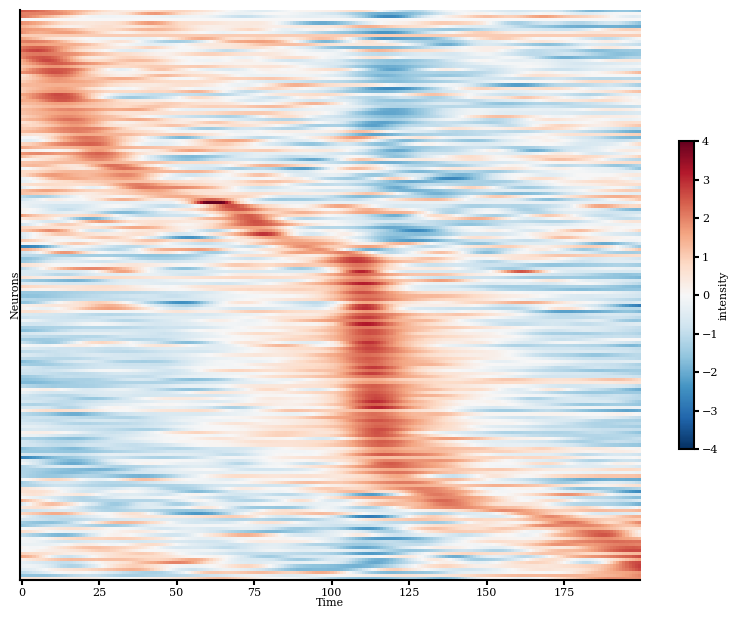

In [148]:
t_start, t_end = t_start_post_trial - 300, t_start_post_trial 
# t_start, t_end = odor_blocks[-1][0] - 10, odor_blocks[-1][1] + 10
print(t_start, t_end)
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
print(spike_counts_val.shape)
_, psths_val, nrpn, ind_test = compute_LC_trig_activity(spike_counts_val, neuromod_val, dur=200)
psths_val = np.nan_to_num(psths_val)
fig, ax = plt.subplots(figsize=(10, 8))
mappable = ax.imshow(psths_val, cmap='RdBu_r', vmin=-4, vmax=4)
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel('Neurons')
ax.set_xlabel('Time')
fig.colorbar(mappable, label='intensity', shrink=0.5)
# ax.set_title('Peak LC triggered neural activity in validation set')
plt.show()
fig.savefig('LC_trig_activity.png')


In [157]:
models.keys()

dict_keys(['None_stim', 'additive_stim', 'postsynaptic_stim'])

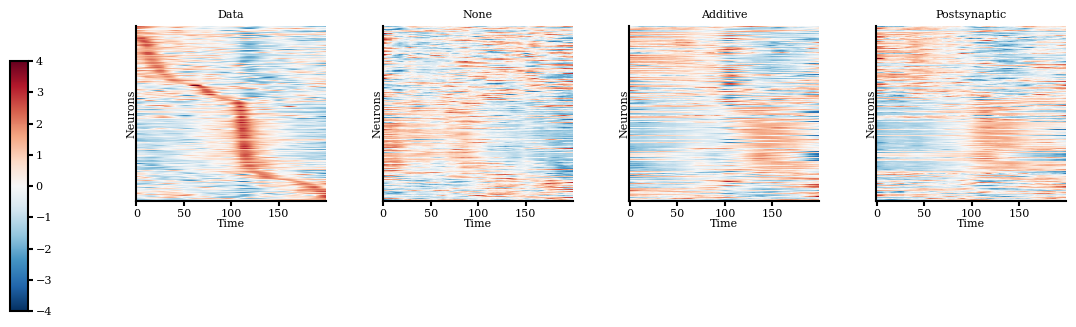

In [161]:
trajs = {}
fig = plt.figure(figsize=(12,5))
gs = gridspec.GridSpec(1, len(models) + 1, wspace=0.3)
# Create 5 subplots
ax = [fig.add_subplot(gs[0, i]) for i in range(len(models) + 1)]

mappable = ax[0].imshow(psths_val, cmap='RdBu_r', vmin=-4, vmax=4)
ax[0].set_yticks([])
ax[0].set_yticklabels([])
ax[0].set_ylabel('Neurons')
ax[0].set_xlabel('Time')
ax[0].set_title('Data')

num_trajs = 25
model_types = ['None', 'Additive', 'Postsynaptic']
for i, model in enumerate(models.keys()):
    neuromod = model
    stim = torch.zeros((9, spike_counts_val.shape[1]))
    if 'stim' not in neuromod: stim=None
    trajs[neuromod] = []
    for j in range(num_trajs):
        trajs[neuromod].append(get_trajectory(t_start, t_end, models[model], neuromod, stim=stim))
    trajs[neuromod] = torch.stack(trajs[neuromod]).mean(axis=0)
    psth_vals, psths, nrpn, ind_1 = compute_LC_trig_activity(trajs[neuromod].detach(), neuromod_val, dur=200)
    psths_resorted = psth_vals[np.argsort(ind_test)]
    psths_resorted = (psths_resorted - psths_resorted.mean(axis=1, keepdims=True)) / psths_resorted.std(axis=1, keepdims=True)
    mappable2 = ax[i+1].imshow(psths_resorted, cmap='RdBu_r', vmin=-4, vmax=4)

    ax[i+1].set_yticks([])
    ax[i+1].set_yticklabels([])
    ax[i+1].set_ylabel('Neurons')
    ax[i+1].set_xlabel('Time')

    ax[i+1].set_yticks([])
    ax[i+1].set_yticklabels([])
    # ax[i+1].set_ylabel('Neurons')
    # ax[i+1].set_xlabel('Time')
    # fig.colorbar(mappable1, label='intensity', shrink=0.5)
    ax[i+1].set_title(f'{model_types[i]}')
    # break
     
# plt.tight_layout()
cbar_ax = fig.add_axes([0.02, 0.1, 0.015, 0.5])  # smaller, centered vertically
fig.savefig('../../results/figures/psth_neuromod_peaks.png')
fig.colorbar(mappable, cax=cbar_ax)

In [140]:
def plot_traces(neurons, traj, spike_counts_block, neuromod_block, neuromod):
    fig, ax = plt.subplots(len(neurons) + 1, 1, figsize=(10, 14))

    for i, neuron in enumerate(neurons): 
        if i == 0:
            ax[i].plot(spike_counts_block[neuron], label='Test')
            ax[i].plot(traj[neuron].detach(), label='Gen')
        else:
            ax[i].plot(spike_counts_block[neuron])
            ax[i].plot(traj[neuron].detach())
        ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')
    handles, labels = [], []
    for axis in ax:  # Loop through all axes
        h, l = axis.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax[-1].plot(neuromod_block, color='teal')
    ax[-1].set_title('Norepinephrine')
    plt.tight_layout()
    # plt.title(f'{neuromod} Traces')
    fig.legend(handles, labels)
    fig.savefig(f'{neuromod}_traces.png')

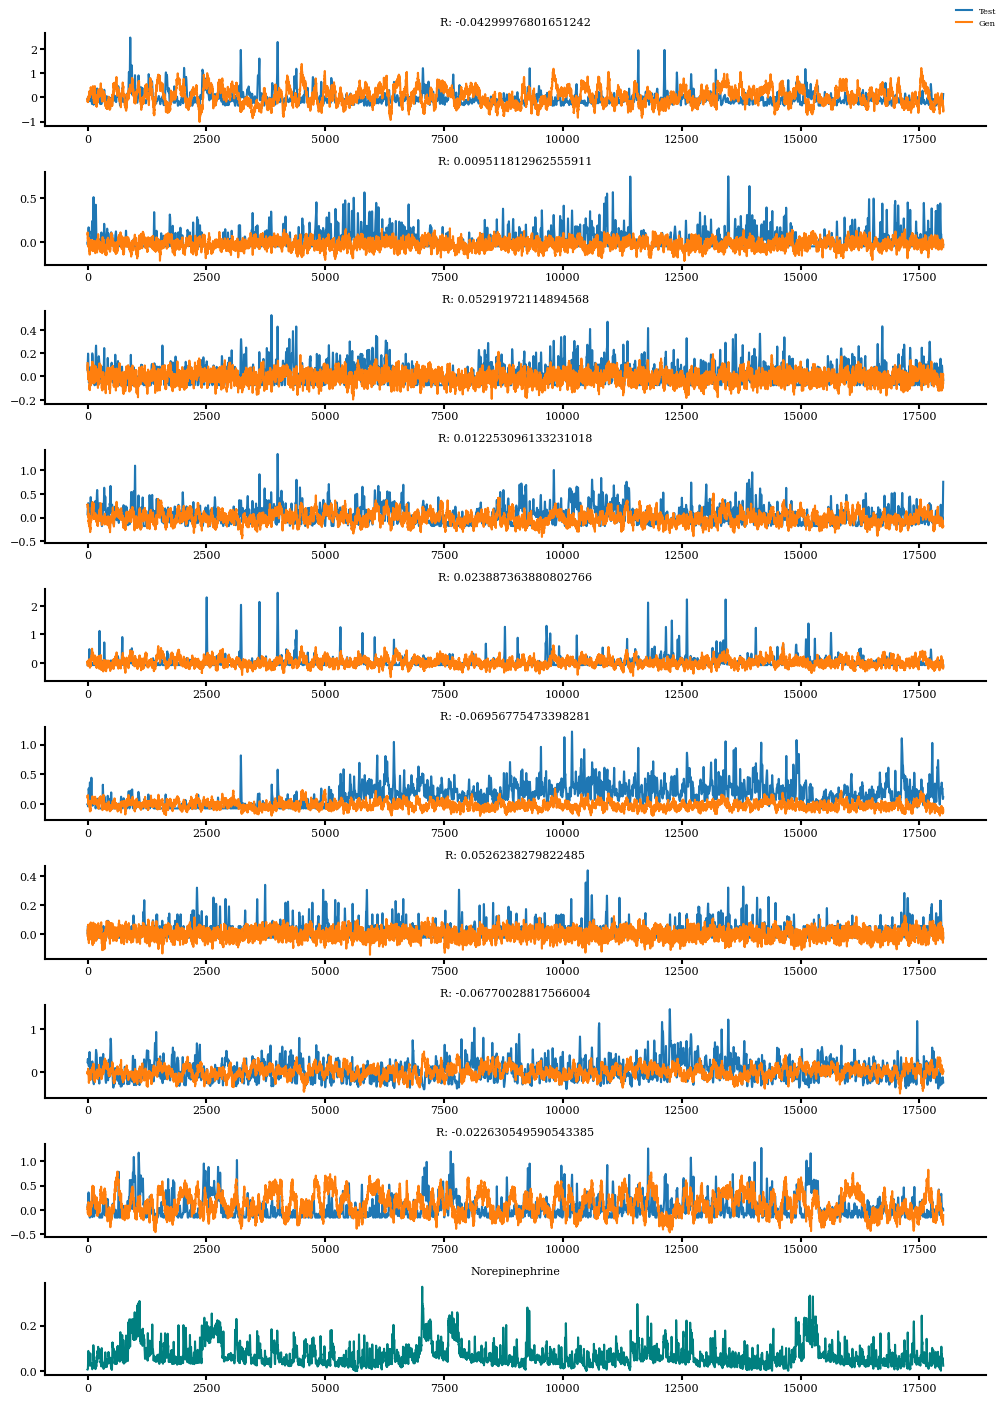

In [141]:
neurons = [132, 50, 15, 117, 78, 144, 80, 17, 90]
plot_traces(neurons, trajs['None_stim'], spike_counts_val, neuromod_val, 'None')

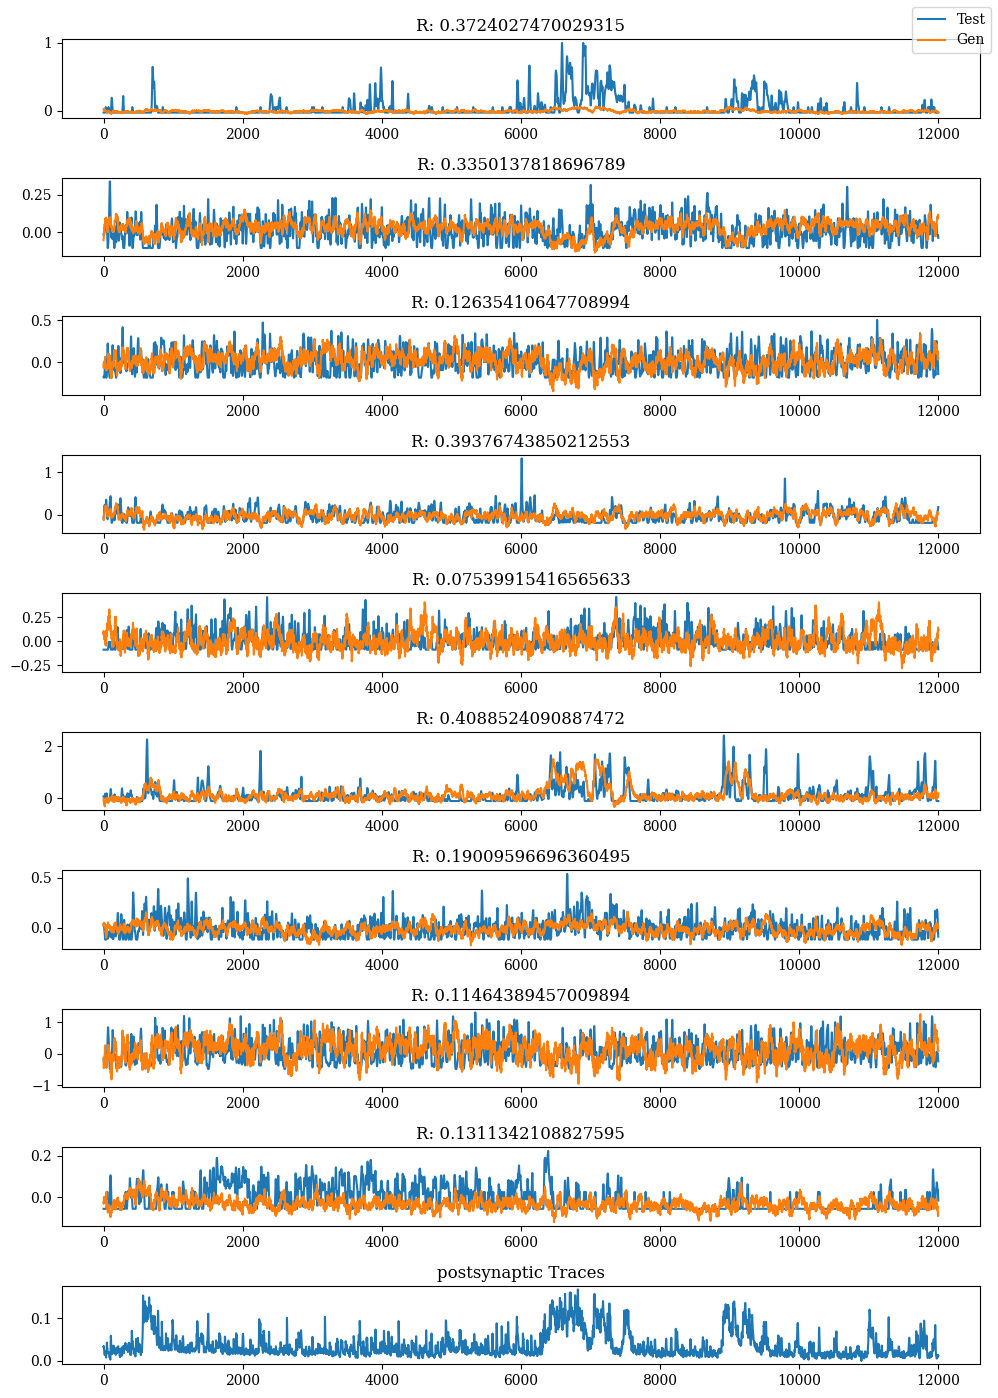

In [27]:
# neurons = [172, 50, 15, 167, 30, 110]
plot_traces(neurons, trajs['postsynaptic_stim'], spike_counts_val, neuromod_val, 'postsynaptic')

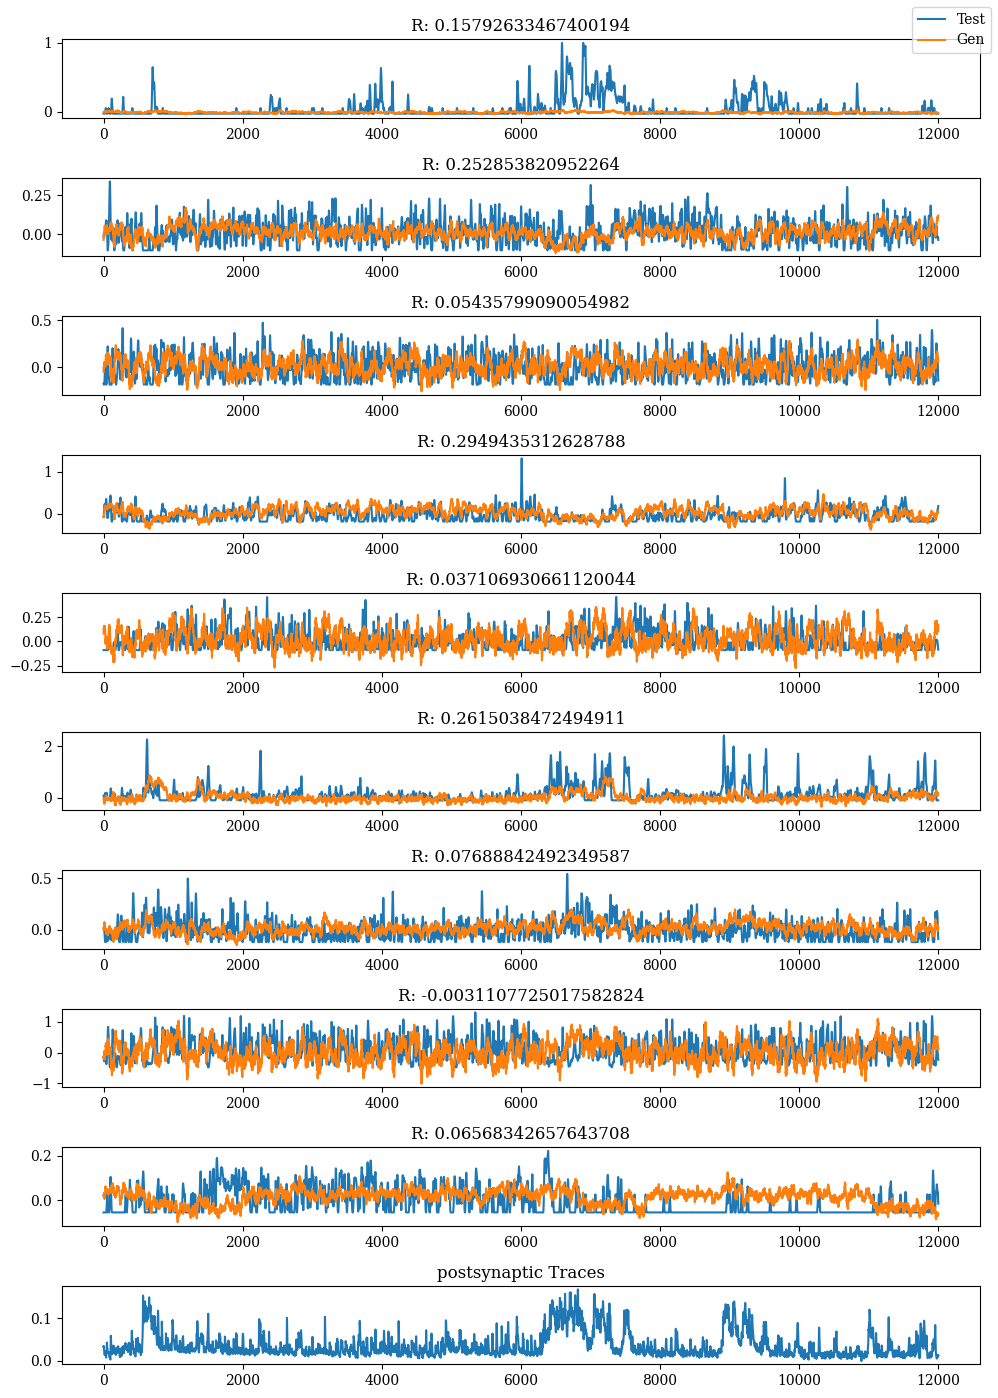

In [28]:
plot_traces(neurons, trajs['presynaptic'], spike_counts_val, neuromod_val, 'postsynaptic')

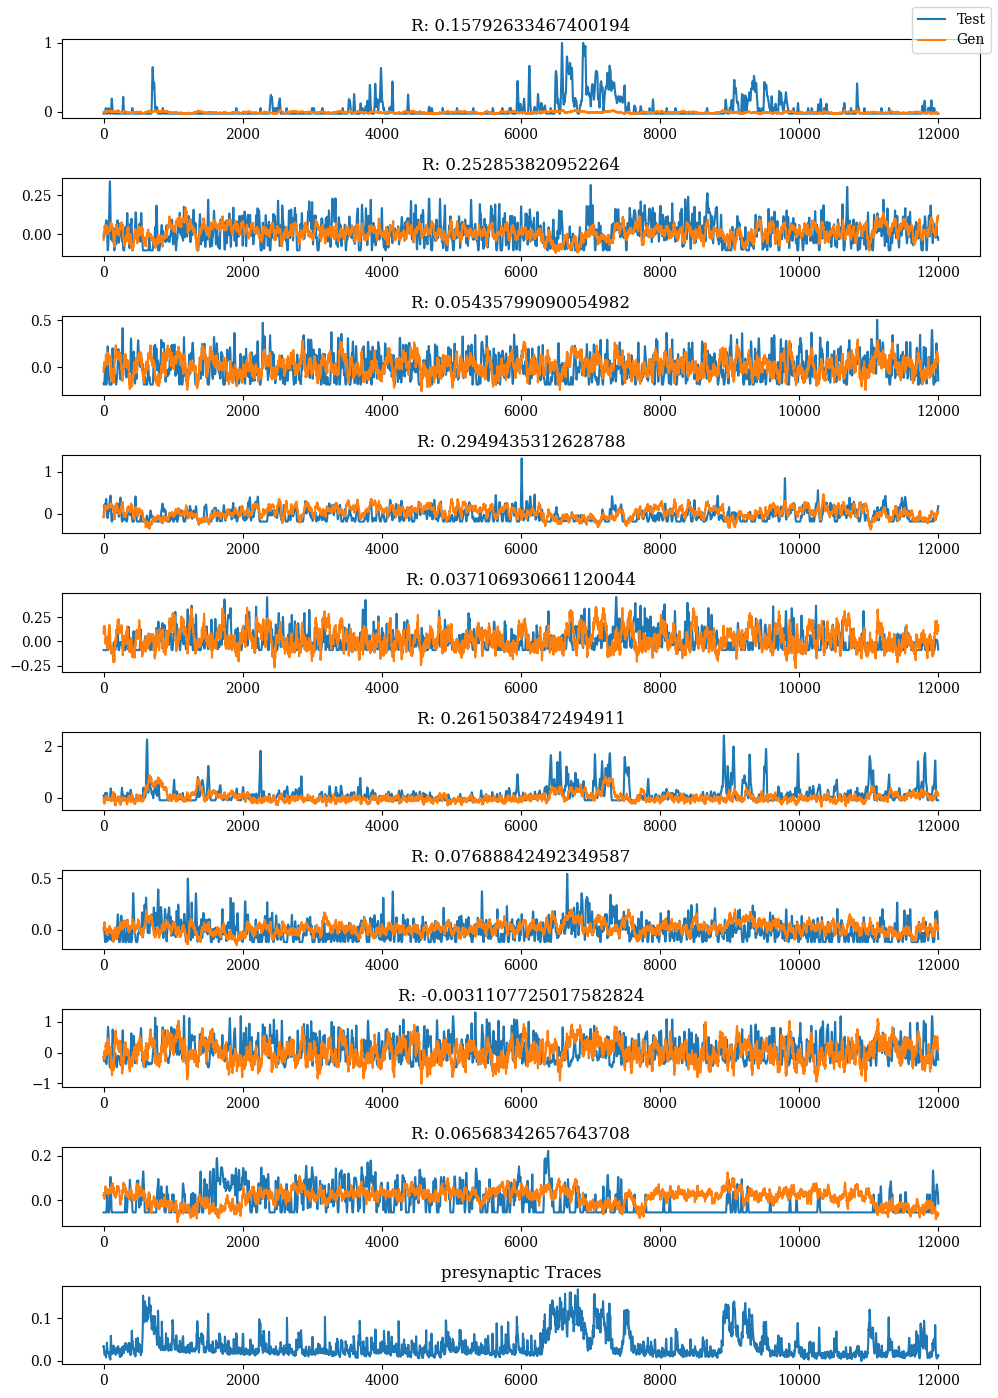

In [29]:
plot_traces(neurons, trajs['presynaptic'], spike_counts_val, neuromod_val, 'presynaptic')

/tmp/ipykernel_498200/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


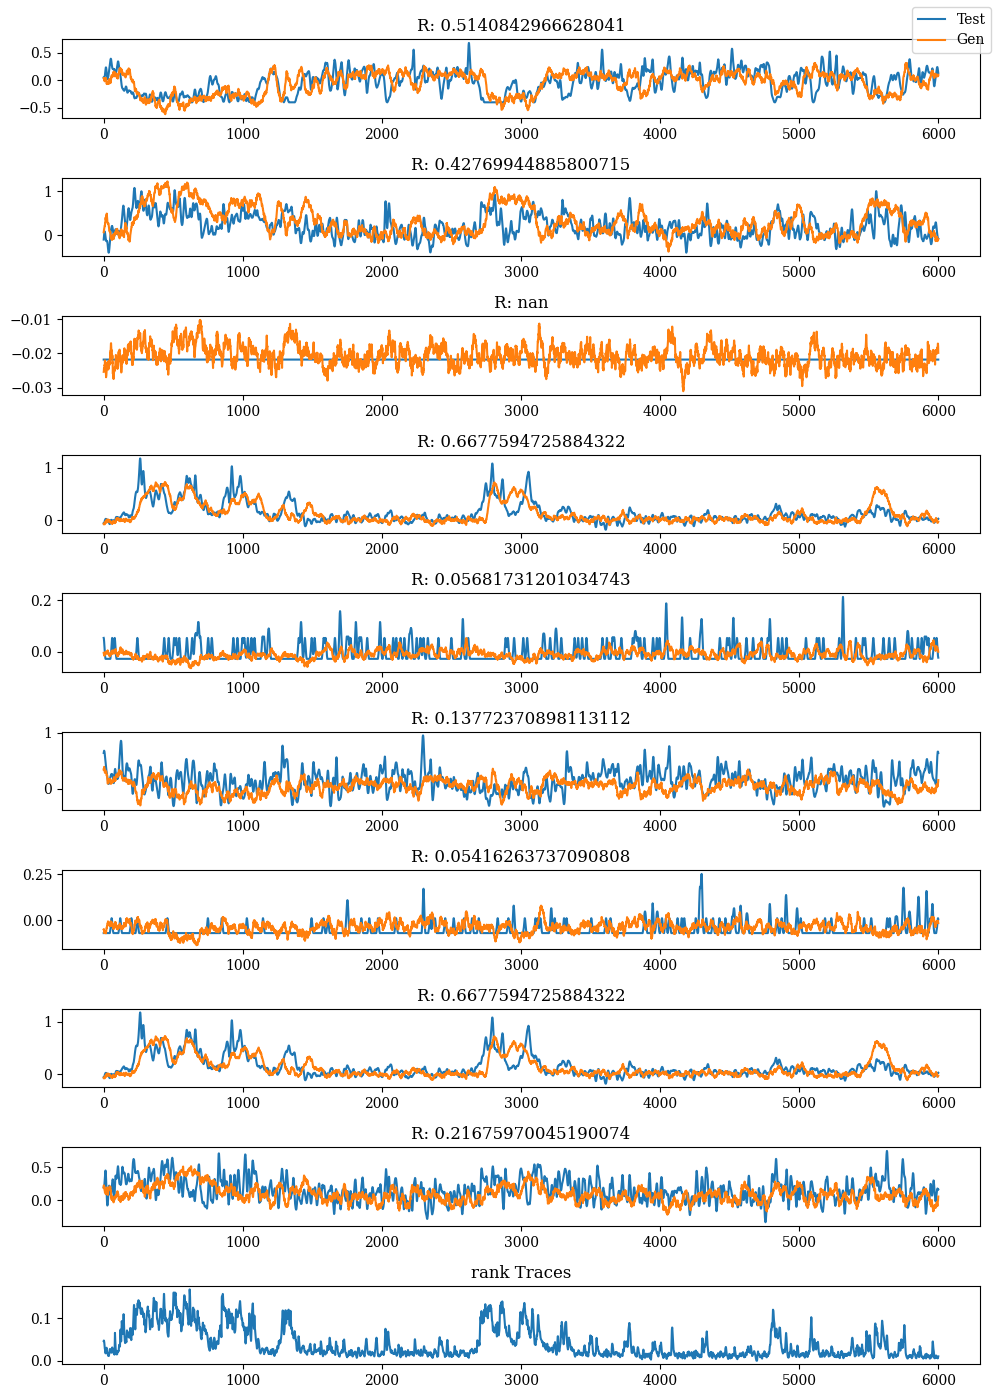

In [37]:
plot_traces(neurons, trajs['rank'], spike_counts_val, neuromod_val, 'rank')

### Visualize and compare pairwise correlations

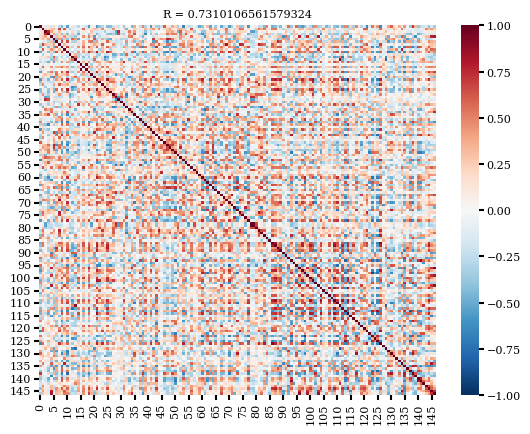

In [24]:
import seaborn as sns

fig, ax = plt.subplots(1, len(models) + 1)

corr_none = calculate_correlation(trajs['None_stim'].detach().T.numpy())
corr_test = calculate_correlation(spike_counts_val.T)
sns.heatmap(corr_none, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
plt.title(f'R = {r[0]}')
plt.savefig('autocorr_none.png')

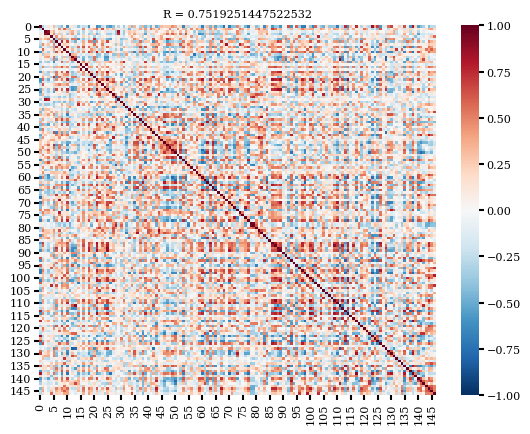

In [29]:
# compute and plot cross-correlation of all neurons in additive model
corr_add = calculate_correlation(trajs['additive'].detach().T.numpy())
corr_test = calculate_correlation(spike_counts_val.T)
corr_add = np.nan_to_num(corr_add)
corr_test = np.nan_to_num(corr_test)
sns.heatmap(corr_add, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
r = pearsonr(corr_add.flatten(), corr_test.flatten())
plt.title(f'R = {r[0]}')
plt.savefig('autocorr_additive.png')

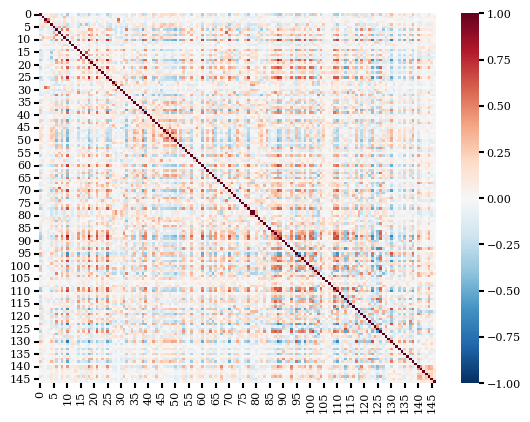

In [26]:
sns.heatmap(corr_test, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
plt.savefig('autocorr_test.png')

In [23]:
corr_none = np.nan_to_num(corr_none)
corr_test = np.nan_to_num(corr_test)

r = pearsonr(corr_none.flatten(), corr_test.flatten())
mse_none = ((corr_none.flatten() - corr_test.flatten()) ** 2).sum() / corr_none.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.7310106561579324, pvalue=0.0) 0.0529449144080228


In [57]:
r = pearsonr(corr_add.flatten(), corr_test.flatten())
mse_add_1= ((corr_add.flatten() - corr_test.flatten()) ** 2).sum() / corr_add.flatten().shape[0] 
print(r, mse_add_1)

PearsonRResult(statistic=0.7164550592891595, pvalue=0.0) 0.060648455218528505


In [31]:
corr_post = np.nan_to_num(corr_post)
corr_test = np.nan_to_num(corr_test)

r = pearsonr(corr_post.flatten(), corr_test.flatten())
mse_post = ((corr_post.flatten() - corr_test.flatten()) ** 2).sum() / corr_post.flatten().shape[0] 
print(r, mse_post)

PearsonRResult(statistic=0.7064682648762824, pvalue=0.0) 0.048060185474684214


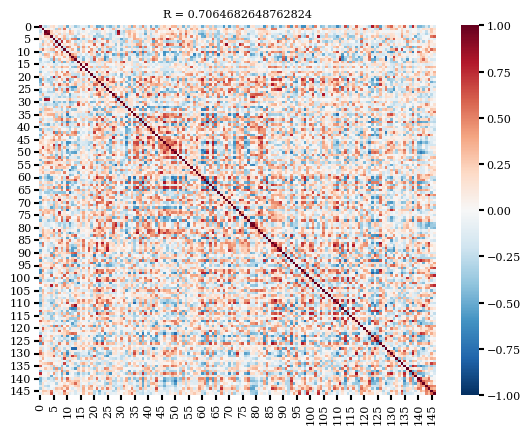

In [32]:
corr_post = calculate_correlation(trajs['postsynaptic'].detach().T.numpy())
sns.heatmap(corr_post, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)
plt.title(f'R = {r[0]}')
plt.savefig('autocorr_postsynaptic.png')

<Axes: >

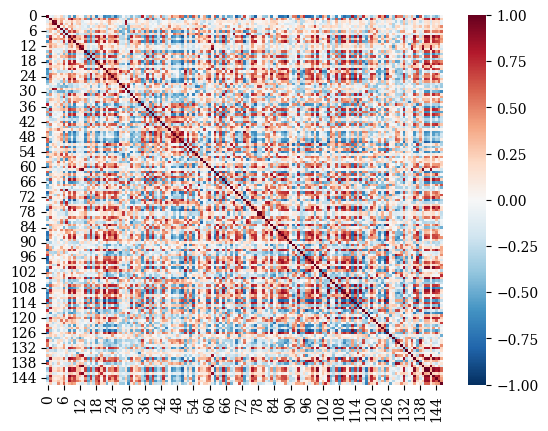

In [44]:
corr_pre = calculate_correlation(trajs['presynaptic'].detach().T.numpy())
sns.heatmap(corr_pre, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [45]:
r = pearsonr(corr_pre.flatten(), corr_test.flatten())
mse_none = ((corr_pre.flatten() - corr_test.flatten()) ** 2).sum() / corr_pre.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.763441973016564, pvalue=0.0) 0.07538307685282473


<Axes: >

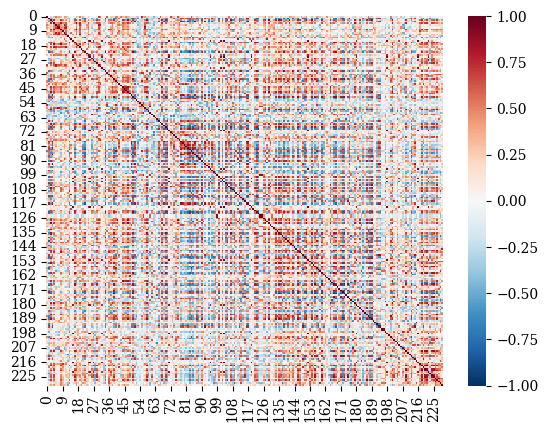

In [59]:
corr_rank = calculate_correlation(trajs['rank'].detach().T.numpy())
sns.heatmap(corr_rank, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [10]:
from evaluation.kl_Gauss import calc_kl_from_data
def compute_KL_divergence(pred_trajectories, x):
    """
    Computes the KL divergence over simulated and actual trajectories 
    
    Args: 
        pred_trajectories (torch.Tensor); n_trials x dim_x x time_steps: predicted trajectories 
        x (torch.Tensor): n_trials x dim_x x time_steps: actual neural activity 

    Returns: 
        kl_div: Estimated kernel divergence  
    """
    # reshape pred_trajectories and x 
    n_trials, trial_dur = pred_trajectories.shape[0], pred_trajectories.shape[2]
    pred_trajectories_ = pred_trajectories.permute((0, 2, 1)).reshape(n_trials*trial_dur, -1)
    x_ = x.permute((0, 2, 1)).reshape(n_trials*trial_dur, -1)
    kl_div = calc_kl_from_data(pred_trajectories_, x_)
    return kl_div.item()

In [11]:
from scipy.optimize import linear_sum_assignment
    
def calc_wasserstein_mc(mu_inf, mu_gen, scale, n_samples=200):
    """
    Estimate the 2-Wasserstein distance between two GMMs (mu_inf, mu_gen)
    via Monte Carlo sampling + the Hungarian algorithm for Optimal Transport.

    mu_inf, mu_gen: (T, dim_x) => each row is a GMM component mean
    scale: float or tensor => std for diagonal covariance
    n_samples: how many points to sample from each distribution
    """
    # 1) Draw samples from each GMM
    z_inf = mu_inf[:n_samples, :]
    z_gen = mu_gen[:n_samples, :]
    
    # 3) Compute the cost matrix: here we use squared Euclidean distance
    #    for the 2-Wasserstein (W2). cost[i, j] = ||z_inf[i] - z_gen[j]||^2
    diff = z_inf[:, None, :] - z_gen[None, :, :]
    cost_matrix = np.sum(diff**2, axis=2)  # shape (n_samples, n_samples)
    
    # 4) Solve the OT problem for uniform distributions (each sample is weight = 1/n_samples)
    #    linear_sum_assignment finds a minimum-cost one-to-one matching.
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # 5) The sum of the matched distances is the total transport cost.
    #    For W2, we want the square root of the average squared distance:
    #    W2^2 = (1/n) * sum(cost_matrix[row_ind, col_ind])
    
    #    => W2 = sqrt(W2^2)
    w2_squared = cost_matrix[row_ind, col_ind].mean()
    w2_distance = np.sqrt(w2_squared)
    
    return w2_distance

def compute_stats_new(models, block, num_trajs=20, num_samples=3000):
    if block == 'validation':
        t_start, t_end = t_start_post_trial - 300, t_start_post_trial 
        return compute_stats(t_start, t_end, models, block, num_trajs, num_samples)
    elif block == 'training':
        t_start, t_end = t_start_post_trial, t_start_post_trial + 300
        return compute_stats(t_start, t_end, models, block, num_trajs, num_samples)
    else:
        # concatenate all airpuff test trajectories 
        if block == 'white_noise':
            block_range = (5, 9)
        elif block == 'airpuff':
            block_range = (12, 15) 
        elif block == 'reward':
            block_range = (len(seq_periods) - 3, len(seq_periods))
            
        model_kl_divs = {}
        model_pshs = {}
        model_mres = {}
        model_was_dists = {}
        
        for j, model in enumerate(models.keys()):
            pairwise_corrs, kl_divs, pshs, mres, cross_corrs, was_dists = [], [], [], [], [], []
            for k in range(num_trajs):
                trajs = []
                spike_counts_val = []    
                print(model)
                for i in range(block_range[0], block_range[1]):
                    t_start, t_end = seq_periods[i]
                    spike_counts_trial = x_train[:, t_start:t_end]
                    spike_counts_val.append(spike_counts_trial)
                    neuromod_val = s_train[t_start:t_end]
                    stim = torch.from_numpy(stim_arr_train[:, t_start:t_end]).to(torch.float32)
                    if 'stim' not in model: stim = None 
                    traj_trial = get_trajectory(t_start, t_end, models[model], model, stim=stim, use_index=True)
                    trajs.append(traj_trial.detach().numpy())
                # compute stats on concatenated trajectories 
                trajs = torch.from_numpy(np.hstack(trajs)).to(torch.float32)
                spike_counts_val = np.hstack(spike_counts_val)
    
                kl_div = compute_KL_divergence(trajs.unsqueeze(0), torch.from_numpy(spike_counts_val).to(torch.float32).unsqueeze(0))
                was_dist = calc_wasserstein_mc(torch.from_numpy(spike_counts_val.T), trajs.T.detach(), 1.0, n_samples=num_samples)
                psh = power_spectrum_helling(trajs.unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000)
                mr = mean_rate(trajs.detach().numpy(), spike_counts_val)
                print(f'Sample {k}, KL Div: {kl_div}, Wasserstein: {was_dist}, PSH: {psh}, mean-rate: {mr}')

                kl_divs.append(kl_div)
                was_dists.append(was_dist)
                pshs.append(psh)
                mres.append(mr)
            print(model)
            print(f'KL Div: {np.array(kl_divs).mean()} std: {np.array(kl_divs).std()}')
            print(f'Wasserstein dist: {np.array(was_dists).mean()} std: {np.array(was_dists).std()}')
            print(f'Mean rate error: {np.array(mres).mean()} std: {np.array(mres).std()}')
            print(f'PSH: {np.array(pshs).mean()} std: {np.array(pshs).std()}')
            print(f'Autocorr: {np.array(pairwise_corrs).mean()} std: {np.array(pairwise_corrs).std()}')
            model_kl_divs[model] = kl_divs
            model_pshs[model] = pshs
            model_was_dists[model] = was_dists
            model_mres[model] = mres
        return model_kl_divs, model_pshs, model_was_dists, model_mres 
            
def compute_stats(t_start, t_end, models, block, num_trajs=20, num_samples=3000):
    spike_counts_val, neuromod_val, = get_block(spike_counts, neuromod_activity, t_start, t_end)
    
    if block == 'validation' or block == 'training': 
        stim = torch.zeros((9, spike_counts_val.shape[1]))
    elif block == 'airpuff': 
        stim = torch.from_numpy(stim_arr_airpuff).to(torch.float32)
    elif block == 'white_noise':
        stim = torch.from_numpy(stim_arr_white_noise).to(torch.float32)
    elif block == 'airpuff_2':
        stim = torch.from_numpy(stim_arr_airpuff_2).to(torch.float32)
    else:
        stim = torch.from_numpy(stim_arr_white_noise_2).to(torch.float32)
    model_kl_divs, model_mres, model_was_dists, model_pshs = {}, {}, {}, {}
    for i, model in enumerate(models.keys()):
        neuromod = model
        pairwise_corrs, kl_divs, pshs, mres, cross_corrs, was_dists = [], [], [], [], [], []
        print(neuromod)
        for num_traj in range(num_trajs):
            corr_test = calculate_correlation(spike_counts_val.T) 
            if 'stim' not in neuromod:
                traj = get_trajectory(t_start, t_end, models[model], neuromod, None)
            else:
                traj = get_trajectory(t_start, t_end, models[model], neuromod, stim)
                
            corr_neuromod = calculate_correlation(traj.detach().T.numpy())
            corr_test = np.nan_to_num(corr_test)
            corr_neuromod = np.nan_to_num(corr_neuromod)
            
            kl_div = compute_KL_divergence(traj.unsqueeze(0), torch.from_numpy(spike_counts_val).to(torch.float32).unsqueeze(0))
            # kl_div = 0
            was_dist = calc_wasserstein_mc(spike_counts_val.T, traj.T.detach().numpy(), 1.0, n_samples=num_samples)
            # was_dist = 0
            # psh = power_spectrum_helling(traj.unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000) 
            psh = 0
            mr = mean_rate(traj.detach().numpy(), spike_counts_val)
            print(f'Sample {num_traj}, KL Div: {kl_div}, Wasserstein: {was_dist}, PSH: {psh}, mean-rate: {mr}')
            
            kl_divs.append(kl_div)
            was_dists.append(was_dist)
            pshs.append(psh)
            mres.append(mr)
            
        print(neuromod)
        print(f'KL Div: {np.array(kl_divs).mean()} std: {np.array(kl_divs).std()}')
        print(f'Wasserstein dist: {np.array(was_dists).mean()} std: {np.array(was_dists).std()}')
        print(f'Mean rate error: {np.array(mres).mean()} std: {np.array(mres).std()}')
        print(f'PSH: {np.array(pshs).mean()} std: {np.array(pshs).std()}')
        model_kl_divs[model] = [np.array(kl_divs).mean()]
        model_pshs[model] = [np.array(pshs).mean()] 
        model_was_dists[model] = [np.array(was_dists).mean()] 
        model_mres[model] = [np.array(mres).mean()] 
    return model_kl_divs, model_pshs, model_was_dists, model_mres

## Evaluate state-space metrics

In [12]:
def plot_bar_scatter_sem(ax, data_dict, title, y_label='KL Divergence', plot_delta=False):
    """
    Plots a bar chart (mean ± SEM) for each key in data_dict,
    overlaid with scatter points for the individual data.
    
    Additionally, draws arrows from each scatter point in bar j
    to the *corresponding* scatter point in bar j+1 (for i-th data index).
    
    Requirements:
      - All lists in data_dict have the same length.
      - The dictionary has at least 2 keys (so there's something to connect).
    """
    keys = list(data_dict.keys())  # e.g. ["None", "Postsynaptic", ...]
    n_keys = len(keys)

    # if we want to see the delta, subtract the values of the other keys from None_stim 
    if plot_delta:
        for k in keys:
            if k != 'None_stim':
                data_dict[k] = np.array(data_dict[k]) - np.array(data_dict['None_stim'])
        del data_dict['None_stim']
        keys.remove('None_stim')
        n_keys -= 1
    # 1) Compute mean & SEM for each condition
    #    (replace with std if you want standard deviation)
    means = []
    sems  = []
    for k in keys:
        vals = data_dict[k]
        m    = np.mean(vals)
        std  = np.std(vals, ddof=1)
        n    = len(vals)
        sem  = std / np.sqrt(n)   # standard error of the mean
        means.append(m)
        sems.append(sem)
    
    x_pos = np.arange(n_keys)  # x-locations of each bar
    
    # 2) Plot the bars with error bars (SEM)
    ax.bar(x_pos, means, yerr=sems, capsize=5, alpha=0.7, color='lightcoral')
    ax.scatter(x_pos, means)
    # 3) Plot scatter points & keep track of their (x,y) positions
    #    We store them so we can draw arrows between corresponding points.
    scatter_positions = [[] for _ in range(n_keys)]
    # scatter_positions[j] will hold (x_i, y_i) for each data i in the j-th bar
    
    for j, k in enumerate(keys):
        values = data_dict[k]
        n_vals = len(values)
        # random jitter in x so points don't overlap
        x_jitter = np.random.uniform(-0.05, 0.05, size=n_vals)
        for i, val in enumerate(values):
            x_i = x_pos[j] + x_jitter[i]
            y_i = val
            ax.scatter(x_i, y_i, color='black', alpha=0.6, s=20)
            scatter_positions[j].append((x_i, y_i))
    
    # 4) Draw arrows between consecutive bars for each data index
    #    i.e. from scatter_positions[j][i] to scatter_positions[j+1][i]
    #    for j in [0..(n_keys-2)], i in [0..(n_data-1)]
    
    for j in range(n_keys - 1):
        # next bar is j+1
        # assume same number of data points in each list
        n_data = len(scatter_positions[j])
        for i in range(n_data):
            (xA, yA) = scatter_positions[j][i]
            (xB, yB) = scatter_positions[j+1][i]
            
            # draw an arrow from (xA, yA) to (xB, yB)
            ax.annotate(
                "",  # no text
                xy=(xB, yB),
                xytext=(xA, yA),
                arrowprops=dict(
                    arrowstyle="->",
                    alpha=0.3,
                    color="gray",
                    lw=1.0  # line width
                )
            )
    
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(keys, rotation=45, ha='right')
    ax.set_ylabel(y_label)


In [13]:
def box_plot(data_dicts, figname, dict_labels=None, title="", y_label="R", y_lims=[0, 3]): 
    box_spacing = 0.5
    positions = np.linspace(1, len(data_dicts) * box_spacing, len(data_dicts))
    colors = ["#000000", "#dc78fa", "#00DCDC", "#edc174", "#c9081b"]
    # -------------------------------------------------------------------
    # Create the figure and two subplots
    # -------------------------------------------------------------------
    fig, axes = plt.subplots()
    
    # Define boxplot style properties
    boxprops = dict(linestyle='-', linewidth=1, facecolor='white')
    medianprops = dict(linestyle='-', linewidth=2, color='black')
    whiskerprops = dict(linestyle='--', color='black')
    capprops = dict(linestyle='-', linewidth=1, color='black')

    #convert data dictionary to list of lists 
    stats_list = []
    for k in data_dicts.keys():
        stats_list.append(data_dicts[k])
        
    bp1 = axes.boxplot(
        stats_list,
        patch_artist=True,
        labels=dict_labels,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        showfliers=True
    )
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
    # Create legend handles manually
    legend_handles = [Patch(facecolor=color, label=label) for color, label in zip(colors, dict_labels)]
    # Add a vertical legend at the top left corner of the figure.
    fig.legend(handles=legend_handles, loc='upper left', ncol=1, bbox_to_anchor=(0.1, 1.0))
    
    axes.set_ylabel(y_label)
    axes.set_ylim(y_lims)
    axes.set_title(title)
    axes.spines['bottom'].set_visible(False)            # Remove bottom spine (x-axis line)
    axes.tick_params(axis='x', which='both', bottom=False, labelbottom=False)  # Remove x-axis ticks and labels
    axes.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    results_path = '../../results/figures/'
    figpath = os.path.join(results_path, figname)
    fig.savefig(figpath)
    


In [14]:
def plot_trajectory_colormap(trajs, mechanism):
    # compute the trial averaged response of the generated population 
    trial_avg_resp_gen = torch.stack(trajs[mechanism][30:40]).mean(axis=0)
    trial_avg_resp_test = torch.stack(trajs['test']).mean(axis=0)
    t_start, t_end = 0, trial_avg_resp_gen.shape[1]
    n_units = trial_avg_resp_gen.shape[0]
    fig, axes = plt.subplots(
        1, 2, 
        figsize=(6, 3), 
        sharex=True  # let the two plots share the same x-axis
    )
    vmin, vmax = np.percentile(trial_avg_resp_gen.detach().numpy(), [2, 80])
    # --- Top (blue) matrix ---
    im_top = axes[0].imshow(
        trial_avg_resp_gen.detach(),
        origin='lower',         # put the first row at the bottom
        aspect='auto',          # fill the subplot area
        cmap='Blues',           # all-blue colormap
        extent=[t_start, t_end, 0, n_units],
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_ylabel('Units')
    axes[0].set_yticks([0, n_units/2, n_units])
    axes[0].set_yticklabels([0, int(n_units/2), n_units])
    axes[0].set_title('Gen (Postsynaptic)')
    
    axes[0].set_xlabel('Time', labelpad=5)
    # vmin = np.percentile(trial_avg_resp_test.detach().numpy(), 1)   # Lower 1% value
    # vmax = np.percentile(trial_avg_resp_test.detach().numpy(), 99) 
    vmin, vmax = np.percentile(trial_avg_resp_test.detach().numpy(), [2, 80])
    # --- Bottom (red) matrix ---
    im_bottom = axes[1].imshow(
        trial_avg_resp_test.detach(),
        origin='lower',
        aspect='auto',
        cmap='Blues',            # all-red colormap
        extent=[t_start, t_end, 0, n_units],
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_xticklabels([])
    axes[0].set_xticks([])
    axes[1].set_yticks([0, n_units/2, n_units])
    axes[1].set_yticklabels([0, int(n_units/2), n_units])
    axes[1].set_title('Test')
    
    # Set x-ticks to match the figure style: 100, 150, 200
    axes[1].set_yticks([])
    # axes[1].set_xticks([100, 150, 200])
    axes[1].set_ylabel('')
    plt.tight_layout()
    plt.show()
    fig.savefig('../../results/figures/nk341_population_colormap_postsynaptic.png')

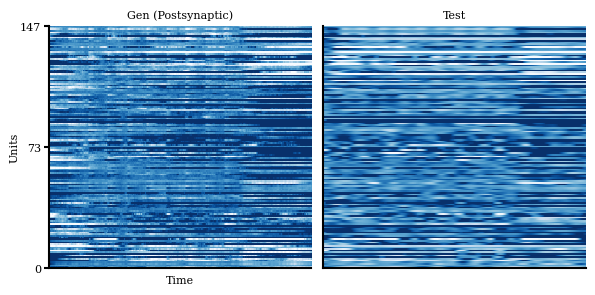

In [170]:
plot_trajectory_colormap(trajs_airpuff, 'postsynaptic_stim')

In [32]:
def plot_grouped_bars(data_dicts, figname, x_labels, dict_labels=None, title="Grouped Bar Plot", y_label="R", c=None):
    """
    Creates a grouped bar plot from 3 dictionaries that share the same keys.
    
    For each key, we plot 3 bars side by side (one for each dictionary).
    The bar height is the mean of the list of values; error bars show SEM.
    """
    # data_dicts = [dict1, dict2, dict3]
    # colors = ["#2D3748", "#E53E3E", "#ECC94B", "#008080"]
    if c is not None: colors = c 
    else: colors = ["#000000", "#dc78fa", "#a913d6",  "#00DCDC", "#008080", "#edc174", "#c98510",  "#ed5f6d", "#c9081b"]
    scatter_colors = ["#a913d6", "#008080", "#c98510"]
    errorbar_colors = ['#dc78fa', "#00DCDC", "#edc174"]
    if dict_labels is not None:
        colors = colors[len(colors) - len(dict_labels):] 
    elif len(data_dicts) == 4:
        dict_labels = ["Baseline", "White noise", "Airpuff", "Reward"]  # or customize these labels
    else:
        dict_labels = ["White noise", "Airpuff", "Reward"]  # or customize these labels
        colors = ["#E53E3E", "#ECC94B", "#008080"]
    # 1) We'll assume dict1, dict2, dict3 all have the same keys.
    #    We'll use the order from dict1.
    keys = list(data_dicts[0].keys())
    n_keys = len(keys)
    n_dicts = len(data_dicts)  # = 3
    
    # X positions for the groups of bars
    x = np.arange(n_keys)
    width = 0.1  # width of each bar

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 2) For each dictionary, compute mean & SEM for each key
    for i, d in enumerate(data_dicts):
        means = []
        sems  = []
        for k in keys:
            values = d[k]
            m      = np.mean(values)
            std    = np.std(values, ddof=1)
            n      = len(values)
            sem    = std / np.sqrt(n)  # standard error
            means.append(m)
            sems.append(sem)
        
        # 3) Plot the bars for this dictionary
        # Shift x positions by i*(width)
        bar_x = x + i * width
        
        ax.bar(
            bar_x, means, 
            yerr=sems, 
            width=width, 
            alpha=0.7, 
            label=dict_labels[i], 
            capsize=5,
            color="#dc78fa"
        )
        # ax.scatter(np.arange(0, len(means)), means, color=scatter_colors[i], s=30)
        # if dict_labels is not None: 
        #     ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i], label=dict_labels[i])
        # else:
        #     ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i])
        # ax.plot(means, c="#000000")
    
    # 4) Cosmetic details
    # Center x-ticks among the group of bars:
    ax.set_xticks(x + width*(n_dicts-1)/2)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    results_path = '../../results/figures/'
    figpath = os.path.join(results_path, figname)
    fig.savefig(figpath)
    plt.show()
    return fig, ax 

def plot_grouped_bars_line(data_dicts, figname, x_labels, dict_labels=None, title="Grouped Bar Plot", y_label="R"):
    """
    Creates a grouped bar plot from 3 dictionaries that share the same keys.
    
    For each key, we plot 3 bars side by side (one for each dictionary).
    The bar height is the mean of the list of values; error bars show SEM.
    """
    # data_dicts = [dict1, dict2, dict3]
    colors = ["#2D3748", "#E53E3E", "#ECC94B", "#008080"]
    scatter_colors = ["#a913d6", "#008080", "#c98510"]
    errorbar_colors = ['#dc78fa', "#00DCDC", "#edc174"]
    if dict_labels is not None:
        colors = colors[len(colors) - len(dict_labels):] 
    elif len(data_dicts) == 4:
        dict_labels = ["Baseline", "White noise", "Airpuff", "Reward"]  # or customize these labels
    # 1) We'll assume dict1, dict2, dict3 all have the same keys.
    #    We'll use the order from dict1.
    keys = list(data_dicts[0].keys())
    n_keys = len(keys)
    n_dicts = len(data_dicts)  # = 3
    
    # X positions for the groups of bars
    x = np.arange(n_keys)
    width = 0.1  # width of each bar

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 2) For each dictionary, compute mean & SEM for each key
    for i, d in enumerate(data_dicts):
        means = []
        sems  = []
        for k in keys:
            values = d[k]
            m      = np.mean(values)
            std    = np.std(values, ddof=1)
            n      = len(values)
            sem    = std / np.sqrt(n)  # standard error
            means.append(m)
            sems.append(sem)
        
        # 3) Plot the bars for this dictionary
        # Shift x positions by i*(width)
        bar_x = x + i * width
        
        # ax.bar(
        #     bar_x, means, 
        #     yerr=sems, 
        #     width=width, 
        #     alpha=0.7, 
        #     label=dict_labels[i], 
        #     capsize=5,
        #     color="#dc78fa"
        # )
        ax.scatter(np.arange(0, len(means)), means, color=scatter_colors[i], s=30)
        if dict_labels is not None: 
            ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i], label=dict_labels[i])
        else:
            ax.errorbar(np.arange(0, len(means)), means, yerr=sems, color=errorbar_colors[i])
        # ax.plot(means, c="#000000")
    
    # 4) Cosmetic details
    # Center x-ticks among the group of bars:
    ax.set_xticks(x + width*(n_dicts-1)/2)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    results_path = '../../results/figures/'
    figpath = os.path.join(results_path, figname)
    fig.savefig(figpath)
    plt.show()
    return fig, ax 

def compute_offsets(n_keys, width, gap, extra_spacing):
    """
    Compute custom offsets for n_keys bars given a bar width and extra gap.
    
    Extra gap is added after the first bar and then after every second bar.
    That is, for each bar index j > 0, if the previous index (j-1) is even,
    an extra gap is inserted.
    """
    offsets = [0]
    for j in range(1, n_keys):
        extra = gap
        if extra_spacing:
            extra = gap if ((j - 1) % 2 == 0) else 0
        offsets.append(offsets[j-1] + width + extra)
    offsets = np.array(offsets)
    # Center the offsets so that the group is centered at zero.
    offsets = offsets - np.mean(offsets)
    return offsets

def plot_grouped_bars_by_dict(data_dicts, dict_labels=None,
                              title="Grouped Bar Plot", x_labels=None,
                              y_label="Value", keys=None, figname=None, c=None, extra_spacing=True):
    """
    data_dicts: a list of dictionaries [dict1, dict2, ...].
                Each dict must have the same set of keys.
    dict_labels: a list of labels for each dictionary (same length as data_dicts).
    title: plot title
    y_label: label for the y-axis

    This function creates a grouped bar plot where each dictionary
    is one "group" on the x-axis, and each key in the dictionaries
    is a sub-bar within that group.

    Example:
      - data_dicts = [dict1, dict2, dict3]
      - Each dict has keys: K1, K2, K3
      Then the x-axis has 3 groups (one per dict),
      and each group has 3 bars (one per key).
    """
    if c is not None: colors = c
    else: colors = ["#000000", "#dc78fa", "#a913d6",  "#00DCDC", "#008080", "#edc174", "#c98510",  "#ed5f6d", "#c9081b"]
    # If no labels are provided for the dictionaries, make generic ones
    if dict_labels is None:
        dict_labels = [f"Dict {i+1}" for i in range(len(data_dicts))]
    
    # All dictionaries must share the same keys
    keys = list(data_dicts[0].keys())
    n_dicts = len(data_dicts)
    n_keys = len(keys)

    # We'll place each dictionary at integer x positions
    x = np.arange(n_dicts)  # [0, 1, 2, ...]
    # We'll make sub-bars for each key within each dictionary
    # so we need a small offset
    width = 0.5 / n_keys  # total group width ~ 0.8

    fig, ax = plt.subplots(figsize=(5,5))

    # Compute custom offsets for the sub-bars within each group.
    offsets = compute_offsets(n_keys, width, gap=0.01, extra_spacing=extra_spacing)
    
    # Create x positions for each group (dictionary)
    group_x = np.arange(n_dicts)
    
    # Loop over each key (sub-category)
    for j, k in enumerate(keys):
        # For each dictionary, compute mean + SEM for this key
        means = []
        sems = []
        for d in data_dicts:
            vals = d[k]
            m = np.mean(vals)
            s = np.std(vals, ddof=1)      # sample std
            n = len(vals)
            sem = s / np.sqrt(n)          # standard error of the mean
            means.append(m)
            sems.append(sem)

        # For each key, compute the x positions for each group's bar:
        # x positions = group_x + offset for this key.
        bar_x = group_x + offsets[j]
    
        # Plot the bars for this key
        ax.bar(
            bar_x, means,
            yerr=sems,
            width=width,
            alpha=0.7,
            color=colors[j],
            label=dict_labels[j]  # legend label is the key
        )

    # Cosmetic details
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel(y_label)
    ax.set_title(title) # or just ax.legend()

    plt.tight_layout()
    plt.legend()
    results_path = '../../results/'
    figpath = os.path.join(results_path, figname)
    fig.savefig(figpath)
    plt.show()

def plot_scatter(r_vals, title, figname):
    models = ['postsynaptic', 'presynaptic', 'additive', 'rank']
    colors = ["#a913d6",  "#008080", "#c98510", "#c9081b"]
    markers = ['X', 'o', '*', '+']
    # first compute the average for the Non-modulated model 
    stim_only_avg = np.array(r_vals['None_stim']).mean()
    # compute the average for the additive only modulated model 
    additive_avg = np.array(r_vals['additive']).mean()
    postsynaptic_avg = np.array(r_vals['postsynaptic']).mean()
    presynaptic_avg = np.array(r_vals['presynaptic']).mean()
    rank_avg = np.array(r_vals['rank']).mean() 
    
    fig, ax = plt.subplots()
    for i, model in enumerate(models):
        ax.scatter(r_vals[model], r_vals[f'{model}_stim'], c=colors[i], marker=markers[i], s=15, label=models[i])
    ax.axhline(stim_only_avg, linestyle='--', c='black', label='Stimuli only')
    # ax.axvline(additive_avg, linestyle='--', c='#c98510', alpha=0.5)
    # ax.axvline(postsynaptic_avg, linestyle='--', c="#a913d6", alpha=0.5)
    # ax.axvline(presynaptic_avg, linestyle='--', c="#008080", alpha=0.5)
    # ax.axvline(rank_avg, linestyle='--', c='#c9081b', label='Rank', alpha=0.5)
    
    ax.set_xlabel('Neuromodulator only')
    ax.set_ylabel('Neuromodulator+Stimuli')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend()
    fig.suptitle(title)

    ax.plot([[0, 0], [1, 1]], c='grey', alpha=0.5, linestyle='--')
    # results_path = '../../results/'
    # plt.tight_layout()
    # figpath = os.path.join(results_path, figname)
    # fig.savefig(figpath)
    # plt.show()

In [16]:
def evaluate_state_space(state, num_trajs, sanity_check=False):
    kl_divs, pshs, was_dists, mres = None, None, None, None
    # model_types = ['None_stim', 'postsynaptic', 'postsynaptic_stim', 'presynaptic', 'presynaptic_stim', 'additive', 'additive_stim', 'rank', 'rank_stim'] 
    model_types = ['None_stim', 'postsynaptic', 'presynaptic', 'additive', 'rank']
    for i in range(0, 10):
        models = {}
        for model in model_types:
            if sanity_check and 'None' in model: continue 
            if 'stim' in model:
                model_name = model.split('_')[0]
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model_name}_rank_20_seed_{i}_stim')
            else:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model}_rank_20_seed_{i}')  
            if sanity_check:
                if 'None' in model: continue 
                vae.rnn.transition.A = torch.nn.Parameter(torch.zeros_like(vae.rnn.transition.A))
            models[model] = vae
        
        model_kl_divs, model_pshs, model_was_dists, model_mres = compute_stats_new(models, state, num_trajs=num_trajs)
        if kl_divs is not None: 
            kl_divs = {k: kl_divs[k] + model_kl_divs[k] for k in kl_divs}
            pshs = {k: pshs[k] + model_pshs[k] for k in pshs}
            was_dists = {k: was_dists[k] + model_was_dists[k] for k in was_dists}
            mres = {k: mres[k] + model_mres[k] for k in mres}
        else:
            kl_divs = model_kl_divs
            pshs = model_pshs
            was_dists = model_was_dists
            mres = model_mres
    return kl_divs, pshs, was_dists, mres

def evaluate_state_space_ranks(state, num_trajs, sanity_check=False):
    kl_divs, pshs, was_dists, mres = None, None, None, None
    # model_types = ['None_stim', 'postsynaptic', 'postsynaptic_stim', 'presynaptic', 'presynaptic_stim', 'additive', 'additive_stim', 'rank', 'rank_stim'] 
    model = 'None_stim'
    for i in range(9, -1, -1):
        sys.__stdout__.write(f"Seed {i}\n")
        sys.__stdout__.flush()
        models = {}
        for rank in [1, 2, 3, 4, 5, 6, 7, 8, 20]:
            if sanity_check and 'None' in model: continue 
            if 'stim' in model:
                model_name = model.split('_')[0]
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model_name}_rank_{rank}_seed_{i}_stim')
            else:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model}_rank_{rank}_seed_{i}')  
            if sanity_check:
                if 'None' in model: continue 
                vae.rnn.transition.A = torch.nn.Parameter(torch.zeros_like(vae.rnn.transition.A))
            models[f'{model}-{rank}'] = vae
        
        model_kl_divs, model_pshs, model_was_dists, model_mres = compute_stats_new(models, state, num_trajs=num_trajs)
        if kl_divs is not None: 
            kl_divs = {k: kl_divs[k] + model_kl_divs[k] for k in kl_divs}
            pshs = {k: pshs[k] + model_pshs[k] for k in pshs}
            was_dists = {k: was_dists[k] + model_was_dists[k] for k in was_dists}
            mres = {k: mres[k] + model_mres[k] for k in mres}
        else:
            kl_divs = model_kl_divs
            pshs = model_pshs
            was_dists = model_was_dists
            mres = model_mres
    return kl_divs, pshs, was_dists, mres

In [16]:
kl_divs_baseline, pshs_baseline, was_dists_baseline, mres_baseline = evaluate_state_space('validation', 10, sanity_check=False)
        

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: presynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', '

In [178]:
model_types = ['None_stim', 'postsynaptic', 'presynaptic', 'additive', 'rank']
with open('../../results/pickle/nk341_mPFC_rank_20_kl_divs.pkl', 'rb') as f:
    kl_divs_baseline_nk341 = pickle.load(f)
    kl_divs_baseline = {}
    for m in model_types: kl_divs_baseline[m] = kl_divs_baseline_nk341[0][m]

with open('../../results/pickle/nk341_mPFC_rank_20_was_dists.pkl', 'rb') as f:
    was_dists_baseline_nk341 = pickle.load(f)
    was_dists_baseline = {}
    for m in model_types: was_dists_baseline[m] = was_dists_baseline_nk341[0][m]

with open('../../results/pickle/nk341_mPFC_rank_20_mres.pkl', 'rb') as f:
    mres_baseline_nk341 = pickle.load(f)
    mres_baseline = {}
    for m in model_types: mres_baseline[m] = mres_baseline_nk341[0][m]

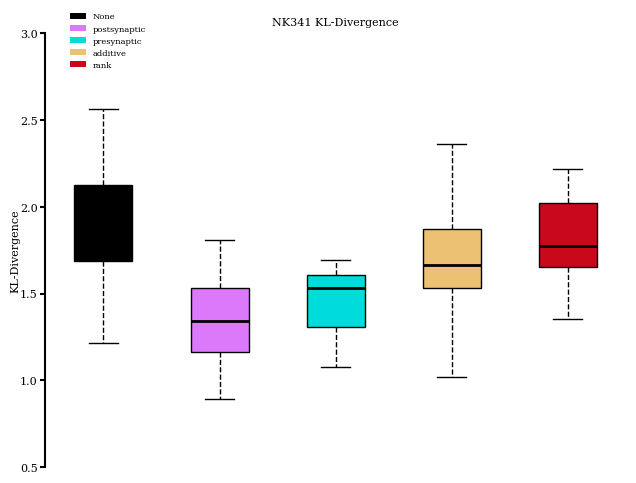

In [181]:
model_types = ['None', 'postsynaptic', 'presynaptic', 'additive', 'rank']
box_plot(kl_divs_baseline, 'nk341_mPFC_kl_divs_box.png', dict_labels=model_types, title="NK341 KL-Divergence", y_label="KL-Divergence", y_lims=[0.5, 3.0])

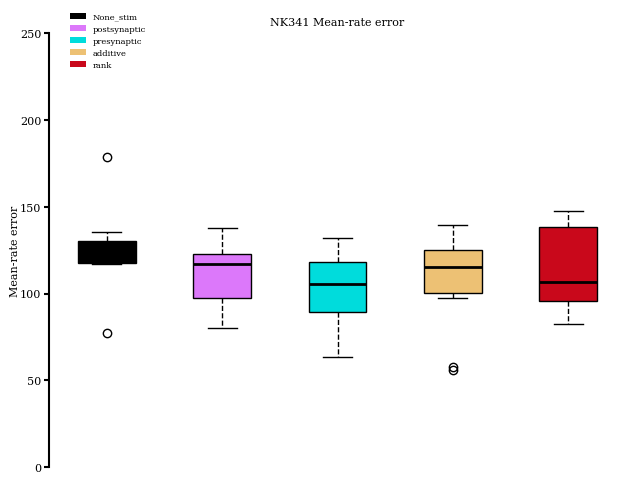

In [179]:
box_plot(mres_baseline, 'nk341_mPFC_mres_box.png', dict_labels=model_types, title="NK341 Mean-rate error", y_label="Mean-rate error", y_lims=[0, 250])

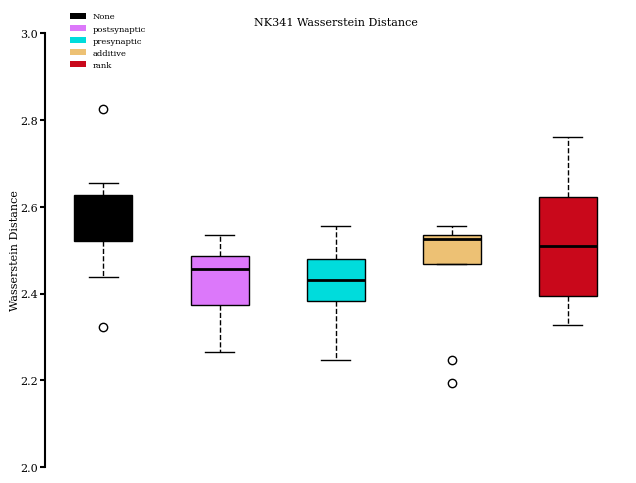

In [182]:
box_plot(was_dists_baseline, 'nk341_mPFC_wasserstein_box.png', dict_labels=model_types, title="NK341 Wasserstein Distance", y_label="Wasserstein Distance", y_lims=[2, 3])

In [15]:
kl_div_dict = [kl_divs_baseline]
plot_grouped_bars_line(kl_div_dict, 'nk339_none_kl_divs_rank_comp.png', title="NK339 None KL-Div values comparison across", x_labels=ranks, y_label="KL-Div")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

NameError: name 'kl_divs_baseline' is not defined

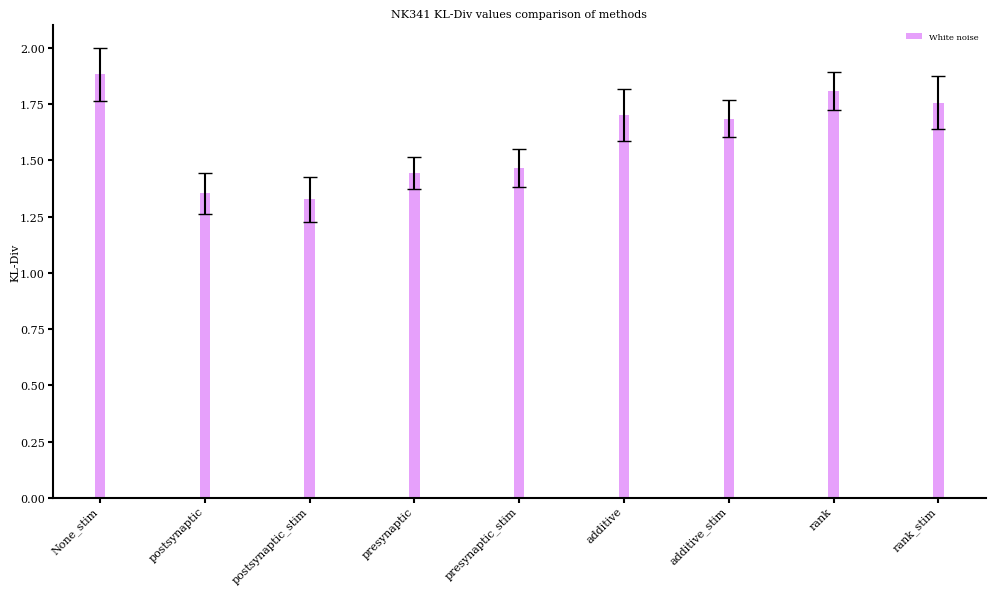

<Figure size 640x480 with 0 Axes>

In [108]:
kl_div_dict = [kl_divs_baseline]
plot_grouped_bars(kl_div_dict, 'nk341_kl_divs.png', title="NK341 KL-Div values comparison of methods", x_labels=model_types, y_label="KL-Div")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

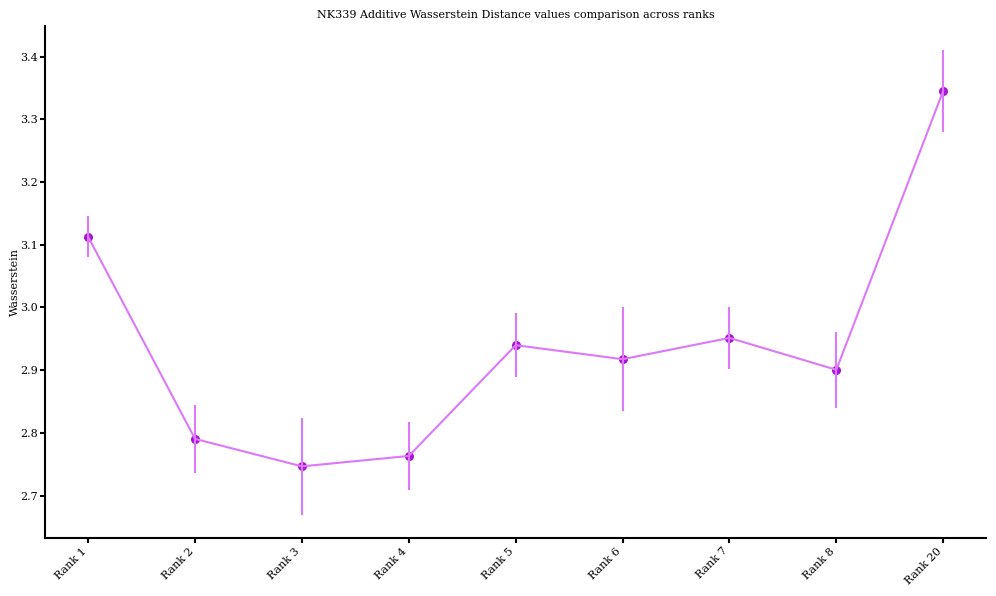

<Figure size 640x480 with 0 Axes>

In [19]:
was_dist_dict = [was_dists_baseline]
plot_grouped_bars_line(was_dist_dict, 'nk339_additive_was_dists_rank_comp.png', title="NK339 Additive Wasserstein Distance values comparison across ranks", x_labels=ranks, y_label="Wasserstein")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

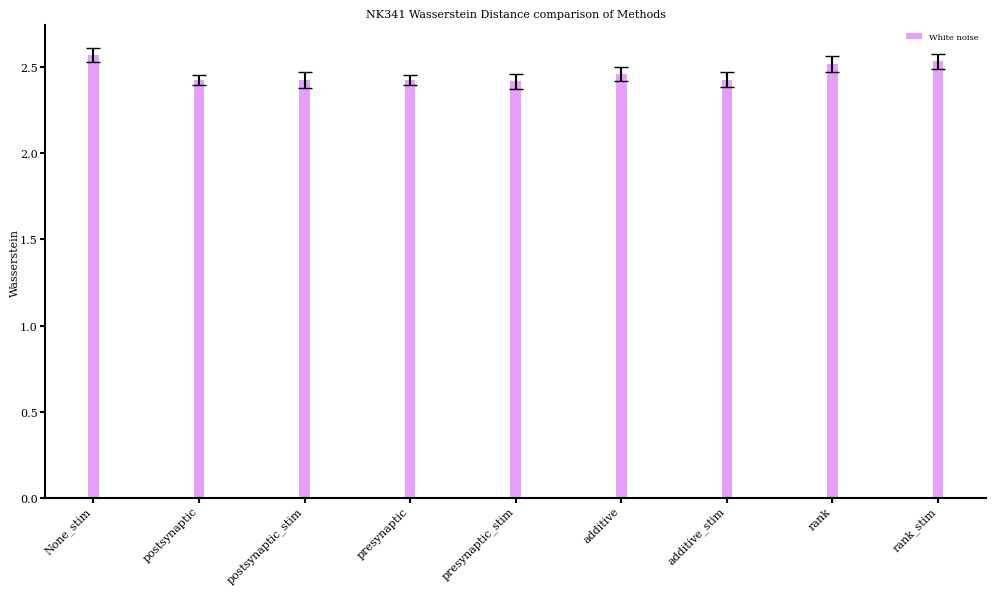

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [110]:
was_dist_dict = [was_dists_baseline]
plot_grouped_bars(was_dist_dict, 'nk341_was_dists.png', title="NK341 Wasserstein Distance comparison of Methods", x_labels=model_types, y_label="Wasserstein")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

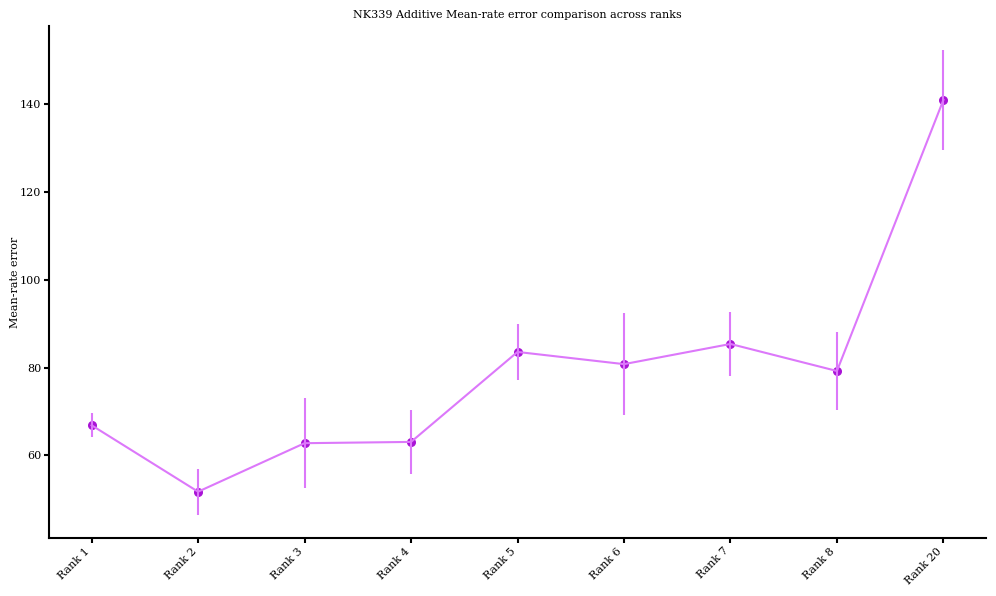

<Figure size 640x480 with 0 Axes>

In [20]:
mre_dict = [mres_baseline]
plot_grouped_bars_line(mre_dict, 'nk339_additive_mres_rank_comp.png', title="NK339 Additive Mean-rate error comparison across ranks", x_labels=ranks, y_label="Mean-rate error")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

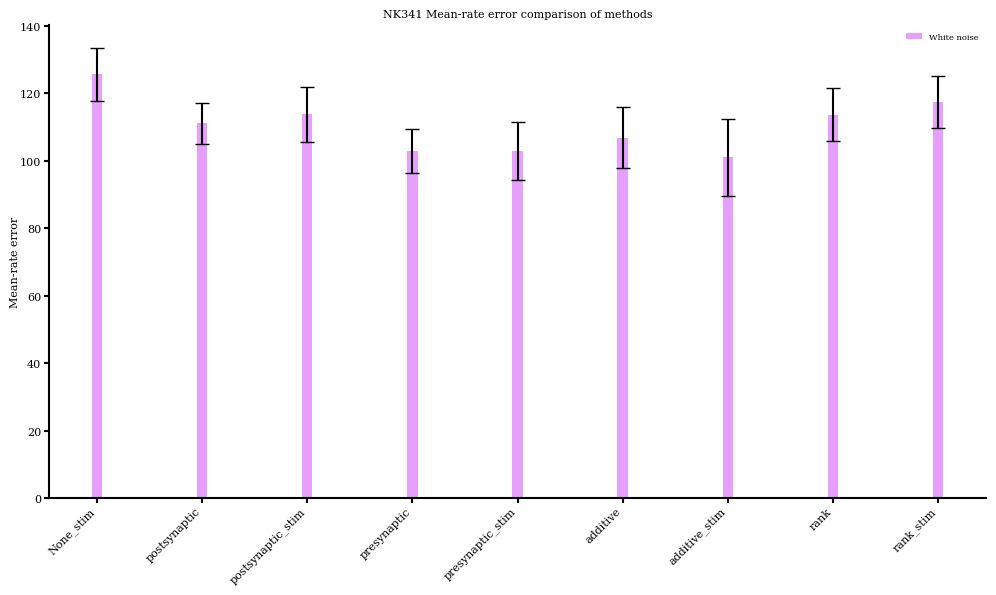

<Figure size 640x480 with 0 Axes>

In [111]:
mre_dict = [mres_baseline]
plot_grouped_bars(mre_dict, 'nk341_mres.png', title="NK341 Mean-rate error comparison of methods", x_labels=model_types, y_label="Mean-rate error")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

In [18]:
# save results array
import pickle 

results_dir = '../../results/pickle/' 
kl_div_dict = [kl_divs_baseline]
with open(os.path.join(results_dir, 'nk339_mPFC_rank_20_kl_divs.pkl'), "wb") as f:
    pickle.dump(kl_div_dict, f) 
was_dist_dict = [was_dists_baseline]
with open(os.path.join(results_dir, 'nk339_mPFC_rank_20_was_dists.pkl'), "wb") as f:
    pickle.dump(was_dist_dict, f) 
mre_dict = [mres_baseline]
with open(os.path.join(results_dir, 'nk339_mPFC_rank_20_mres.pkl'), "wb") as f:
    pickle.dump(mre_dict, f) 

In [21]:
# save results array
import pickle 

results_dir = '../../results/pickle/' 
kl_div_dict = [kl_divs_baseline]
with open(os.path.join(results_dir, 'nk339_mPFC_additive_ranks_kl_divs.pkl'), "wb") as f:
    pickle.dump(kl_div_dict, f) 
was_dist_dict = [was_dists_baseline]
with open(os.path.join(results_dir, 'nk339_mPFC_additive_ranks_was_dists.pkl'), "wb") as f:
    pickle.dump(was_dist_dict, f) 
mre_dict = [mres_baseline]
with open(os.path.join(results_dir, 'nk339_mPFC_additive_ranks_mres.pkl'), "wb") as f:
    pickle.dump(mre_dict, f) 

### Perform temporal comparisons during trial blocks

In [19]:
def temporal_eval(block, num_trajs, sanity_check=False):
    seeds = np.arange(0, 10)
    if block == 'baseline':
        block_range_test = [0]
        block_range_total = [0]
    elif block == 'white_noise':
        # block_range = range(1, 5)
        block_range_total = range(1, 9)
        block_range_test = range(5, 9)
        # block_range = range(6, 10)
    elif block == 'airpuff': 
        block_range_total = range(9, 15)
        block_range_test = range(12, 15)
        # block_range = range(13, 16)
    elif block == 'reward':
        block_range_total = range(16, 22)
        block_range_test = range(19, 22)
    elif block == 'odor': 
        block_range_total = range(22, 28)
        block_range_test = block_range_total 
        
    # models = ['None_stim', 'postsynaptic', 'postsynaptic_stim', 'presynaptic', 'presynaptic_stim', 'additive', 'additive_stim', 'rank', 'rank_stim'] 
    models = ['postsynaptic_stim', 'presynaptic_stim', 'additive_stim', 'rank_stim'] 
    trajs, r_vals, avg_trajs, test_avg_trajs = {}, {}, {}, []
    r_dist, r2_dist = {}, {}
    
    trajs['test'] = []
    for j in block_range_total:
        t_start, t_end = seq_periods[j]
        trajs['test'].append(torch.from_numpy(x_train[:, t_start:t_end]))

    test_trial_avg = torch.stack(trajs['test']).mean(axis=0)
    
    for model in models:
        for i in range(0,10):
            if sanity_check and 'None' in model: continue
            if 'stim' in model:
                model_name = model.split('_')[0]
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk341_mPFC_{model_name}_rank_20_seed_{i}_stim')
            else:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk341_mPFC_{model}_rank_20_seed_{i}')
            if sanity_check: 
                vae.rnn.transition.A = torch.nn.Parameter(torch.zeros_like(vae.rnn.transition.A))
                
            for j in block_range_test:
                t_start, t_end = seq_periods[j]
                spike_counts_val = x_train[:, t_start : t_end] 
                if model not in trajs.keys():
                    trajs[model] = []
                    r_vals[model] = [] 
                    avg_trajs[model] = []  
                    r2_dist[model] = []
                    r_dist[model] = []
                    
                if 'stim' in model:
                    stim = torch.from_numpy(stim_arr_train[:, t_start : t_end]).to(torch.float32)
                else: stim = None 
                
                # generate num_trajs trajectories 
                for _ in range(num_trajs):      
                    traj = get_trajectory(t_start, t_end, vae, model, stim, use_index=True)
                    trajs[model].append(traj)
                
                # average the trajectories 
                avg_traj = torch.stack(trajs[model][-num_trajs:]).mean(axis=0)
                test_avg_trajs.append(spike_counts_val.mean(axis=0))
                # compute the r
                
                # r = pearsonr(avg_traj.flatten().detach(), spike_counts_val.flatten())[0]
                # print(f'Model {model} Fit {i} block {j} r: {r}')
                # r2 = r2_score(avg_traj.flatten().detach(), spike_counts_val.flatten())
                # r_vals[model].append(r)
                avg_trajs[model].append(avg_traj)
            
            # get model trial average response 
            model_trial_avg = torch.stack(avg_trajs[model]).mean(axis=0)
            for n in range(model_trial_avg.shape[0]):
                r_dist[model].append(pearsonr(model_trial_avg[n].flatten().detach(), spike_counts_val[n])[0])  
                r2_dist[model].append(r2_score(model_trial_avg[n].flatten().detach(), spike_counts_val[n]))
            r = pearsonr(model_trial_avg.flatten().detach(), test_trial_avg.flatten())[0]
            r_vals[model].append(r)
            print(f'Model {model} r: {r}')
    return trajs, r_vals, avg_trajs, test_avg_trajs, r2_dist, r_dist


def get_model_population_response(avg_trajs):
    model_pop_response = {}
    for model in avg_trajs.keys():
        model_trajs, test_trajs = [], []
        # for each averaged activity, get the averaged population response 
        for i in range(len(avg_trajs[model])):
            model_trajs.append(avg_trajs[model][i].mean(axis=0))
        # now average this across trials 
        model_pop_response[model] = torch.vstack(model_trajs).mean(axis=0)
    return model_pop_response


def plot_first_principal_components(trajs, model):
    pca = PCA(n_components=1)
    # Plot PCA of test trajectory 
    test_avg_traj = torch.stack(trajs['test']).mean(axis=0).detach()
    test_pca = pca.fit_transform(test_avg_traj.T)
    plt.plot(test_pca) 
    # Plot PCA of model trajectory
    model_avg_traj = torch.stack(trajs[model]).mean(axis=0).detach() 
    model_pca = pca.fit_transform(model_avg_traj.T)
    plt.plot(model_pca)
    # compute r and r2 
    r = pearsonr(test_pca, model_pca)[0]
    r2 = r2_score(test_pca, model_pca)
    plt.title(f'R = {r}, r2 = {r2}')

In [192]:
def temporal_eval_rank(block, num_trajs, sanity_check=False):
    seeds = np.arange(0, 10)
    if block == 'baseline':
        block_range_test = [0]
        block_range_total = [0]
    elif block == 'white_noise':
        # block_range = range(1, 5)
        block_range_total = range(1, 9)
        block_range_test = range(5, 9)
        # block_range = range(6, 10)
    elif block == 'airpuff': 
        block_range_total = range(9, 15)
        block_range_test = range(12, 15)
        # block_range = range(13, 16)
    else:
        block_range_total = range(16, len(seq_periods))
        block_range_test = range(len(seq_periods) - 3, len(seq_periods))
        
    # models = ['None_stim', 'postsynaptic', 'postsynaptic_stim', 'presynaptic', 'presynaptic_stim', 'additive', 'additive_stim', 'rank', 'rank_stim'] 
    models = ['postsynaptic_stim']
    trajs, r_vals, avg_trajs, test_avg_trajs = {}, {}, {}, []
    r_dist, r2_dist = {}, {}
    
    trajs['test'] = []
    for j in block_range_total:
        t_start, t_end = seq_periods[j]
        trajs['test'].append(torch.from_numpy(x_train[:, t_start:t_end]))

    test_trial_avg = torch.stack(trajs['test']).mean(axis=0)
    
    for rank in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20]:
        for i in range(0,10):
            model = f'{models[0]}-{rank}'
            if sanity_check and 'None' in model: continue
            if 'stim' in model:
                model_name = model.split('_')[0]
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model_name}_rank_{rank}_seed_{i}_stim')
            else:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/nk339_mPFC_{model}_rank_20_seed_{i}')
            if sanity_check: 
                vae.rnn.transition.A = torch.nn.Parameter(torch.zeros_like(vae.rnn.transition.A))
                
            for j in block_range_test:
                t_start, t_end = seq_periods[j]
                spike_counts_val = x_train[:, t_start : t_end] 
                if model not in trajs.keys():
                    trajs[model] = []
                    r_vals[model] = [] 
                    avg_trajs[model] = []  
                    r2_dist[model] = []
                    r_dist[model] = []
                    
                if 'stim' in model:
                    stim = torch.from_numpy(stim_arr_train[:, t_start : t_end]).to(torch.float32)
                else: stim = None 
                
                # generate num_trajs trajectories 
                for _ in range(num_trajs):      
                    traj = get_trajectory(t_start, t_end, vae, model, stim, use_index=True)
                    trajs[model].append(traj)
                
                # average the trajectories 
                avg_traj = torch.stack(trajs[model][-num_trajs:]).mean(axis=0)
                test_avg_trajs.append(spike_counts_val.mean(axis=0))
                # compute the r
                
                # r = pearsonr(avg_traj.flatten().detach(), spike_counts_val.flatten())[0]
                # print(f'Model {model} Fit {i} block {j} r: {r}')
                # r2 = r2_score(avg_traj.flatten().detach(), spike_counts_val.flatten())
                # r_vals[model].append(r)
                avg_trajs[model].append(avg_traj)
            
            # get model trial average response 
            model_trial_avg = torch.stack(avg_trajs[model]).mean(axis=0)
            for n in range(model_trial_avg.shape[0]):
                r_dist[model].append(pearsonr(model_trial_avg[n].flatten().detach(), spike_counts_val[n])[0])  
                r2_dist[model].append(r2_score(model_trial_avg[n].flatten().detach(), spike_counts_val[n]))
            r = pearsonr(model_trial_avg.flatten().detach(), test_trial_avg.flatten())[0]
            r_vals[model].append(r)
            print(f'Model {model} r: {r}')
    return trajs, r_vals, avg_trajs, test_avg_trajs, r2_dist, r_dist


def get_model_population_response(avg_trajs):
    model_pop_response = {}
    for model in avg_trajs.keys():
        model_trajs, test_trajs = [], []
        # for each averaged activity, get the averaged population response 
        for i in range(len(avg_trajs[model])):
            model_trajs.append(avg_trajs[model][i].mean(axis=0))
        # now average this across trials 
        model_pop_response[model] = torch.vstack(model_trajs).mean(axis=0)
    return model_pop_response


def plot_first_principal_components(trajs, model):
    pca = PCA(n_components=1)
    # Plot PCA of test trajectory 
    test_avg_traj = torch.stack(trajs['test']).mean(axis=0).detach()
    test_pca = pca.fit_transform(test_avg_traj.T)
    plt.plot(test_pca) 
    # Plot PCA of model trajectory
    model_avg_traj = torch.stack(trajs[model]).mean(axis=0).detach() 
    model_pca = pca.fit_transform(model_avg_traj.T)
    plt.plot(model_pca)
    # compute r and r2 
    r = pearsonr(test_pca, model_pca)[0]
    r2 = r2_score(test_pca, model_pca)
    plt.title(f'R = {r}, r2 = {r2}')

### Perform temporal evaluation on white noise trial block

In [194]:
trajs_white_noise, r_vals_white_noise, avg_trajs_white_noise, test_avg_trajs_white_noise, r2_dist_white_noise, r_dist_white_noise = temporal_eval('white_noise', 10, sanity_check=False)
# visualize the mean population activity of each model along white noise trials 
# white_noise_model_pop_response = get_model_population_response(avg_trajs_white_noise)

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
Model None_stim r: 0.5526002963056327
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
Model None_stim r: 0.4634301422054183
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
Model None_stim r: 0.49580067785852233
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using unifor

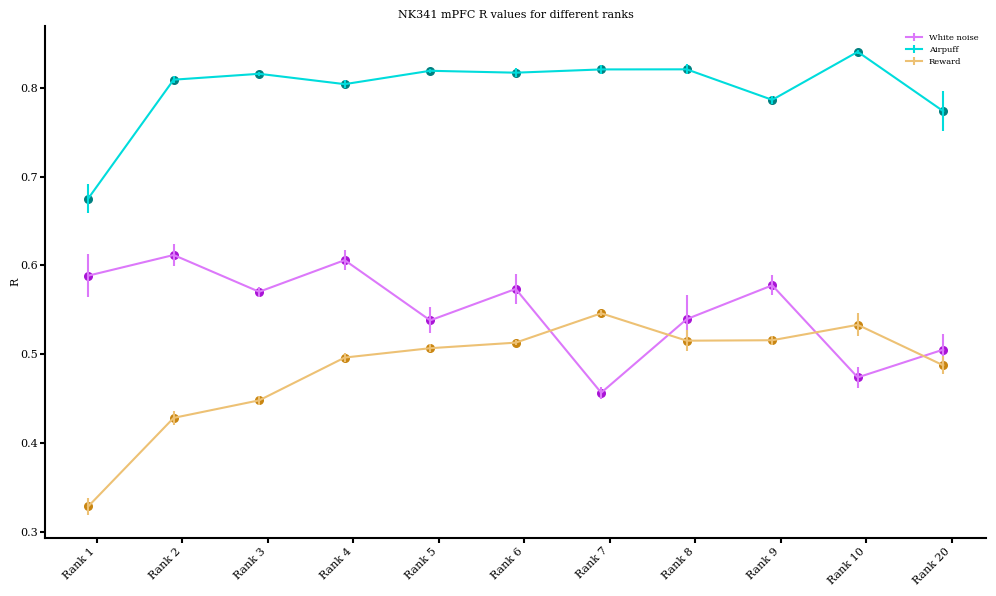

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'NK341 mPFC R values for different ranks'}, ylabel='R'>)

In [139]:
r_white_noise_dict = [r_vals_white_noise, r_vals_airpuff, r_vals_reward]
plot_grouped_bars(r_white_noise_dict, 'nk341_r_trials_rank_comp.png', dict_labels=['White noise', 'Airpuff', 'Reward'], title="NK341 mPFC R values for different ranks", x_labels=["Rank 1", "Rank 2", "Rank 3", "Rank 4", "Rank 5", "Rank 6", "Rank 7", "Rank 8", "Rank 9", "Rank 10", "Rank 20"], y_label="R")
# fig, ax = plot_grouped_bars(r_airpuff_dict, 'nk341_r_airpuff_rank_comp.png', title="NK341 mPFC R airpuff comparison", y_label="R", x_labels=["Rank 1", "Rank 2", "Rank 3", "Rank 4", "Rank 5", "Rank 6", "Rank 7", "Rank 8", "Rank 9", "Rank 10", "Rank 20"], fig=fig, ax=ax)
# fig, ax = plot_grouped_bars(r_reward_dict, 'nk341_r_reward_rank_comp.png', title="NK341 mPFC R Trial comparison", y_label="R", x_labels=["Rank 1", "Rank 2", "Rank 3", "Rank 4", "Rank 5", "Rank 6", "Rank 7", "Rank 8", "Rank 9", "Rank 10", "Rank 20"], fig=fig, ax=ax)


### Study population responses during airpuffs

In [100]:
trajs_airpuff, r_vals_airpuff, avg_trajs_airpuff, test_avg_trajs_airpuff, r2_dist_airpuff, r_dist_airpuff = temporal_eval('airpuff', 10, sanity_check=False)
# visualize the mean population activity of each model along white noise trials 
# white_noise_model_pop_response = get_model_population_response(avg_trajs_white_noise)

dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic r: 0.5254573314643081
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic r: 0.5943321398037219
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic r: 0.6304304517847906
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using un

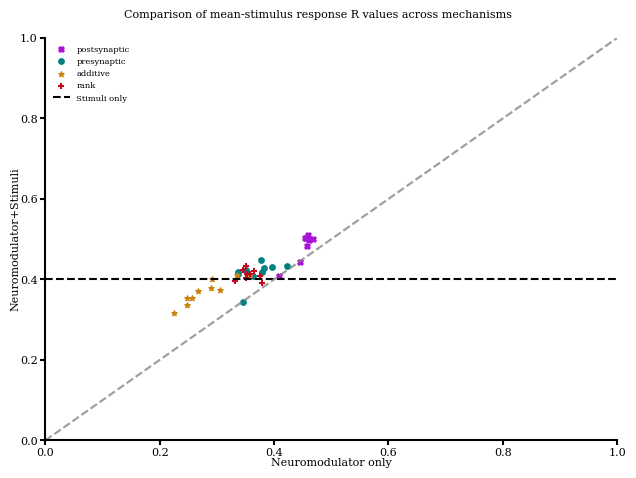

In [39]:
plot_scatter(r_vals_reward, 'Comparison of mean-stimulus response R values across mechanisms', 'nk341_reward_r_scatter.png')

In [32]:
results_dir = '../../results/pickle/'
with open(os.path.join(results_dir, 'nk341_airpuff_r_vals.pkl'), "wb") as f:
    pickle.dump(r_vals_airpuff, f) 

In [36]:
with open(os.path.join(results_dir, 'nk341_white_noise_r_vals.pkl'), "wb") as f:
    pickle.dump(r_vals_white_noise, f) 

In [37]:
with open(os.path.join(results_dir, 'nk341_reward_r_vals.pkl'), "wb") as f:
    pickle.dump(r_vals_reward, f) 

### Reward

In [136]:
trajs_reward, r_vals_reward, avg_trajs_reward, test_avg_trajs_reward, r2_dist_reward, r_dist_reward = temporal_eval('reward', 10, sanity_check=False)
# visualize the mean population activity of each model along white noise trials 
# white_noise_model_pop_response = get_model_population_response(avg_trajs_white_noise)

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic r: 0.13359304187768065
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic r: 0.10981060590939559
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic r: 0.11682988256505719
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic

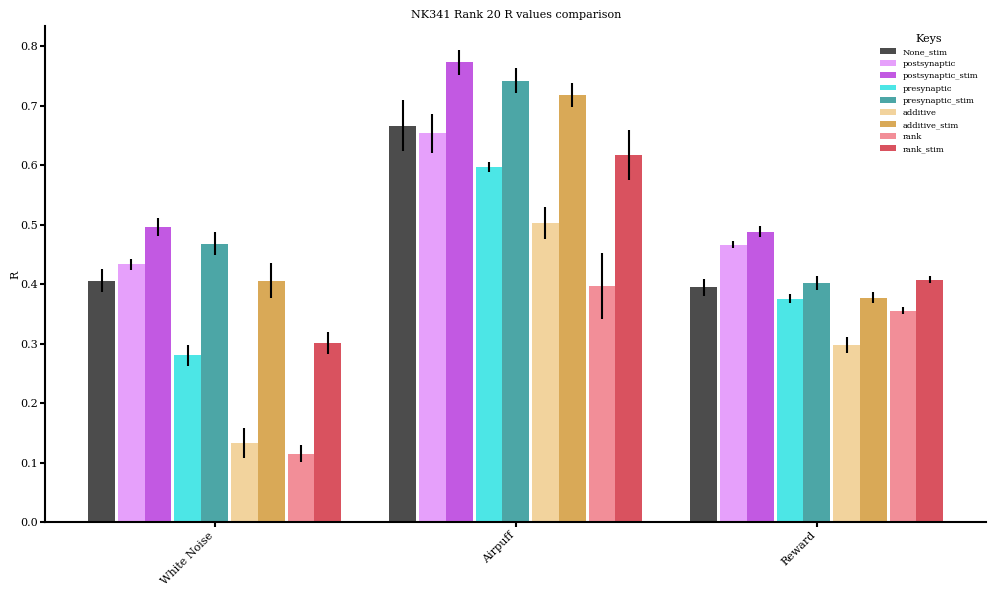

<Figure size 640x480 with 0 Axes>

In [33]:
r_dict = [r_vals_white_noise, r_vals_airpuff, r_vals_reward]
plot_grouped_bars_by_dict(r_dict, figname='nk341_rank_20_r.png', title="NK341 Rank 20 R values comparison", x_labels=['White Noise', 'Airpuff', 'Reward'], y_label="R")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

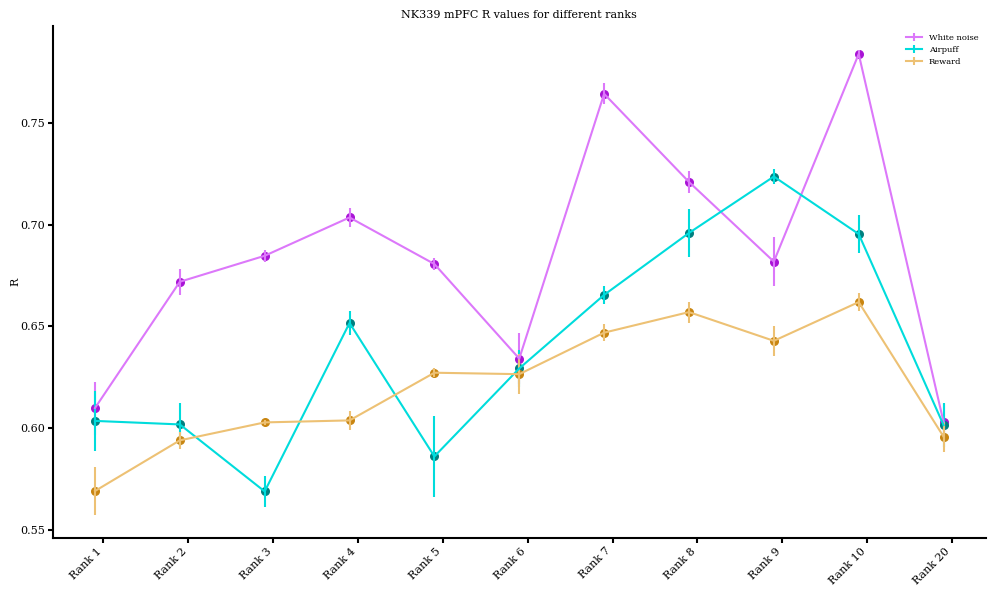

<Figure size 640x480 with 0 Axes>

In [33]:
r_dict = [r_vals_white_noise, r_vals_airpuff, r_vals_reward]
plot_grouped_bars_line(r_dict, figname='nk339_r_trials_rank_comp.png', dict_labels=['White noise', 'Airpuff', 'Reward'], title="NK339 mPFC R values for different ranks", x_labels=ranks, y_label="R")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

In [ ]:
mre_dict = [mres_baseline]
plot_grouped_bars_line(mre_dict, 'nk339_mres_rank_comp.png', title="NK339 Mean-rate error comparison across ranks", x_labels=ranks, y_label="Mean-rate error")
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()
# plt.savefig()

## Perturbation experiment on Odor trials

In [20]:
trajs_odor, r_vals_odor, avg_trajs_odor, test_avg_trajs_odor, r2_dist_odor, r_dist_odor = temporal_eval('odor', 10, sanity_check=False)
# visualize the mean population activity of each model along white noise trials 
# white_noise_model_pop_response = get_model_population_response(avg_trajs_white_noise)

dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_u', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic_stim r: 0.3594556975337733
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_u', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic_stim r: 0.36399769341654475
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_u', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Model postsynaptic_stim r: 0.3599822207498625
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_u', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type:

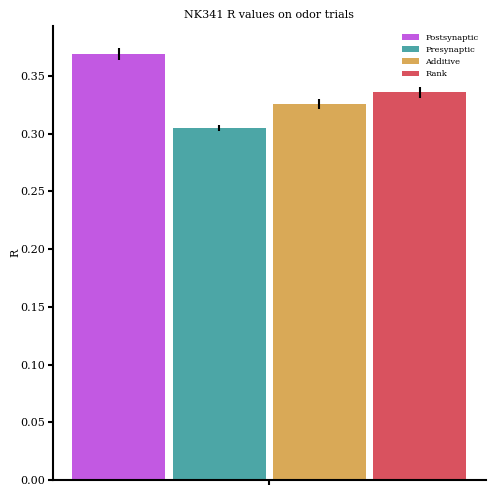

<Figure size 640x480 with 0 Axes>

In [34]:
r_dict = [r_vals_odor]
c = ["#a913d6", "#008080", "#c98510", "#c9081b"]
plot_grouped_bars_by_dict(r_dict, figname='nk341_rank_20_r_odor.png', dict_labels=['Postsynaptic', 'Presynaptic', 'Additive', 'Rank'], title="NK341 R values on odor trials", x_labels=[], y_label="R", c=c, extra_spacing=False)
# plot_bar_scatter_sem(ax, r_vals_reward, 'R (reward)', y_label='R')
plt.tight_layout()
plt.show()

## Do significance testing 

In [41]:
def plot_scatter(r_vals,ax):
    models = ['postsynaptic', 'presynaptic', 'additive', 'rank']
    colors = ["#a913d6",  "#008080", "#c98510", "#c9081b"]
    # stim_only_avg = np.array(r_vals['None_stim']).mean()

    
    for i, model in enumerate(models):
        ax.scatter(r_vals[model], r_vals[f'{model}_stim'], c=colors[i], marker='o', s=20, label=models[i],edgecolors='black',alpha=0.5)
        plt.plot(np.mean(r_vals[model]), np.mean(r_vals[f'{model}_stim']), c=colors[i], marker="o", markersize=10,markeredgecolor='black', alpha=1)
    # print(stim_only_avg)
    # ax.axhline(stim_only_avg, linestyle='-', c='black')

    ax.set_xticks([0,0.25,0.5,0.75,1],[0,'','','',1])
    ax.set_yticks([0,0.25,0.5,0.75,1],[0,0.3,0.4,'',1])
    
    ax.set_xlabel('neuromodulation only (r)')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    # Fill below y = x (lower triangle)
    x_fill = np.linspace(0, 1, 100)
    ax.fill_between(x_fill, 0, x_fill, color='grey', alpha=0.2)
    ax.legend(loc='lower right', fontsize=8)

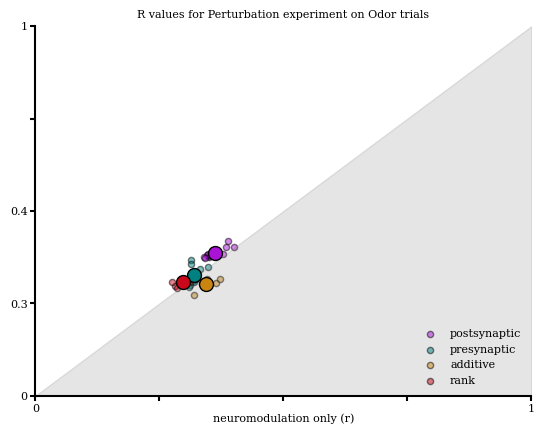

In [45]:
fig, ax = plt.subplots()
plot_scatter(r_vals_odor, ax) 
ax.set_title('R values for Perturbation experiment on Odor trials')
fig.savefig('../../results/figures/nk341_perturbation_odor.png')

### Look at the distributions of r values for the trials

          W      pval  normal
0  2.865031  0.238708    True
          W      pval  normal
0  7.305245  0.025923   False
4.986228399793376 9.565111777705767e-05


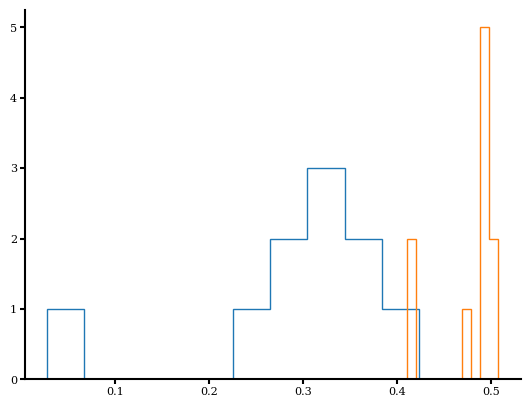

In [125]:
from scipy import stats
counts, bins = np.histogram(r_vals_white_noise['None_stim'])
plt.stairs(counts, bins)
counts, bins = np.histogram(r_vals_white_noise['postsynaptic_stim'])
plt.stairs(counts, bins)
results = pg.normality(r_vals_white_noise['postsynaptic_stim'], method='jarque_bera')
print(results)
results = pg.normality(r_vals_white_noise['None_stim'], method='jarque_bera')
print(results)
t_stat, p_value = stats.ttest_ind(r_vals_white_noise['postsynaptic_stim'], r_vals_white_noise['None_stim'])
print(t_stat, p_value)

In [50]:
import pingouin as pg

d = pg.compute_effsize(r_vals_white_noise['postsynaptic_stim'], r_vals_white_noise['None_stim'], eftype='cohen', paired=True)
print("Cohen's d:", d)

Cohen's d: 2.229909130655598


           W      pval  normal
0  19.020722  0.000074   False
           W      pval  normal
0  13.972754  0.000924   False
3.2000707263623 0.010830073329815181


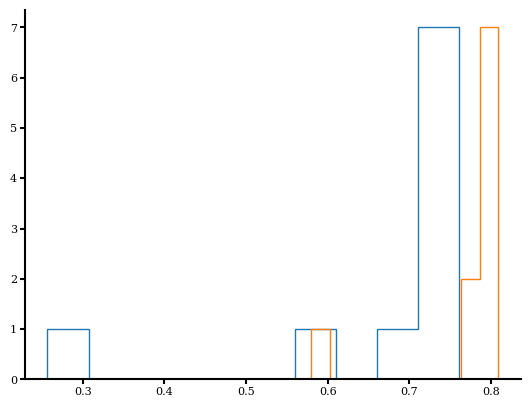

In [126]:
from scipy import stats
counts, bins = np.histogram(r_vals_airpuff['None_stim'])
plt.stairs(counts, bins)
counts, bins = np.histogram(r_vals_airpuff['postsynaptic_stim'])
plt.stairs(counts, bins)
results = pg.normality(r_vals_airpuff['postsynaptic_stim'], method='jarque_bera')
print(results)
results = pg.normality(r_vals_airpuff['None_stim'], method='jarque_bera')
print(results)
t_stat, p_value = stats.ttest_rel(r_vals_airpuff['postsynaptic_stim'], r_vals_airpuff['None_stim'])
print(t_stat, p_value)

In [45]:
d = pg.compute_effsize(r_vals_airpuff['postsynaptic_stim'], r_vals_airpuff['None_stim'], eftype='cohen', paired=True)
print("Cohen's d:", d)

Cohen's d: 0.753833225643029


          W     pval  normal
0  3.488799  0.17475    True
          W      pval  normal
0  2.318984  0.313645    True
11.410425954812592 1.1812566879823544e-06


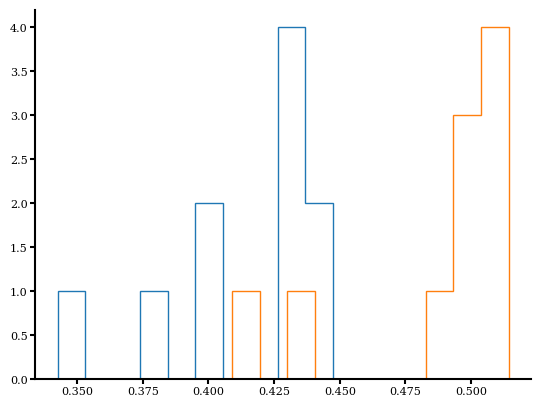

In [130]:
from scipy import stats
counts, bins = np.histogram(r_vals_reward['None_stim'])
plt.stairs(counts, bins)
counts, bins = np.histogram(r_vals_reward['postsynaptic_stim'])
plt.stairs(counts, bins)
results = pg.normality(r_vals_reward['postsynaptic_stim'], method='jarque_bera')
print(results)
results = pg.normality(r_vals_reward['None_stim'], method='jarque_bera')
print(results)
t_stat, p_value = stats.ttest_rel(r_vals_reward['postsynaptic_stim'], r_vals_reward['None_stim'])
print(t_stat, p_value)

In [132]:
d = pg.compute_effsize(r_vals_reward['postsynaptic_stim'], r_vals_reward['None_stim'], eftype='cohen', paired=True)
print("Cohen's d:", d)

Cohen's d: 2.147015750252811


          W     pval  normal
0  0.547058  0.76069    True
          W      pval  normal
0  0.037195  0.981575    True
-3.443912158161729 0.00734498306468186


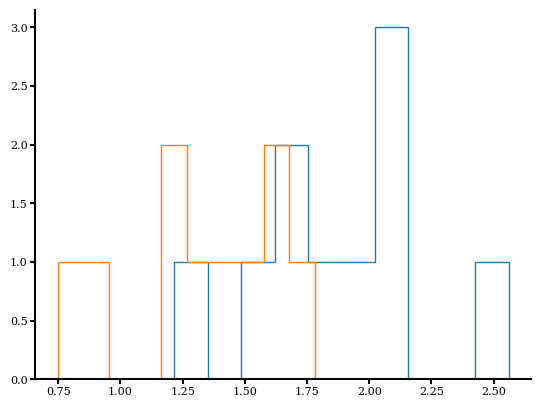

In [127]:
counts, bins = np.histogram(kl_divs_baseline['None_stim'])
plt.stairs(counts, bins)
counts, bins = np.histogram(kl_divs_baseline['postsynaptic_stim'])
plt.stairs(counts, bins)
results = pg.normality(kl_divs_baseline['postsynaptic_stim'], method='jarque_bera')
print(results)
results = pg.normality(kl_divs_baseline['None_stim'], method='jarque_bera')
print(results)
t_stat, p_value = stats.ttest_rel(kl_divs_baseline['postsynaptic_stim'], kl_divs_baseline['None_stim'])
print(t_stat, p_value)

In [114]:
d = pg.compute_effsize(kl_divs_baseline['postsynaptic_stim'], kl_divs_baseline['None_stim'], eftype='cohen', paired=True)
print("Cohen's d:", d)

Cohen's d: -1.595531025502964


          W      pval  normal
0  0.396101  0.820329    True
          W      pval  normal
0  0.025228  0.987465    True
-2.3180520955085275 0.04563108796692174


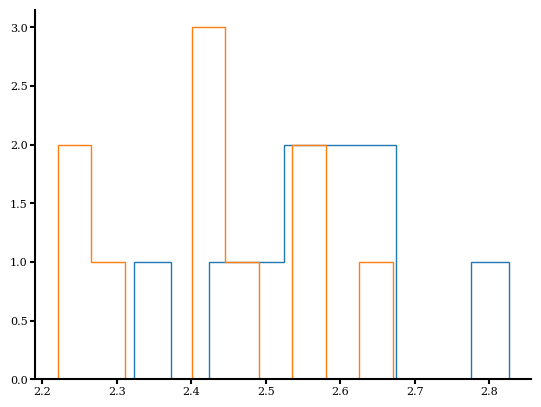

In [128]:
counts, bins = np.histogram(was_dists_baseline['None_stim'])
plt.stairs(counts, bins)
counts, bins = np.histogram(was_dists_baseline['postsynaptic_stim'])
plt.stairs(counts, bins)
results = pg.normality(was_dists_baseline['postsynaptic_stim'], method='jarque_bera')
print(results)
results = pg.normality(was_dists_baseline['None_stim'], method='jarque_bera')
print(results)
t_stat, p_value = stats.ttest_rel(was_dists_baseline['postsynaptic_stim'], was_dists_baseline['None_stim'])
print(t_stat, p_value)

In [116]:
d = pg.compute_effsize(was_dists_baseline['postsynaptic_stim'], was_dists_baseline['None_stim'], eftype='cohen', paired=True)
print("Cohen's d:", d)

Cohen's d: -1.0122799702874858


-1.2935691104864322 0.22802567666883902


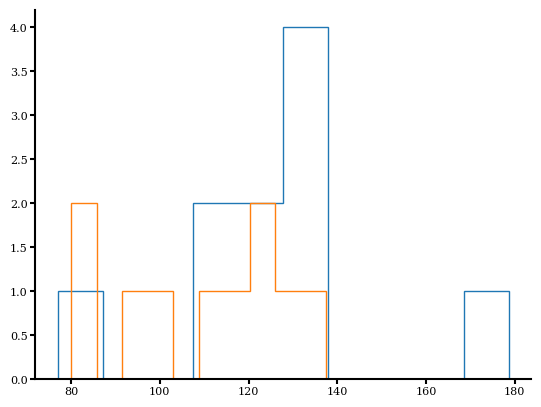

In [118]:
counts, bins = np.histogram(mres_baseline['None_stim'])
plt.stairs(counts, bins)
counts, bins = np.histogram(mres_baseline['postsynaptic'])
plt.stairs(counts, bins)
t_stat, p_value = stats.ttest_rel(mres_baseline['postsynaptic'], mres_baseline['None_stim'])
print(t_stat, p_value)

In [119]:
d = pg.compute_effsize(mres_baseline['postsynaptic_stim'], mres_baseline['None_stim'], eftype='cohen', paired=True)
print("Cohen's d:", d)

Cohen's d: -0.47209311996457104


### Plot population responses

In [145]:
def plot_population_response(trajs, mechanisms, c_lines=None, c_shades=None, figname=''):
    fig, ax = plt.subplots(1, len(mechanisms) + 1, figsize=(15, 4))
    # get the actual population average response 
    test_trajs_avg = torch.stack(trajs['test']).mean(axis=0).detach() 
    y_test = test_trajs_avg.mean(axis=0).detach() 
    stdevs_test = test_trajs_avg.std(axis=0) / len(trajs['test'])
    x = np.arange(0, len(y_test))
    
    ax[0].plot(y_test)
    ax[0].fill_between(x, y_test - stdevs_test, y_test + stdevs_test, color='blue', alpha=0.2)
    ax[0].set_title('Test')
    for i, mechanism in enumerate(mechanisms):
        trajs_avg = torch.stack(trajs[mechanism]).mean(axis=0).detach()
        # get the population standard deviation across time 
        stdevs = trajs_avg.std(axis=0) / len(trajs[mechanism])
        # plot the population mean
        y = trajs_avg.mean(axis=0).detach()
        ax[i+1].plot(y, c=c_lines[i])
        ax[i+1].fill_between(x, y - stdevs, y + stdevs, color=c_shades[i], alpha=0.2)
        ax[i+1].set_yticks([])
        ax[i+1].set_xticks([])
        ax[i+1].set_title(mechanism)
    fig.savefig(f'../../results/figures/{figname}')

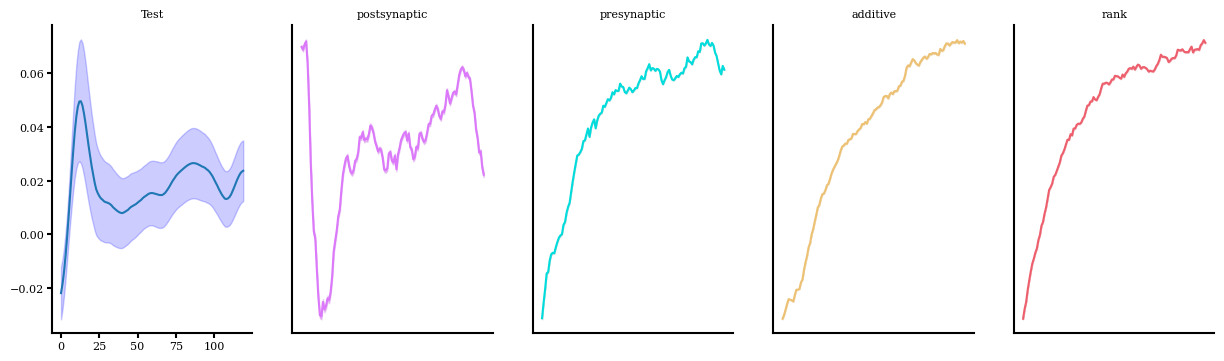

In [146]:
colors = ["#000000", "#dc78fa", "#a913d6",  "#00DCDC", "#008080", "#edc174", "#c98510",  "#ed5f6d", "#c9081b"]
mechanisms = ['postsynaptic', 'presynaptic', 'additive', 'rank']
plot_population_response(trajs_white_noise, mechanisms, c_lines=colors[1::2], c_shades=colors[2::2], figname='nk341_pertubation_population_activity_white_noise.png')

### Airpuff

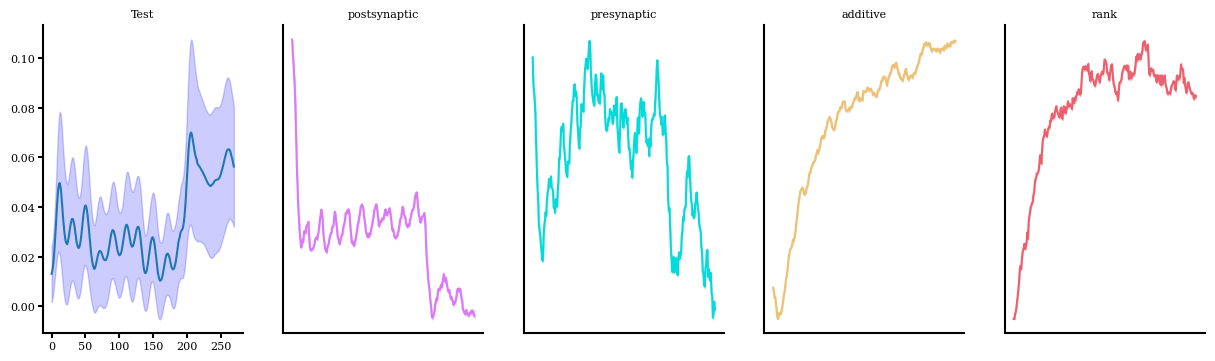

In [147]:
colors = ["#000000", "#dc78fa", "#a913d6",  "#00DCDC", "#008080", "#edc174", "#c98510",  "#ed5f6d", "#c9081b"]
mechanisms = ['postsynaptic', 'presynaptic', 'additive', 'rank']
plot_population_response(trajs_airpuff, mechanisms, c_lines=colors[1::2], c_shades=colors[2::2], figname='nk341_perturbation_population_activity_airpuff.png')

### Reward

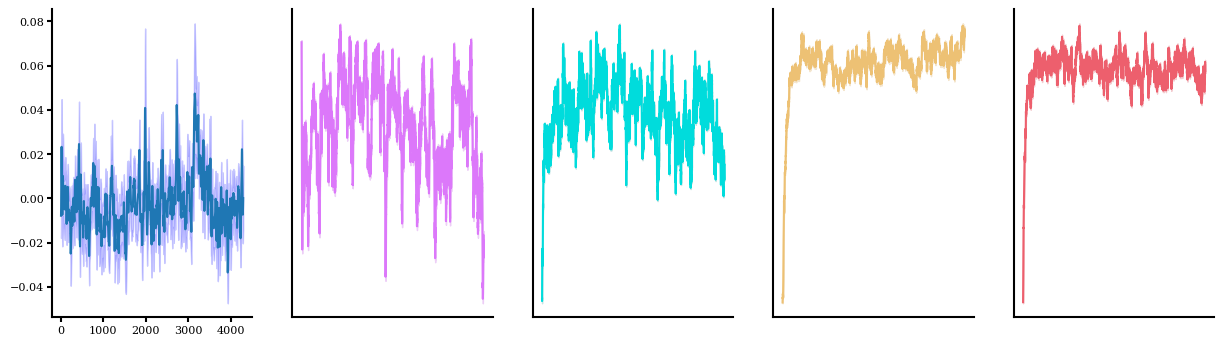

In [137]:
colors = ["#000000", "#dc78fa", "#a913d6",  "#00DCDC", "#008080", "#edc174", "#c98510",  "#ed5f6d", "#c9081b"]
mechanisms = ['postsynaptic', 'presynaptic', 'additive', 'rank']
plot_population_response(trajs_reward, mechanisms, c_lines=colors[1::2], c_shades=colors[2::2])

In [197]:
def plot_traces(trajs):
    neurons = [32, 10, 133, 17, 78, 14, 66, 4]
    fig, ax = plt.subplots(len(neurons),5, figsize=(15,10))
    trial_avgs = {}
    trial_idx = 1
    mechanisms = ['None_stim', 'postsynaptic_stim', 'presynaptic_stim', 'additive_stim', 'rank_stim', 'test']
    for mechanism in mechanisms:
        trial_avgs[mechanism] = torch.stack(trajs[mechanism][0:20]).mean(axis=0)
    
    # inhibited = [133, 108, 137, 9, 128]
    for i, neuron in enumerate(neurons): #, [32, 10, 133, 17, 78]
        for j, model in enumerate(mechanisms[:-1]):
            ax[i, j].plot(trial_avgs[model][neuron].detach(), label='Gen')
            ax[i, j].plot(trial_avgs['test'][neuron].detach(), label='Test')
            if i == 0:
                ax[i, j].set_title(model)
                    # ax[i, j].legend(loc='upper left')
    plt.tight_layout()
    handles, labels = ax[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=3)
    # fig.savefig('../../results/white_noise_trajs.png')

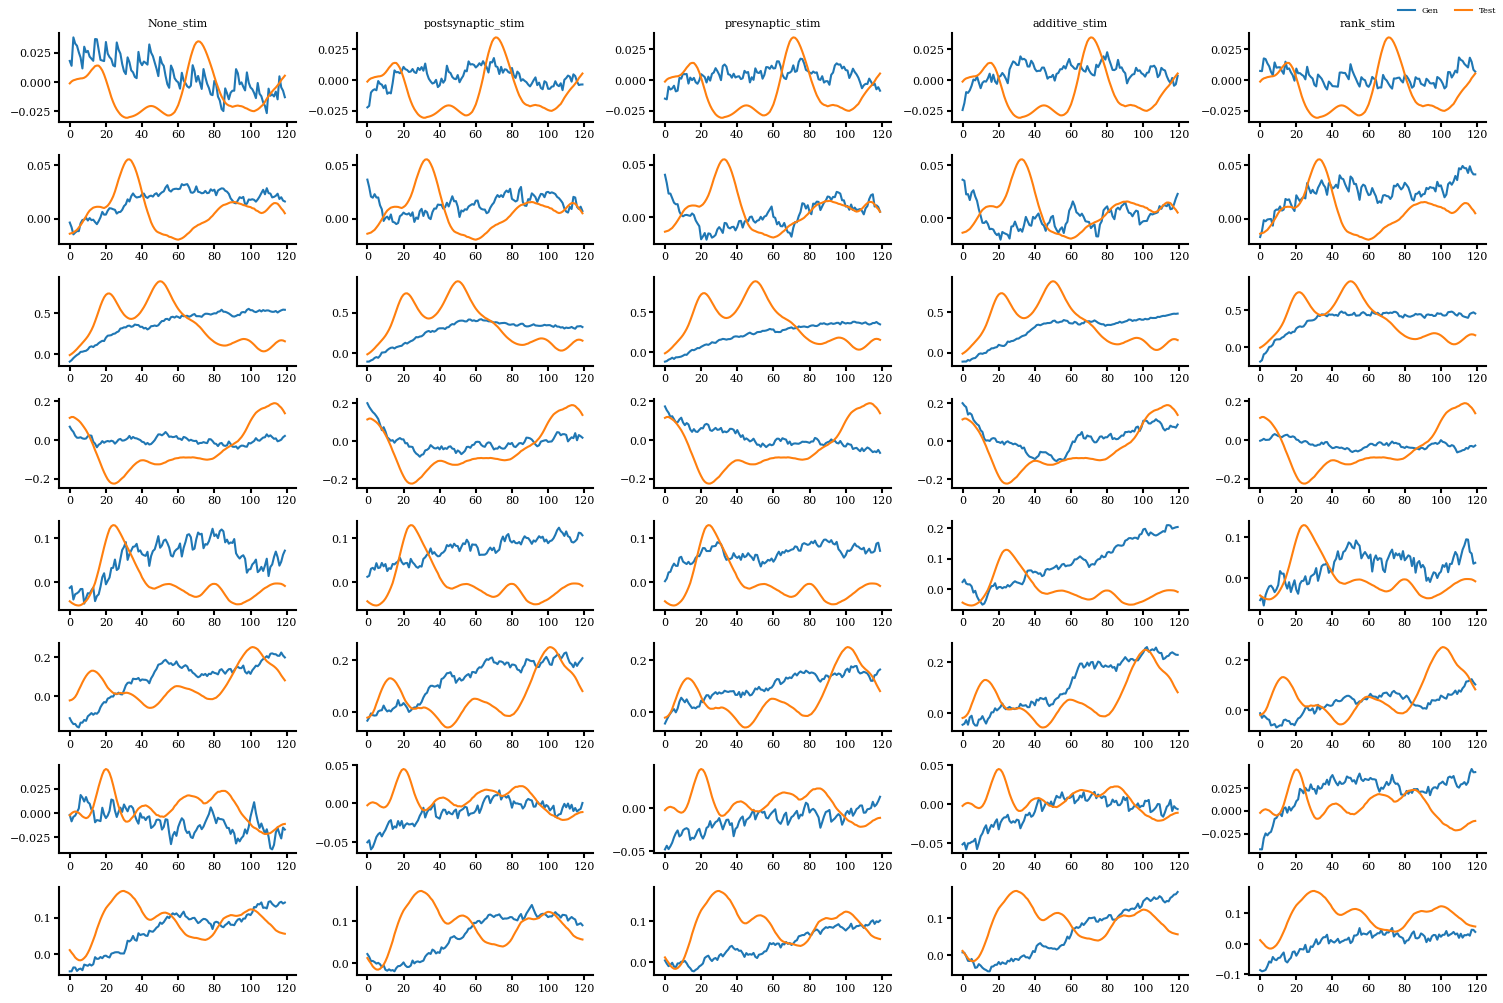

In [198]:
plot_traces(trajs_white_noise)

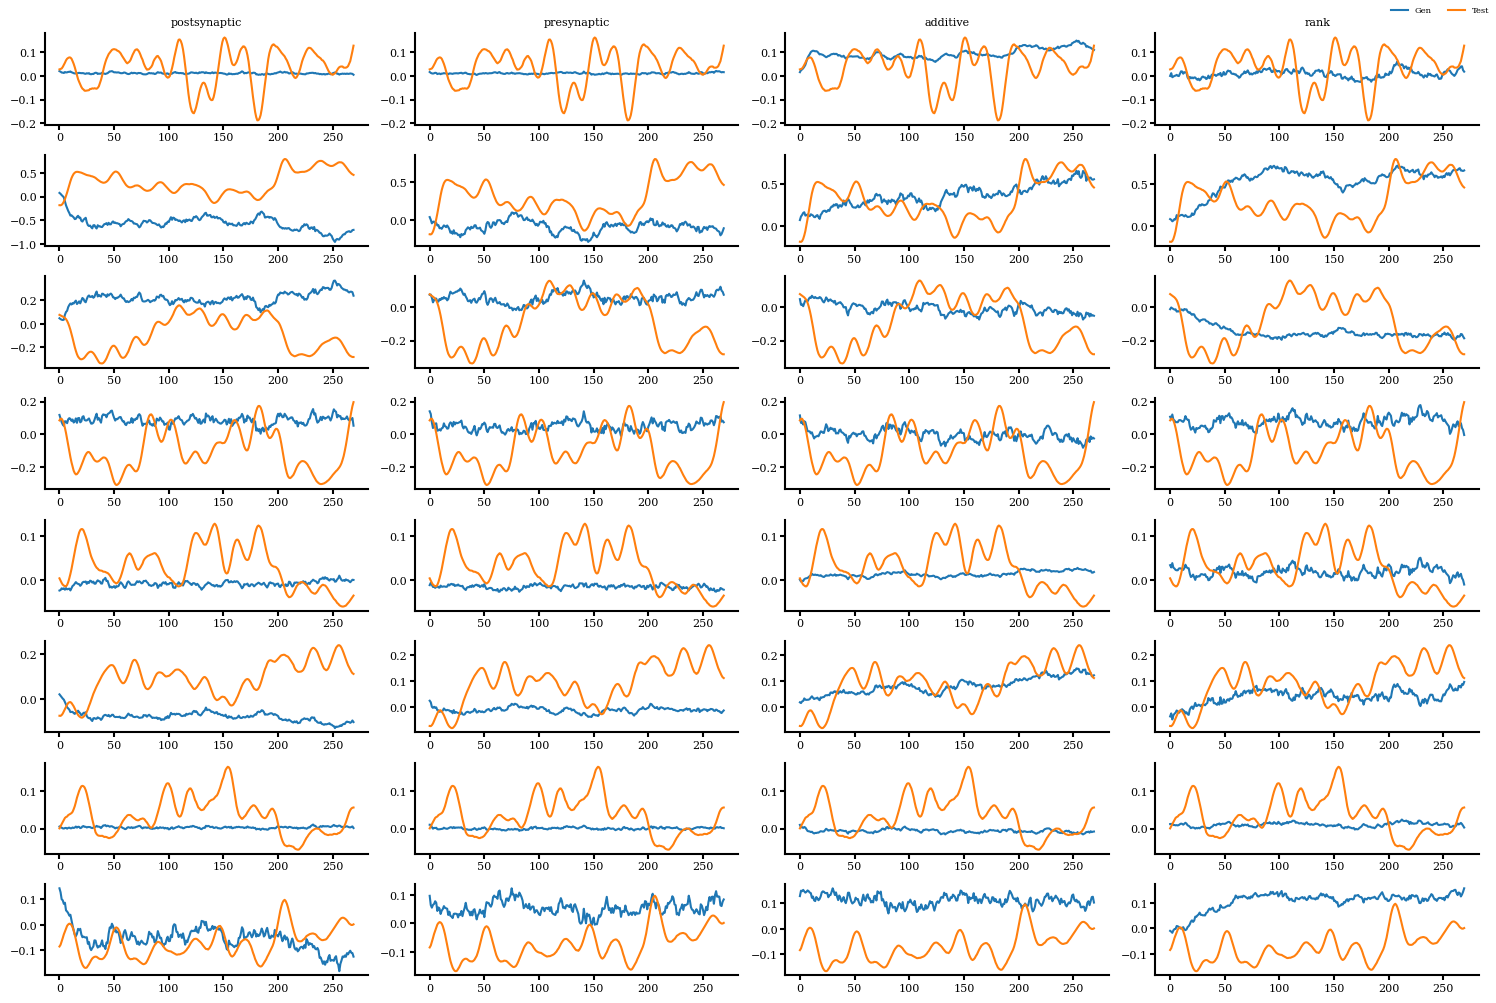

In [56]:
plot_traces(trajs_airpuff)

(0.42674358248918426, 0.017661637166605067)

In [148]:
np.array(kl_divs[1]['postsynaptic']).mean(), np.array(kl_divs[1]['postsynaptic']).std() / np.sqrt(len(kl_divs[1]['postsynaptic']))

(0.4677683159441878, 0.011599907920269208)

In [149]:
np.array(kl_divs[1]['postsynaptic_stim']).mean(), np.array(kl_divs[1]['postsynaptic_stim']).std() / np.sqrt(len(kl_divs[1]['postsynaptic_stim']))

(0.6003900801466481, 0.009695372269929088)

In [150]:
np.array(kl_divs[1]['additive']).mean(), np.array(kl_divs[1]['additive']).std() / np.sqrt(len(kl_divs[1]['additive']))

(0.4114219819532778, 0.008688668507471728)

In [151]:
np.array(kl_divs[1]['additive_stim']).mean(), np.array(kl_divs[1]['additive_stim']).std() / np.sqrt(len(kl_divs[1]['additive_stim']))

(0.5526944563894979, 0.008819289130903976)

In [158]:
(0.60 - 0.42) / (0.42)

0.42857142857142855

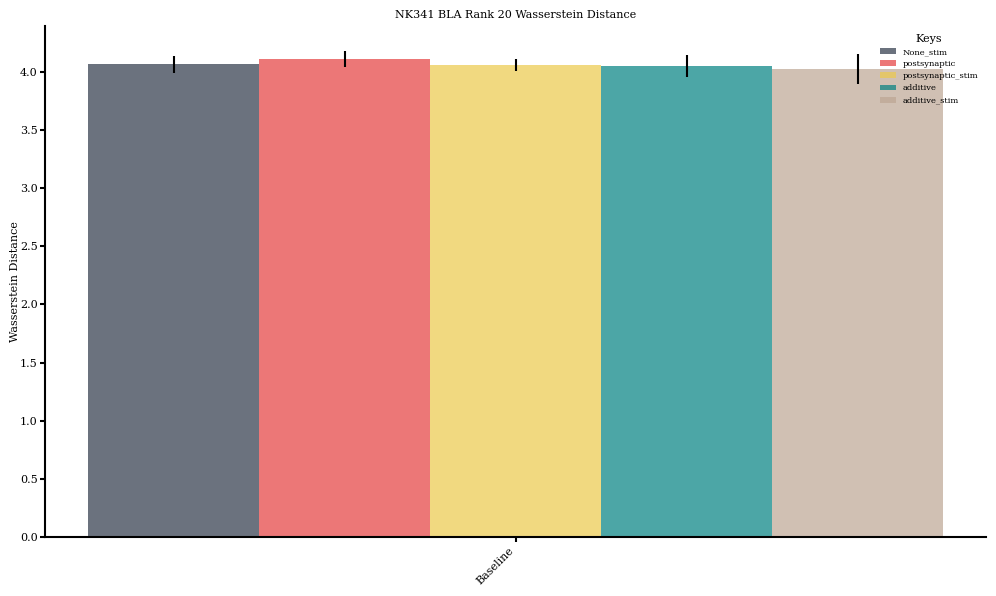

In [18]:
with open(os.path.join(results_dir, 'nk341_BLA_rank_20_was_dists.pkl'), "rb") as f:
    was_dists = pickle.load(f)
plot_grouped_bars_by_dict([was_dists[0]], figname='nk341_BLA_rank_20_was_dists_benchmark.png', title="NK341 BLA Rank 20 Wasserstein Distance", x_labels=['Baseline'], y_label="Wasserstein Distance")

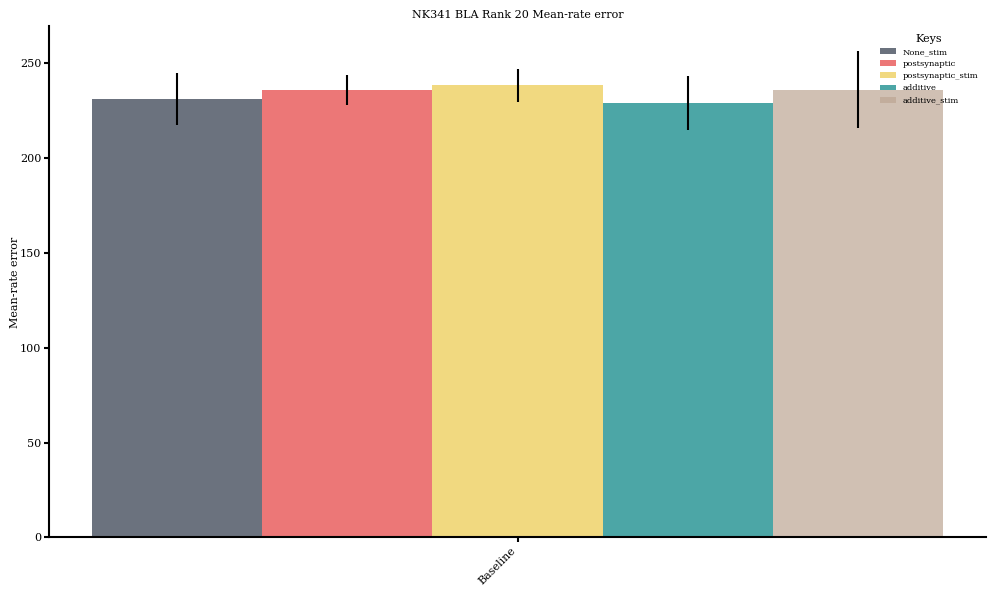

In [19]:
with open(os.path.join(results_dir, 'nk341_BLA_rank_20_mres.pkl'), "rb") as f:
    was_dists = pickle.load(f)
plot_grouped_bars_by_dict([was_dists[0]], figname='nk341_BLA_rank_20_mres_benchmark.png', title="NK341 BLA Rank 20 Mean-rate error", x_labels=['Baseline'], y_label="Mean-rate error")

In [34]:
# save results array
results_dir = '../../results' 
with open(os.path.join(results_dir, 'nk339_rank_20_r.pkl'), "wb") as f:
    pickle.dump(r_dict, f) 

traj_dict = [trajs_white_noise, trajs_airpuff, trajs_reward]
with open(os.path.join(results_dir, 'nk339_rank_20_trajs.pkl'), "wb") as f:
    pickle.dump(traj_dict, f) 

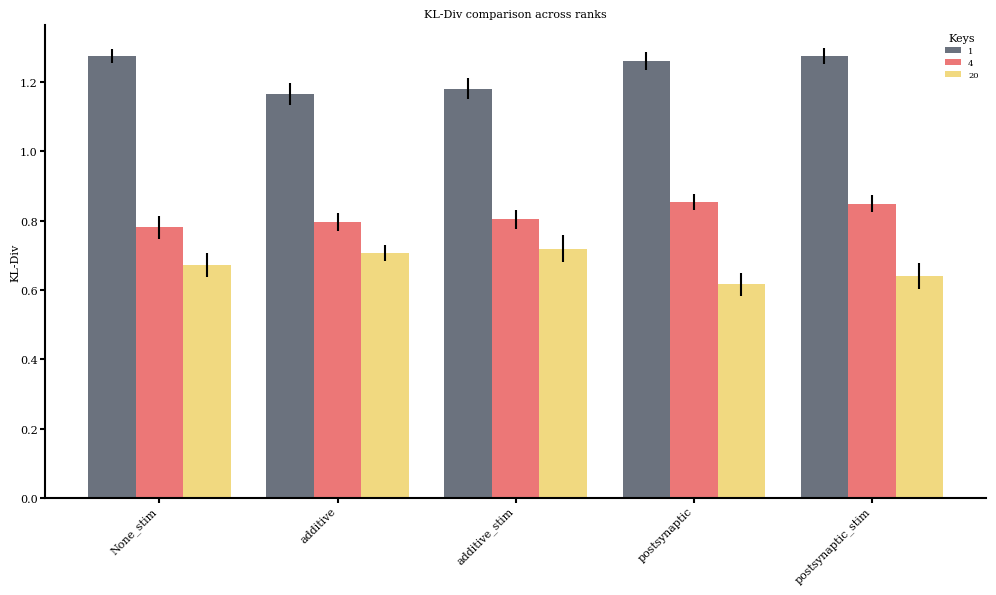

In [72]:
# compare performance across ranks
import pickle 
results_dir = '../../results' 
with open(os.path.join(results_dir, 'nk341_rank_1_kl_divs.pkl'), "rb") as f:
    kl_divs_rank_1 = pickle.load(f)
with open(os.path.join(results_dir, 'nk341_rank_4_kl_divs.pkl'), "rb") as f:
    kl_divs_rank_4 = pickle.load(f)
with open(os.path.join(results_dir, 'nk341_rank_20_kl_divs.pkl'), "rb") as f:
    kl_divs_rank_20 = pickle.load(f)

def get_rank_comparisons(results_arr, idx):
    # group by mechanism and perform comparisons on baseline 
    models = ['None_stim', 'additive', 'additive_stim', 'postsynaptic', 'postsynaptic_stim']
    results = []
    for model in models:
        result_dict = {}
        for i, rank in enumerate([1, 4, 20]):
            result_dict[rank] = results_arr[i][idx][model]
        results.append(result_dict)
    return results

models = ['None_stim', 'additive', 'additive_stim', 'postsynaptic', 'postsynaptic_stim']
kl_divs = [kl_divs_rank_1, kl_divs_rank_4, kl_divs_rank_20]
baseline_results = get_rank_comparisons(kl_divs, 0)
plot_grouped_bars_by_dict(baseline_results, title='KL-Div comparison across ranks', x_labels=models, y_label='KL-Div', keys=['Rank 1', 'Rank 4', 'Rank 20'], figname='rank_comparisons_kl.png')

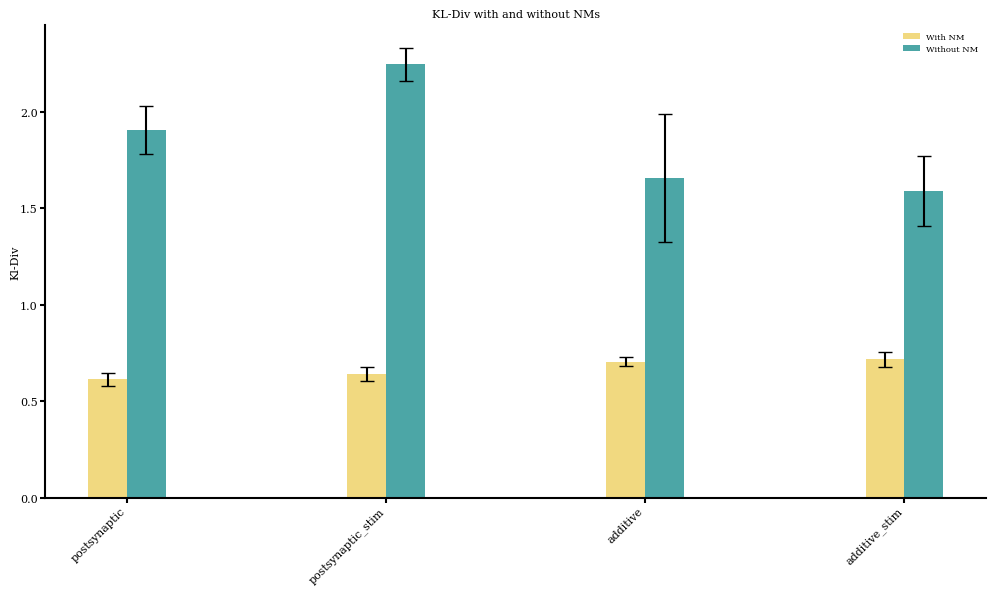

In [116]:
# do sanity check comparisons
with open(os.path.join(results_dir, 'nk341_rank_20_kl_divs.pkl'), "rb") as f:
    kl_divs_rank_20 = pickle.load(f)
del kl_divs_rank_20[0]['None_stim']
kl_divs = [kl_divs_rank_20[0], kl_divs_baseline]
models = ['additive', 'additive_stim', 'postsynaptic', 'postsynaptic_stim']
plot_grouped_bars(kl_divs, 'sanity_check_kl_div.png', dict_labels=['With NM', 'Without NM'], title="KL-Div with and without NMs", y_label="Kl-Div")

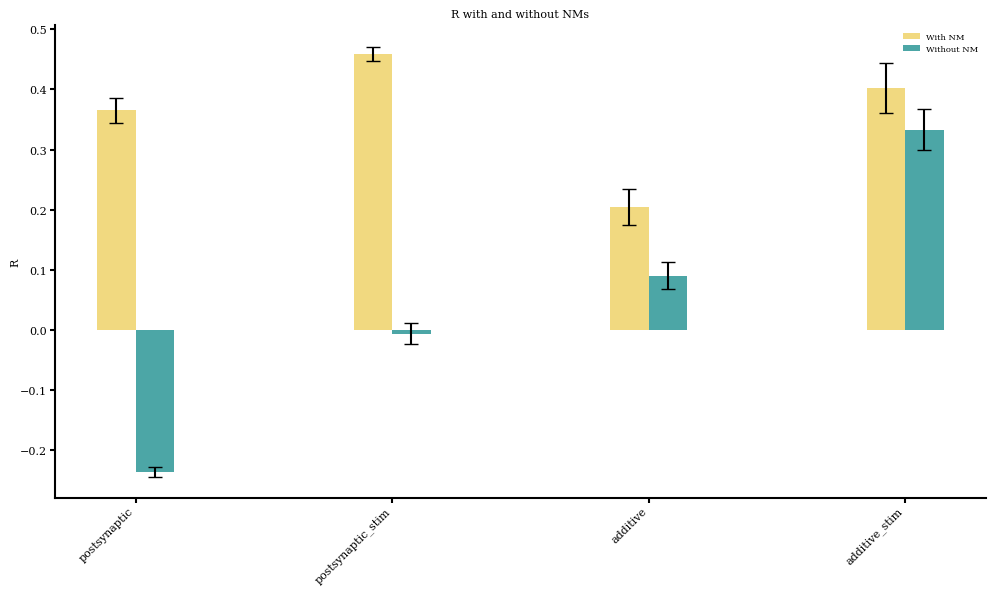

In [117]:
# do sanity check comparisons
with open(os.path.join(results_dir, 'nk341_rank_20_r.pkl'), "rb") as f:
    rs_rank_20 = pickle.load(f)
del rs_rank_20[1]['None_stim']
rs = [rs_rank_20[1], r_vals_white_noise]
plot_grouped_bars(rs, 'sanity_check_r_white_noise.png', dict_labels=['With NM', 'Without NM'], title="R with and without NMs", y_label="R")

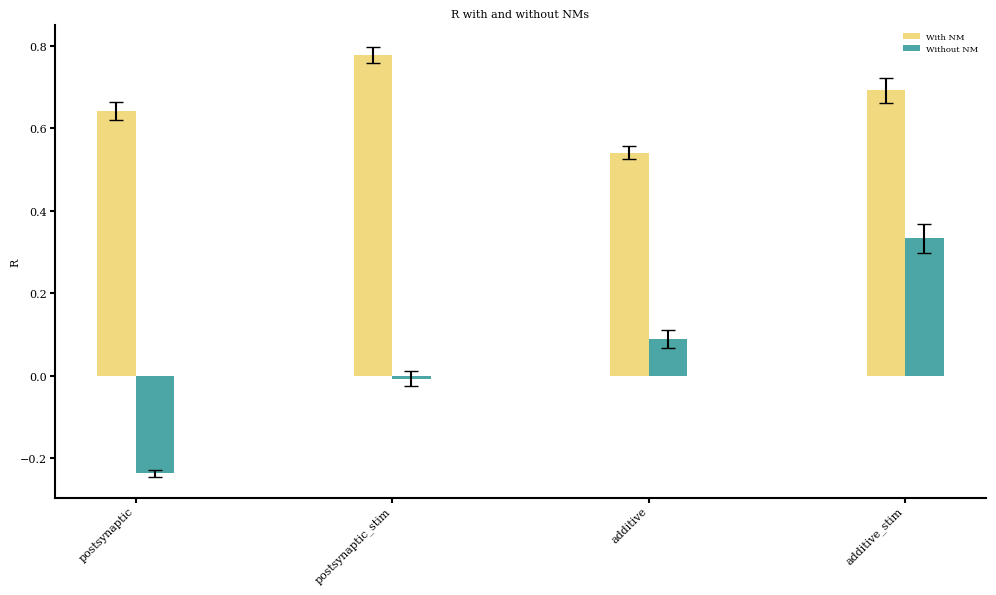

In [118]:
# do sanity check comparisons
with open(os.path.join(results_dir, 'nk341_rank_20_r.pkl'), "rb") as f:
    rs_rank_20 = pickle.load(f)
del rs_rank_20[2]['None_stim']
rs = [rs_rank_20[2], r_vals_white_noise]
plot_grouped_bars(rs, 'sanity_check_r_airpuff.png', dict_labels=['With NM', 'Without NM'], title="R with and without NMs", y_label="R")

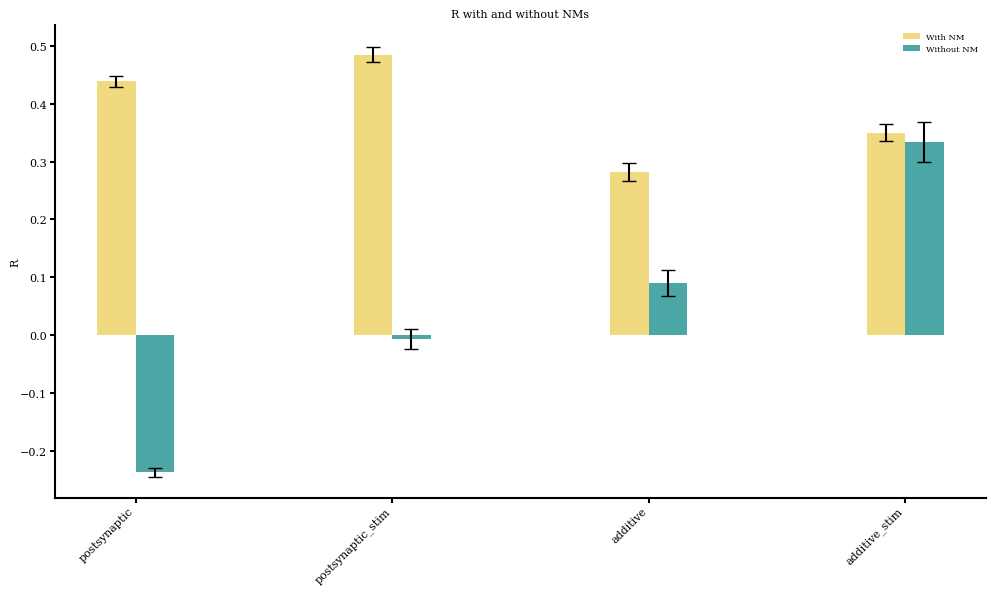

In [119]:
# do sanity check comparisons
with open(os.path.join(results_dir, 'nk341_rank_20_r.pkl'), "rb") as f:
    rs_rank_20 = pickle.load(f)
del rs_rank_20[3]['None_stim']
rs = [rs_rank_20[3], r_vals_white_noise]
plot_grouped_bars(rs, 'sanity_check_r_reward.png', dict_labels=['With NM', 'Without NM'], title="R with and without NMs", y_label="R")

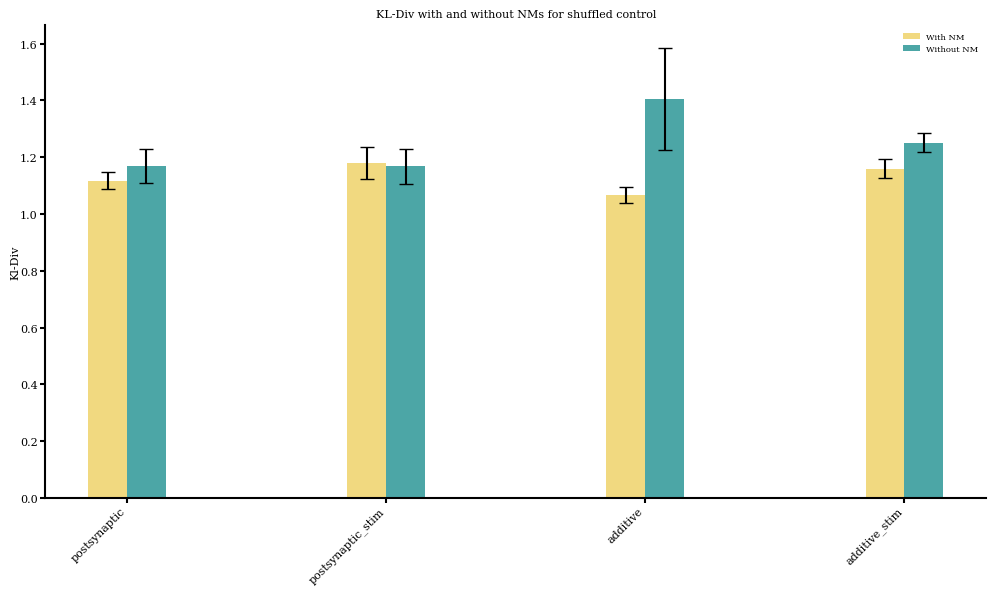

In [23]:
# do sanity checks with controls 
kl_divs = [kl_divs_baseline, kl_divs_baseline_cut]
plot_grouped_bars(kl_divs, 'sanity_check_kl_div_control.png', dict_labels=['With NM', 'Without NM'], title="KL-Div with and without NMs for shuffled control", y_label="Kl-Div")

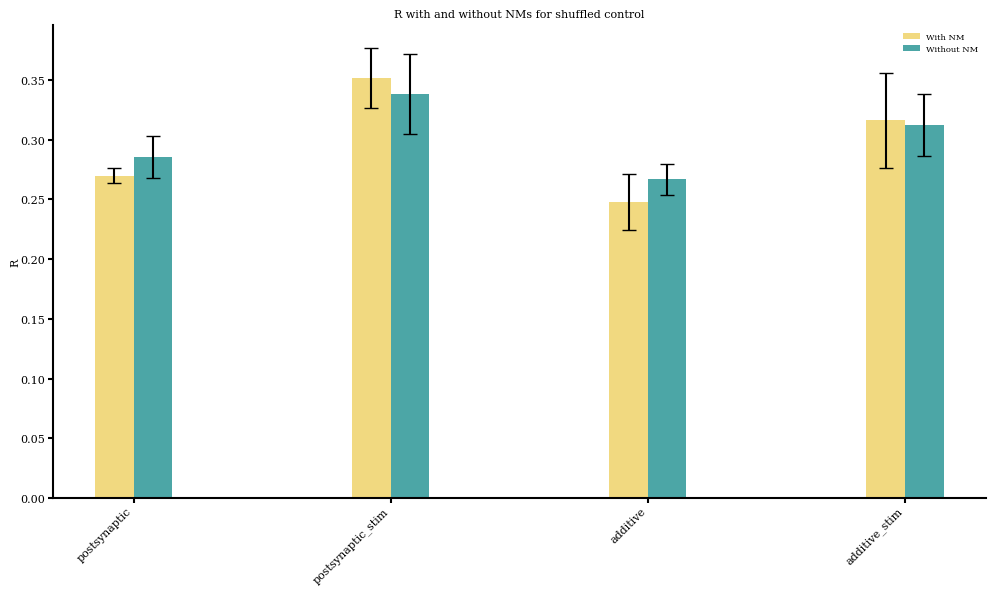

In [33]:
# do sanity checks with controls 
rs = [r_vals_reward, r_vals_reward_cut]
plot_grouped_bars(rs, 'sanity_check_r_control_reward.png', dict_labels=['With NM', 'Without NM'], title="R with and without NMs for shuffled control", y_label="R")

In [60]:
results_dir = '../../results' 
with open(os.path.join(results_dir, 'nk341_rank_20_kl_divs.pkl'), "rb") as f:
    kl_divs_rank_20 = pickle.load(f)
plot_grouped_bars_by_dict([kl_divs_rank_20[0]], figname='nk341_kl_div_benchmark.png', title="KL-Div baseline comparison", x_labels=['baseline'], y_label="Kl-Div")

NameError: name 'pickle' is not defined

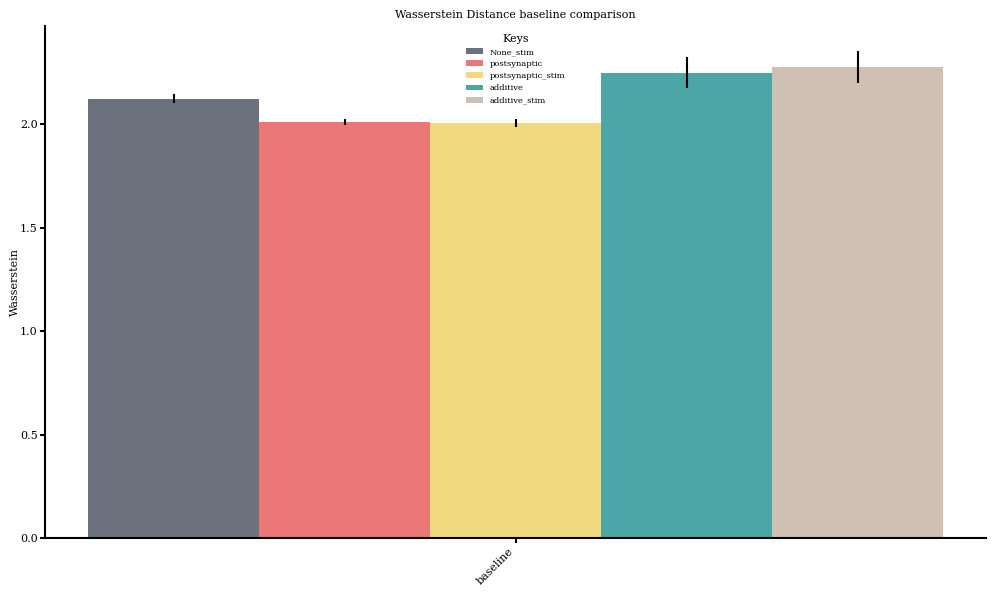

In [142]:
results_dir = '../../results' 
with open(os.path.join(results_dir, 'nk341_rank_20_was_dists.pkl'), "rb") as f:
    was_dists_rank_20 = pickle.load(f)
plot_grouped_bars_by_dict([was_dists_rank_20[0]], figname='nk341_was_dists_benchmark.png', title="Wasserstein Distance baseline comparison", x_labels=['baseline'], y_label="Wasserstein")

In [146]:
np.array(was_dists_rank_20[0]['None_stim']).mean(), np.array(was_dists_rank_20[0]['None_stim']).std()

(2.124202341958127, 0.06212136500610221)

In [147]:
np.array(was_dists_rank_20[0]['postsynaptic']).mean(), np.array(was_dists_rank_20[0]['postsynaptic']).std()

(2.009872189926675, 0.04396666711090015)

In [148]:
np.array(was_dists_rank_20[0]['postsynaptic_stim']).mean(), np.array(was_dists_rank_20[0]['postsynaptic_stim']).std()

(2.0065302578315785, 0.057704303900682756)

In [149]:
np.array(was_dists_rank_20[0]['additive']).mean(), np.array(was_dists_rank_20[0]['additive']).std()

(2.248761104647531, 0.22225118213150455)

In [150]:
np.array(was_dists_rank_20[0]['additive_stim']).mean(), np.array(was_dists_rank_20[0]['additive_stim']).std()

(2.277078399359513, 0.23526154217575512)

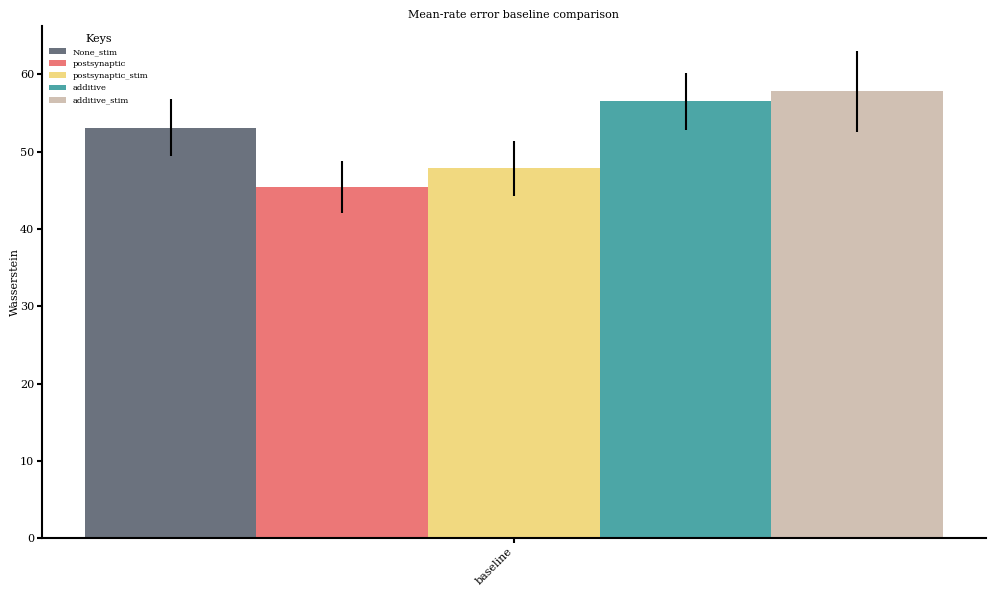

In [143]:
results_dir = '../../results' 
with open(os.path.join(results_dir, 'nk341_rank_20_mres.pkl'), "rb") as f:
    mres_rank_20 = pickle.load(f)
plot_grouped_bars_by_dict([mres_rank_20[0]], figname='nk341_mres_benchmark.png', title="Mean-rate error baseline comparison", x_labels=['baseline'], y_label="Wasserstein")

In [153]:
np.array(mres_rank_20[0]['None_stim']).mean(), np.array(mres_rank_20[0]['None_stim']).std() / len(mres_rank_20[0]['None_stim'])

(53.115776773629534, 1.116547389235083)

In [155]:
np.array(mres_rank_20[0]['postsynaptic']).mean(), np.array(mres_rank_20[0]['postsynaptic']).std() / len(mres_rank_20[0]['postsynaptic'])

(45.43016216243675, 1.0184497371453982)

In [156]:
np.array(mres_rank_20[0]['postsynaptic_stim']).mean(), np.array(mres_rank_20[0]['postsynaptic_stim']).std() / len(mres_rank_20[0]['postsynaptic_stim'])

(47.831680780094665, 1.081981332050724)

In [157]:
np.array(mres_rank_20[0]['additive']).mean(), np.array(mres_rank_20[0]['additive']).std() / len(mres_rank_20[0]['additive'])

(56.49495157210398, 1.1148682270682193)

In [158]:
np.array(mres_rank_20[0]['additive_stim']).mean(), np.array(mres_rank_20[0]['additive_stim']).std() / len(mres_rank_20[0]['additive_stim'])

(57.803104631521535, 1.5773662379190792)

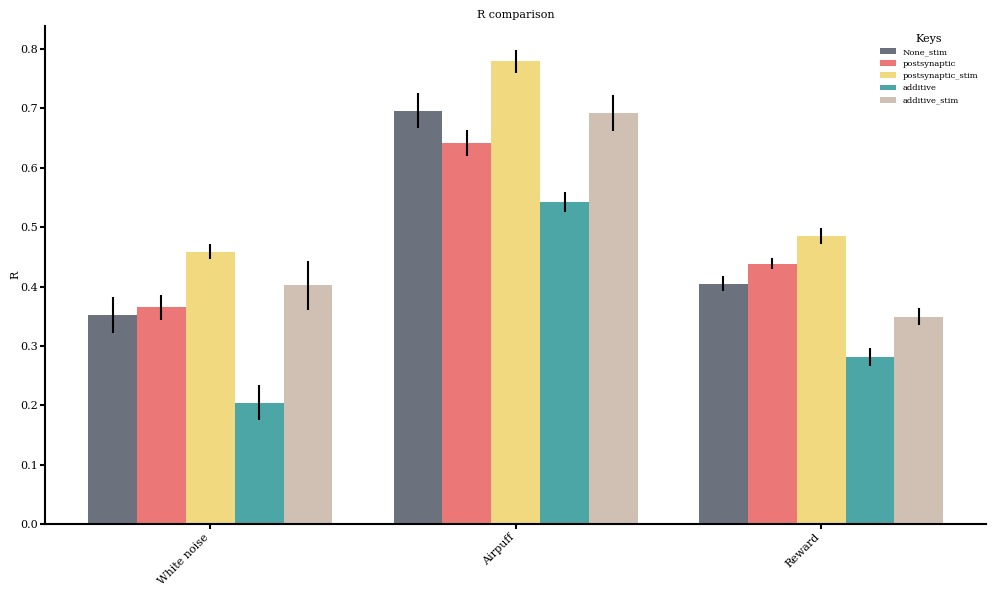

In [183]:
results_dir = '../../results' 
with open(os.path.join(results_dir, 'nk341_rank_20_r.pkl'), "rb") as f:
    rs_rank_20 = pickle.load(f)
plot_grouped_bars_by_dict(rs_rank_20[1:], figname='nk341_r_benchmark.png', title="R comparison", x_labels=['White noise', 'Airpuff', 'Reward'], y_label="R")


In [50]:
compute_stats(odor_blocks[0][0], odor_blocks[0][1], 'airpuff_1', num_trajs=5)

None
no input
n outliers: 0.0017500000000000293
Sample 0, KL Div: 2.542581558227539, Wasserstein: 2.8506701750975063, r: 0.30092920618382935, PSH: 0.2217498959028715, mean-rate: 15.976445500652744
no input
n outliers: 0.0034999999999999476
Sample 1, KL Div: 2.405735969543457, Wasserstein: 2.718154979721994, r: 0.3199186455808345, PSH: 0.23586405905216462, mean-rate: 14.35436955246209
no input
n outliers: 0.0017500000000000293
Sample 2, KL Div: 2.3981850147247314, Wasserstein: 2.9406919411388, r: 0.3763258787298984, PSH: 0.23904384518151836, mean-rate: 17.348996836655907
no input
n outliers: 0.0030000000000000027
Sample 3, KL Div: 2.519963502883911, Wasserstein: 2.8447438455192278, r: 0.3126710814173366, PSH: 0.24242985229812128, mean-rate: 15.988555222878913
no input
n outliers: 0.003249999999999975
Sample 4, KL Div: 2.7865407466888428, Wasserstein: 3.179095324838463, r: 0.33303338096229673, PSH: 0.23273008521097066, mean-rate: 20.45730118522947
None
KL Div: 2.5306013584136964 std: 0.1

In [65]:
trajs = {}
# fig, ax = plt.subplots(len(list(models.keys())), 2, figsize=(8,12))
t_start, t_end = airpuff_block[0], airpuff_block[1]
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
for i, model in enumerate(models.keys()):
    print(model)
    neuromod = model
    trajs[neuromod] = get_trajectory(t_start, t_end, models[model], neuromod, stim_idx=-1)

None
no input
additive
no input
postsynaptic
no input
presynaptic
no input
rank
no input


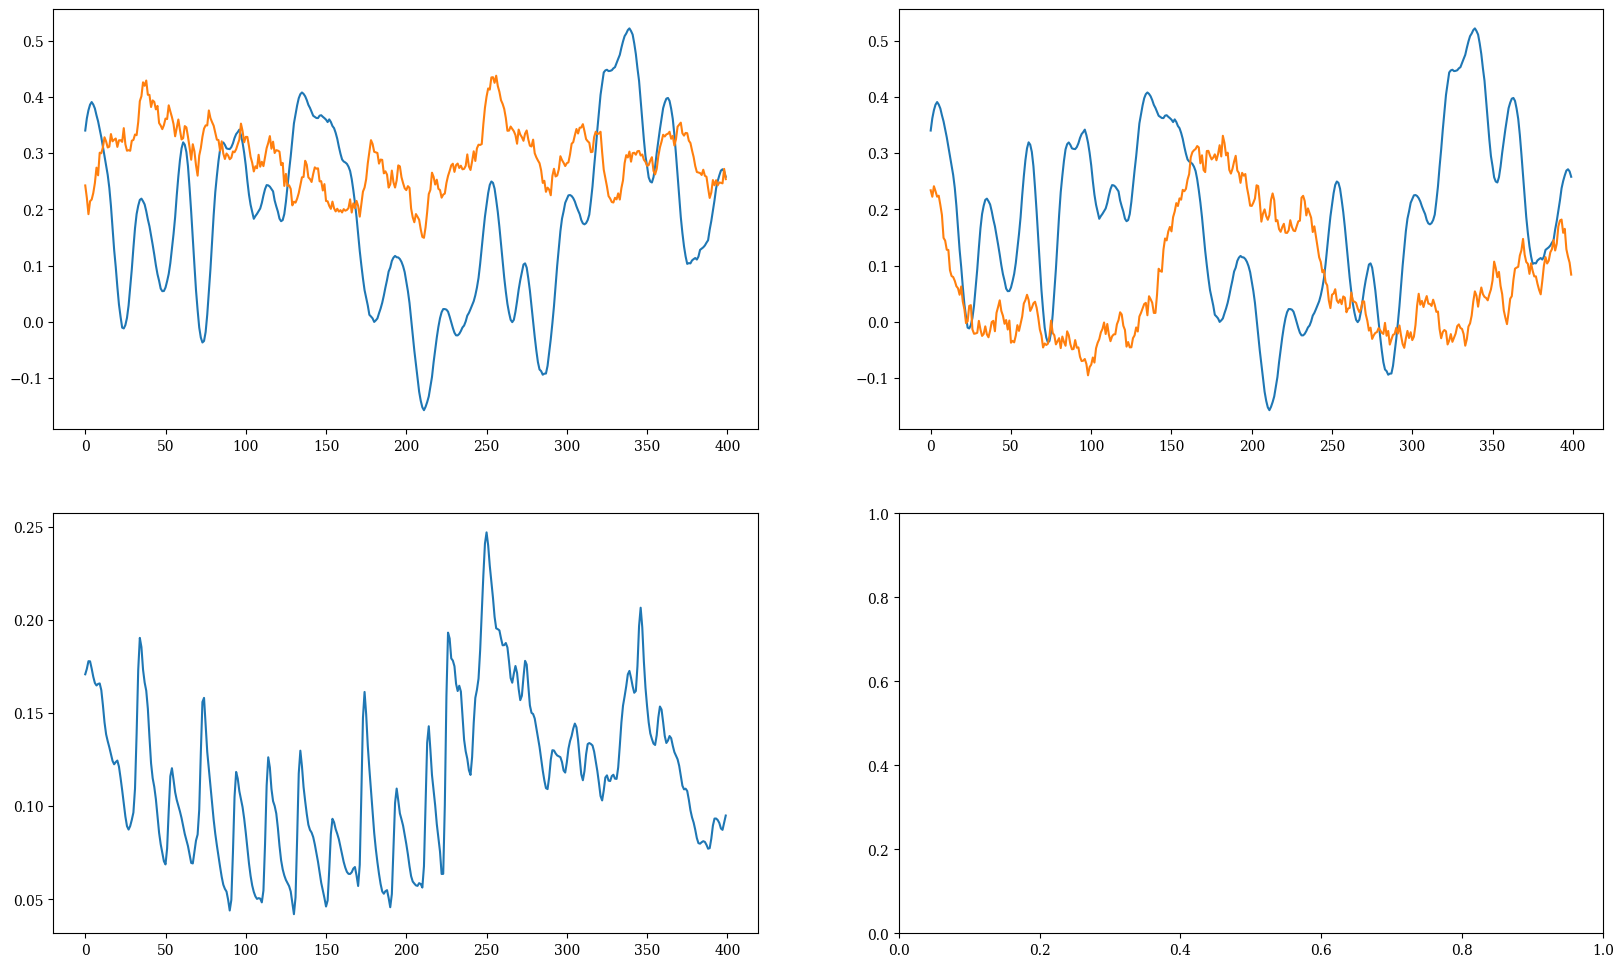

In [259]:
neuron_idx = 61
fig, ax = plt.subplots(2, 2, figsize=(20, 12))
ax[0, 0].plot(spike_counts_val[neuron_idx])
ax[0, 0].plot(trajs['postsynaptic'][neuron_idx].detach())
ax[0, 1].plot(spike_counts_val[neuron_idx])
ax[0, 1].plot(trajs['None'][neuron_idx].detach())
ax[1, 0].plot(neuromod_val)

In [36]:
from sklearn.metrics import r2_score
# compute R for all neurons

prs_post, prs_post_stim, prs_none = [], [], []
r2s_add, r2s_pre, r2s_rank = [], [], []

# nm_neurons = torch.argsort(models['additive'].rnn.transition.A[:, 0].abs(), descending=True)
eval_count = -1

for i in range(spike_counts_val.shape[0]):
    # pr_add = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['additive'][nm_neurons[i]].flatten().detach())[0]
    # pr_pre = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['presynaptic'][nm_neurons[i]].flatten().detach())[0]
    # pr_post = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['postsynaptic'][nm_neurons[i]].flatten().detach())[0]
    # pr_rank = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['rank'][nm_neurons[i]].flatten().detach())[0]

    # pr_add = pearsonr(spike_counts_val[i].flatten(), trajs['additive'][i].flatten().detach())[0]
    pr_post = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic'][i].flatten().detach())[0]
    pr_post_stim = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic_stim'][i].flatten().detach())[0]
    # pr_rank = pearsonr(spike_counts_val[i].flatten(), trajs['rank'][i].flatten().detach())[0]
    pr_none = pearsonr(spike_counts_val[i].flatten(), trajs['None_stim'][i].flatten().detach())[0]
    # r2_add = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[0]][nm_neurons[i]].flatten().detach())[0]
    # r2_pre = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[2]][nm_neurons[i]].flatten().detach())[0]
    # r2_rank = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[3]][nm_neurons[i]].flatten().detach())[0]
    
    # prs_add.append(pr_add)
    prs_post.append(pr_post)
    # prs_rank.append(pr_rank)
    prs_post_stim.append(pr_post_stim)
    prs_none.append(pr_none)
    
    # r2s_add.append(r2_add)
    # r2s_pre.append(r2_pre)
    # r2s_rank.append(r2_rank)

prs_post = np.nan_to_num(prs_post)
prs_post_stim = np.nan_to_num(prs_post_stim)
prs_none = np.nan_to_num(prs_none)

prs_post, prs_post_stim, prs_none = np.array(prs_post), np.array(prs_post_stim), np.array(prs_none)
print(prs_post.mean(), prs_post.std())
print(prs_post_stim.mean(), prs_post_stim.std())
print(prs_none.mean(), prs_none.std())


0.1918461079956062 0.21079314603306684
0.23368979403681908 0.22869315961174694
0.04429139024210413 0.12435710122104371


/tmp/ipykernel_811675/1657303872.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_post = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic'][i].flatten().detach())[0]
/tmp/ipykernel_811675/1657303872.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_post_stim = pearsonr(spike_counts_val[i].flatten(), trajs['postsynaptic_stim'][i].flatten().detach())[0]
/tmp/ipykernel_811675/1657303872.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_none = pearsonr(spike_counts_val[i].flatten(), trajs['None_stim'][i].flatten().detach())[0]


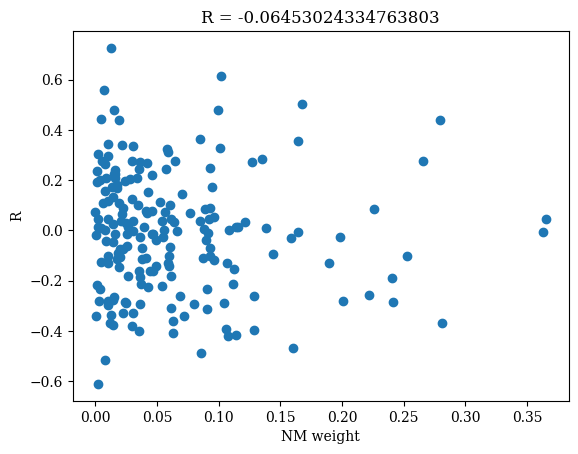

In [67]:
plt.scatter(models['additive'].rnn.transition.A[nm_neurons].abs().detach(), prs_add)
prs_add = np.nan_to_num(prs_add)
r = pearsonr(models['additive'].rnn.transition.A[nm_neurons].abs().detach().flatten(), prs_add)[0]
plt.title(f'R = {r}')
plt.ylabel('R')
plt.xlabel('NM weight')
plt.savefig('RvsNM.png')

Text(0.5, 1.0, 'R = 0.48450503955096835')

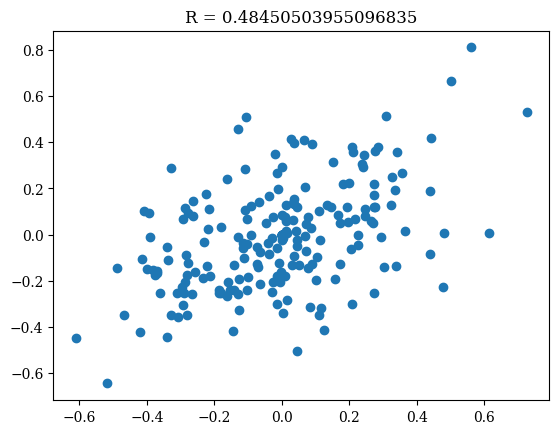

In [68]:
prs_none = np.nan_to_num(prs_none)
prs_add = np.nan_to_num(prs_add)
plt.scatter(prs_add, prs_none)
r = pearsonr(prs_none, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_none.png')

Text(0.5, 1.0, 'R = -0.024641234199474255')

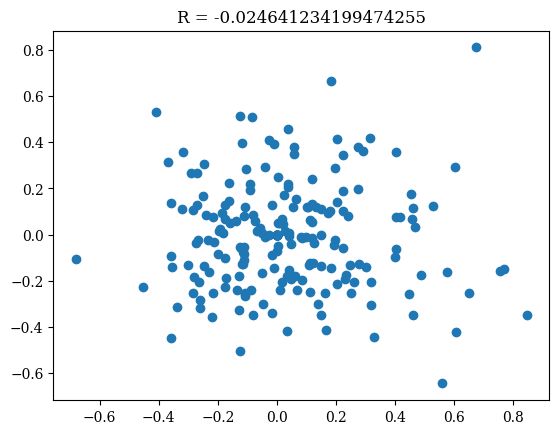

In [69]:
prs_none = np.nan_to_num(prs_none)
prs_pre = np.nan_to_num(prs_pre)
plt.scatter(prs_pre, prs_none)
r = pearsonr(prs_none, prs_pre)
plt.title(f'R = {r[0]}')
# plt.savefig('R_pre_vs_none.png')

Text(0.5, 1.0, 'R = -0.11609061783858497')

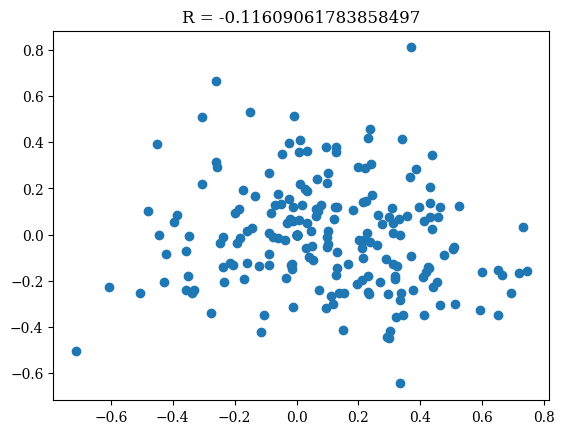

In [70]:
prs_none = np.nan_to_num(prs_none)
prs_post = np.nan_to_num(prs_post)
plt.scatter(prs_post, prs_none)
r = pearsonr(prs_none, prs_post)
plt.title(f'R = {r[0]}')
# plt.savefig('R_post_vs_none.png')

Text(0.5, 1.0, 'R = -0.05225042496650859')

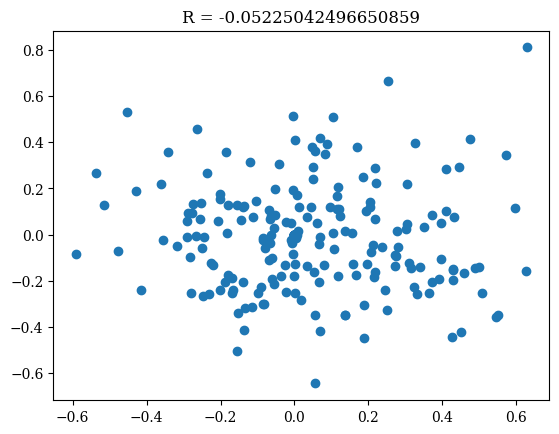

In [71]:
prs_none = np.nan_to_num(prs_none)
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_rank, prs_none)
r = pearsonr(prs_none, prs_rank)
plt.title(f'R = {r[0]}')
# plt.savefig('R_rank_vs_none.png')

Text(0.5, 1.0, 'R = -0.13505273976144935')

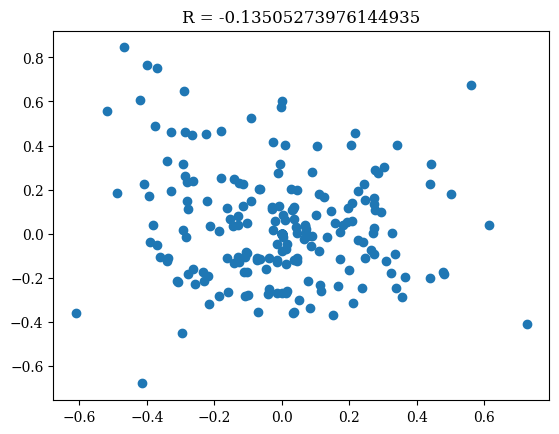

In [72]:
prs_pre = np.nan_to_num(prs_pre)
plt.scatter(prs_add, prs_pre)
r = pearsonr(prs_pre, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_pre.png')

Text(0.5, 1.0, 'R = -0.2360344818534013')

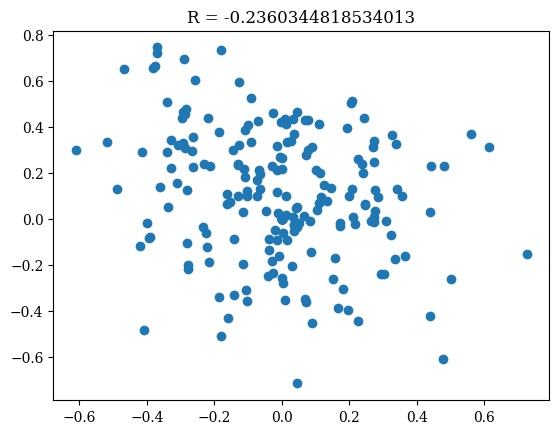

In [73]:
prs_post = np.nan_to_num(prs_post)
plt.scatter(prs_add, prs_post)
r = pearsonr(prs_post, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_post.png')

Text(0.5, 1.0, 'R = 0.20242007189266847')

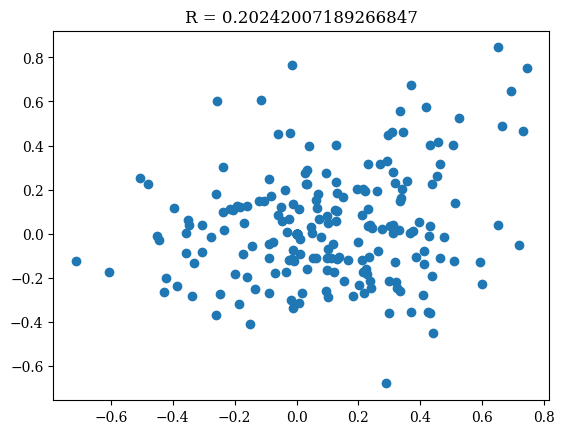

In [74]:
prs_pre = np.nan_to_num(prs_pre)
plt.scatter(prs_post, prs_pre)
r = pearsonr(prs_pre, prs_post)
plt.title(f'R = {r[0]}')
# plt.savefig('R_post_vs_pre.png')

Text(0.5, 1.0, 'R = -0.2773955851405411')

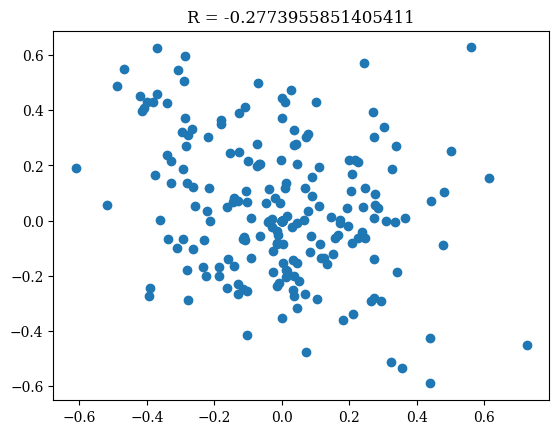

In [75]:
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_add, prs_rank)
r = pearsonr(prs_rank, prs_add)
plt.title(f'R = {r[0]}')
# plt.savefig('R_add_vs_rank.png')

Text(0.5, 1.0, 'R = 0.3452199263972028')

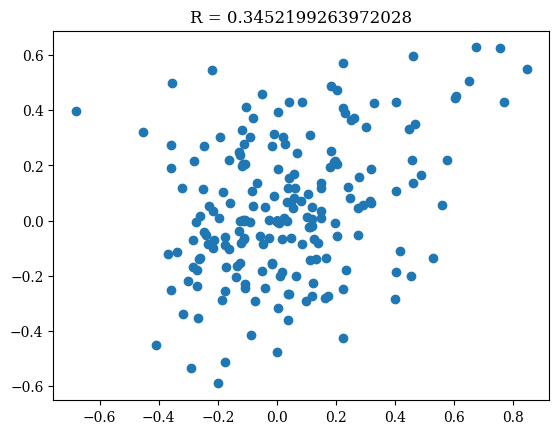

In [76]:
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_pre, prs_rank)
r = pearsonr(prs_rank, prs_pre)
plt.title(f'R = {r[0]}')
# plt.savefig('R_rank_vs_pre.png')

Text(0.5, 1.0, 'R = 0.43076061859176606')

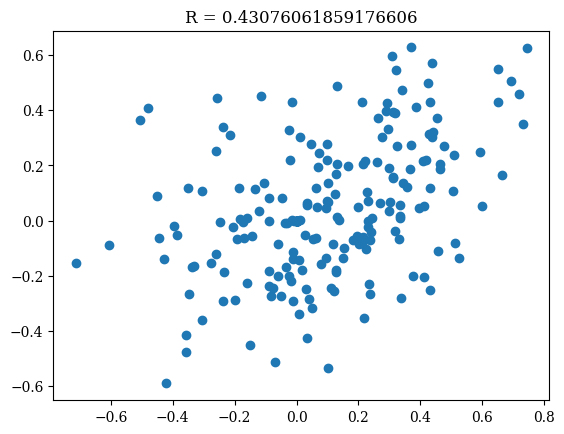

In [77]:
prs_rank = np.nan_to_num(prs_rank)
plt.scatter(prs_post, prs_rank)
r = pearsonr(prs_rank, prs_post)
plt.title(f'R = {r[0]}')
# plt.savefig('R_rank_vs_post.png')

<Axes: >

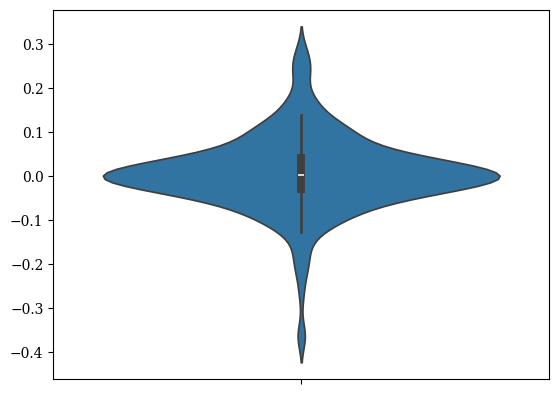

In [78]:
sns.violinplot(models['additive'].rnn.transition.A.detach().flatten())
# plt.savefig('violin_additive.png')

{'whiskers': [<matplotlib.lines.Line2D at 0x7efbeb8b2080>,
 'caps': [<matplotlib.lines.Line2D at 0x7efbeb8b1210>,
 'boxes': [<matplotlib.lines.Line2D at 0x7efbeb8b1f60>],
 'medians': [<matplotlib.lines.Line2D at 0x7efbeb8b1b10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7efbeb8b3b50>],
 'means': []}

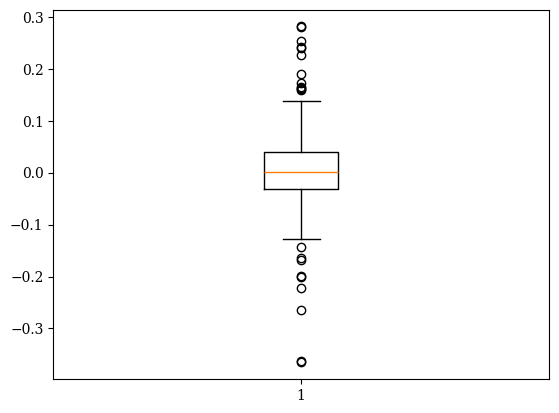

In [79]:
plt.boxplot(models['additive'].rnn.transition.A.detach().flatten())
# plt.savefig('boxplot_additive.png')

<Axes: >

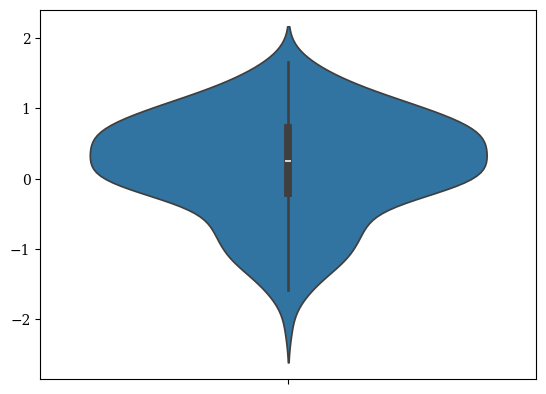

In [80]:
sns.violinplot(models['postsynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('violin_postsynaptic.png')

<Axes: >

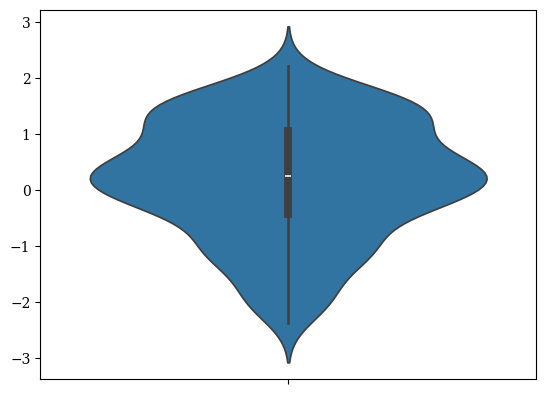

In [81]:
sns.violinplot(models['presynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('violin_presynaptic.png')

{'whiskers': [<matplotlib.lines.Line2D at 0x7efb55e5bbb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7efbeb23c0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7efb55e5b8b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7efbeb23c6d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7efbeb23c9d0>],
 'means': []}

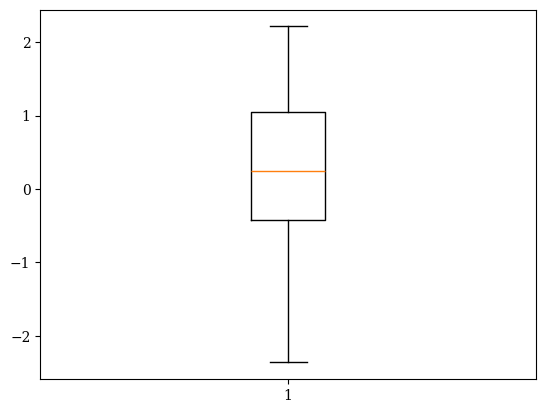

In [82]:
plt.boxplot(models['presynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('boxplot_presynaptic.png')

{'whiskers': [<matplotlib.lines.Line2D at 0x7efbeb1eda50>,
 'caps': [<matplotlib.lines.Line2D at 0x7efbeb1ee050>,
 'boxes': [<matplotlib.lines.Line2D at 0x7efbeb1ed750>],
 'medians': [<matplotlib.lines.Line2D at 0x7efbeb1ee650>],
 'fliers': [<matplotlib.lines.Line2D at 0x7efbeb1ee890>],
 'means': []}

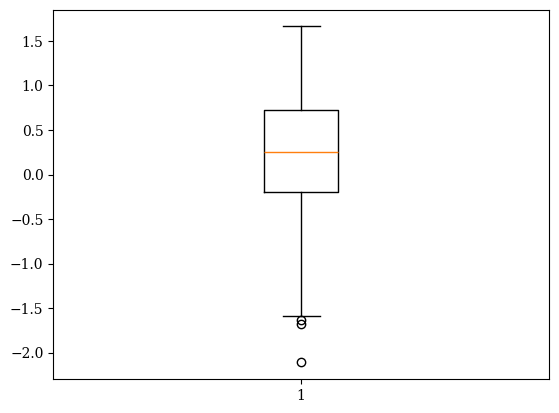

In [83]:
plt.boxplot(models['postsynaptic'].rnn.transition.A.detach().flatten())
# plt.savefig('boxplot_postsynaptic.png')

In [117]:
locations = np.array(['null' for i in range(spike_counts_val.shape[0])])
locations[0:95] = 'DTT'
locations[95:142] = 'DP'
locations[142:167] = 'IL'
locations[167:190] = 'PL'
locations[190:226] = 'Cg'
locations[226:] = 'M2'

## Analysis of models trained on baseline and white noise period

In [175]:
odor_blocks

[[620, 640], [661, 681], [702, 722], [4642, 4662], [4683, 4703], [4724, 4744]]

In [177]:
spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
spike_counts_white_noise_1, s_white_noise_1 = get_block(spike_counts, neuromod_activity, white_noise_blocks[0][0], white_noise_blocks[3][1])
spike_counts_airpuff_1, s_airpuff_1 = get_block(spike_counts, neuromod_activity, airpuff_blocks[0][0], airpuff_blocks[2][1])
spike_counts_odor_1, s_odor_1 = get_block(spike_counts, neuromod_activity, odor_blocks[0][0], odor_blocks[2][1])
spike_counts_reward_1, s_reward_1 = get_block(spike_counts, neuromod_activity, reward_blocks[0][0], reward_blocks[3][1])

s_min = np.min([s_pt_baseline.min(), s_white_noise_1.min(), s_airpuff_1.min(), s_odor_1.min(), s_reward_1.min()])
s_max = np.max([s_pt_baseline.max(), s_white_noise_1.max(), s_airpuff_1.max(), s_odor_1.max(), s_reward_1.max()])

s_pt_baseline = (s_max - s_min) / (s_max - s_min)
s_white_noise_1 = (s_max - s_min) / (s_max - s_min) 
s_airpuff_1 = (s_max - s_min) / (s_max - s_min) 
s_odor_1 = (s_max - s_min) / (s_max - s_min)
s_reward_1 = (s_max - s_min) / (s_max - s_min)

spike_counts_train = np.hstack([spike_counts_pt_baseline, spike_counts_white_noise_1, spike_counts_airpuff_1, spike_counts_odor_1, spike_counts_reward_1])
s_train = np.hstack([s_pt_baseline, s_white_noise_1, s_airpuff_1, s_odor_1, s_reward_1])

In [163]:
models = {}
neuromodulation = ['None', 'postsynaptic', 'presynaptic', 'rank']
for neuromod in neuromodulation:
    try:
        vae, params, task_params, training_params = load_model(f'../../models/dtt/all_{neuromod}_rank_4_multi_block')
            
        models[neuromod] = vae
    except: 
        print(f'Not found: {neuromod}')  


dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: presynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'dim_u', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: rank
using clipped ReLU activation
using uniform init
weight scaler 1


In [164]:
models.keys()

dict_keys(['None', 'postsynaptic', 'presynaptic', 'rank'])

In [160]:
models['presynaptic'].rnn.transition.Wu.shape

torch.Size([231, 5])

In [179]:
t_start, t_end = t_start_post_trial - 600, t_start_post_trial
# t_start, t_end = odor_blocks[-1][0] - 10, odor_blocks[-1][1] + 10
print(t_start, t_end)
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)

6369 6669


In [84]:
trajs = {}
# fig, ax = plt.subplots(len(list(models.keys())), 2, figsize=(8,12))
spike_counts_val, neuromod_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
for i, model in enumerate(models.keys()):
    print(model)
    neuromod = model
    trajs[neuromod] = get_trajectory(t_start, t_end, models[model], neuromod, stim_idx=0)


None
no input
additive
no input
postsynaptic
no input
presynaptic
no input
rank
no input


/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


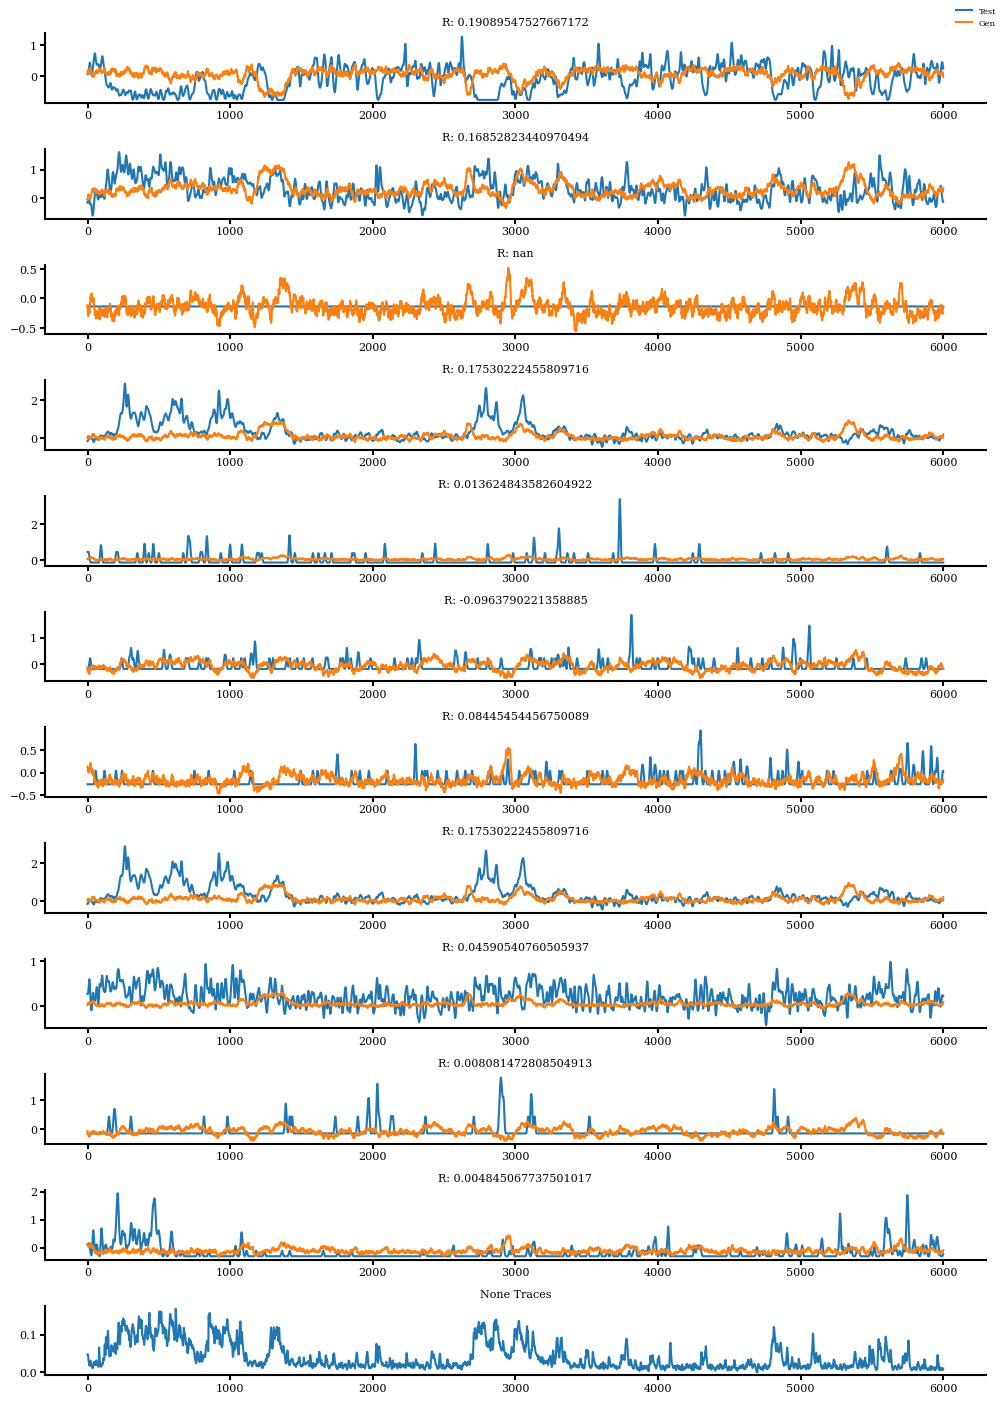

In [167]:
neurons = [172, 50, 15, 167, 30, 40, 80, 167, 90, 200, 10]
plot_traces(neurons, trajs['None'], spike_counts_val, neuromod_val, 'None')

/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


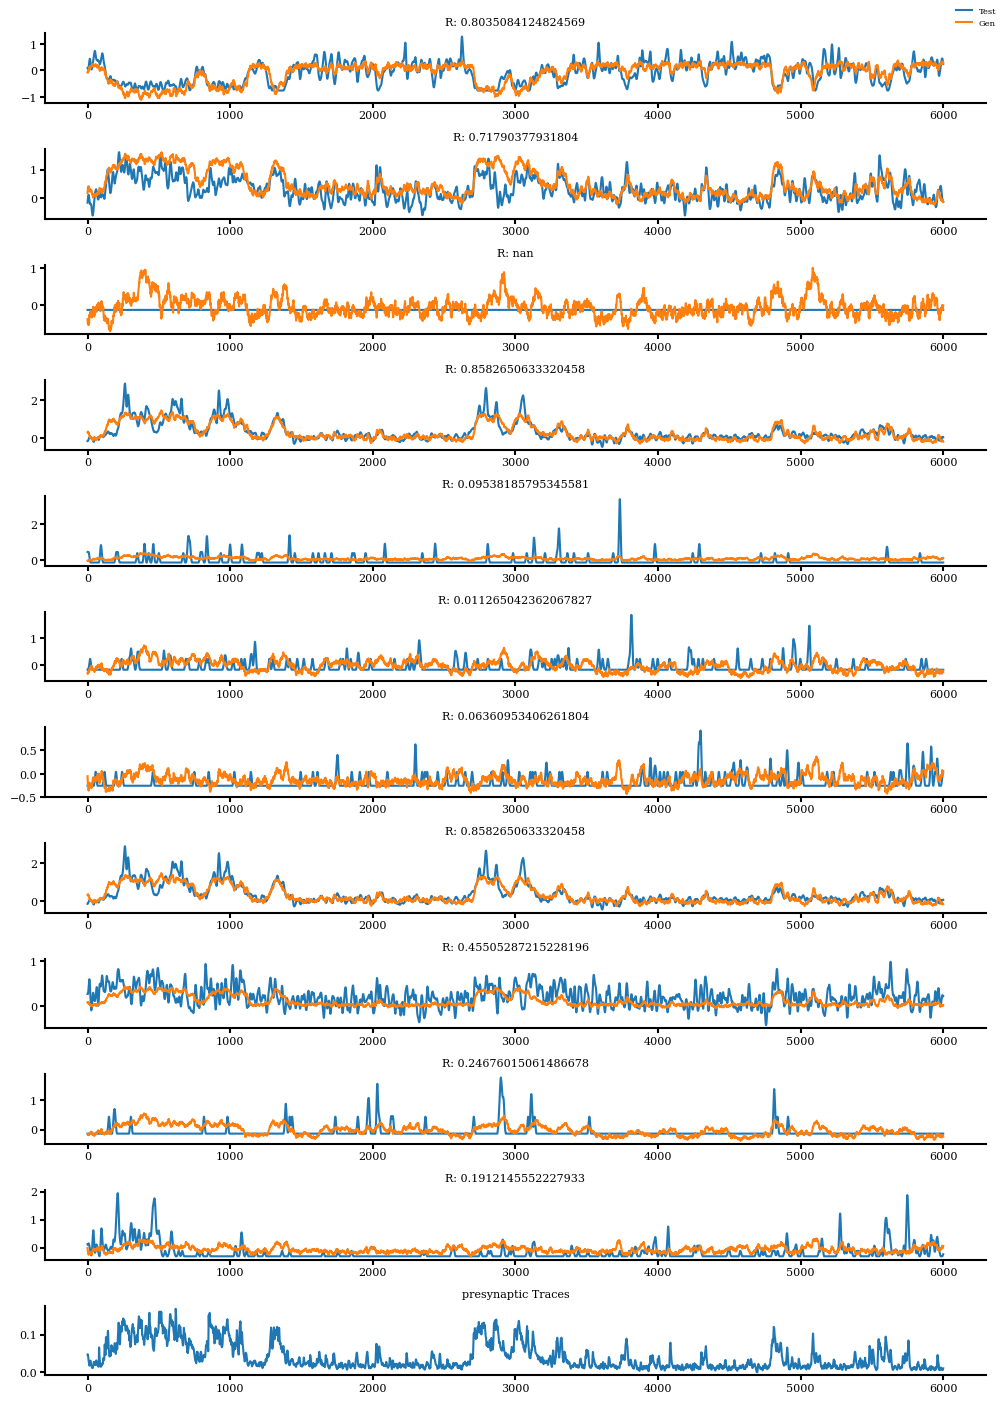

In [168]:
plot_traces(neurons, trajs['presynaptic'], spike_counts_val, neuromod_val, 'presynaptic')

/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


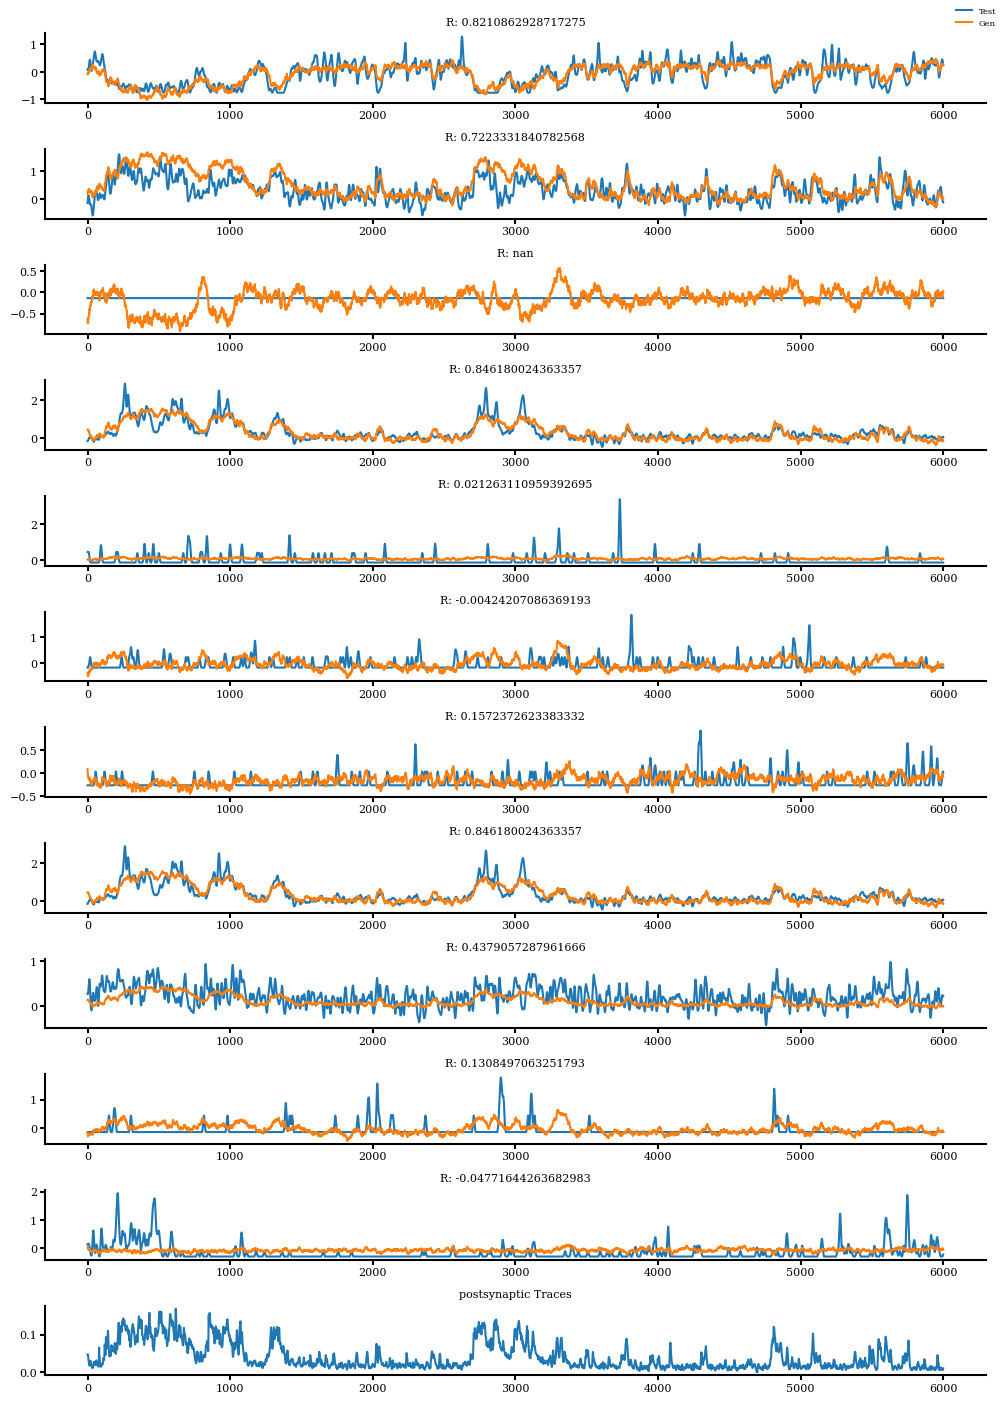

In [169]:
plot_traces(neurons, trajs['postsynaptic'], spike_counts_val, neuromod_val, 'postsynaptic')

/tmp/ipykernel_255501/2050085279.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')


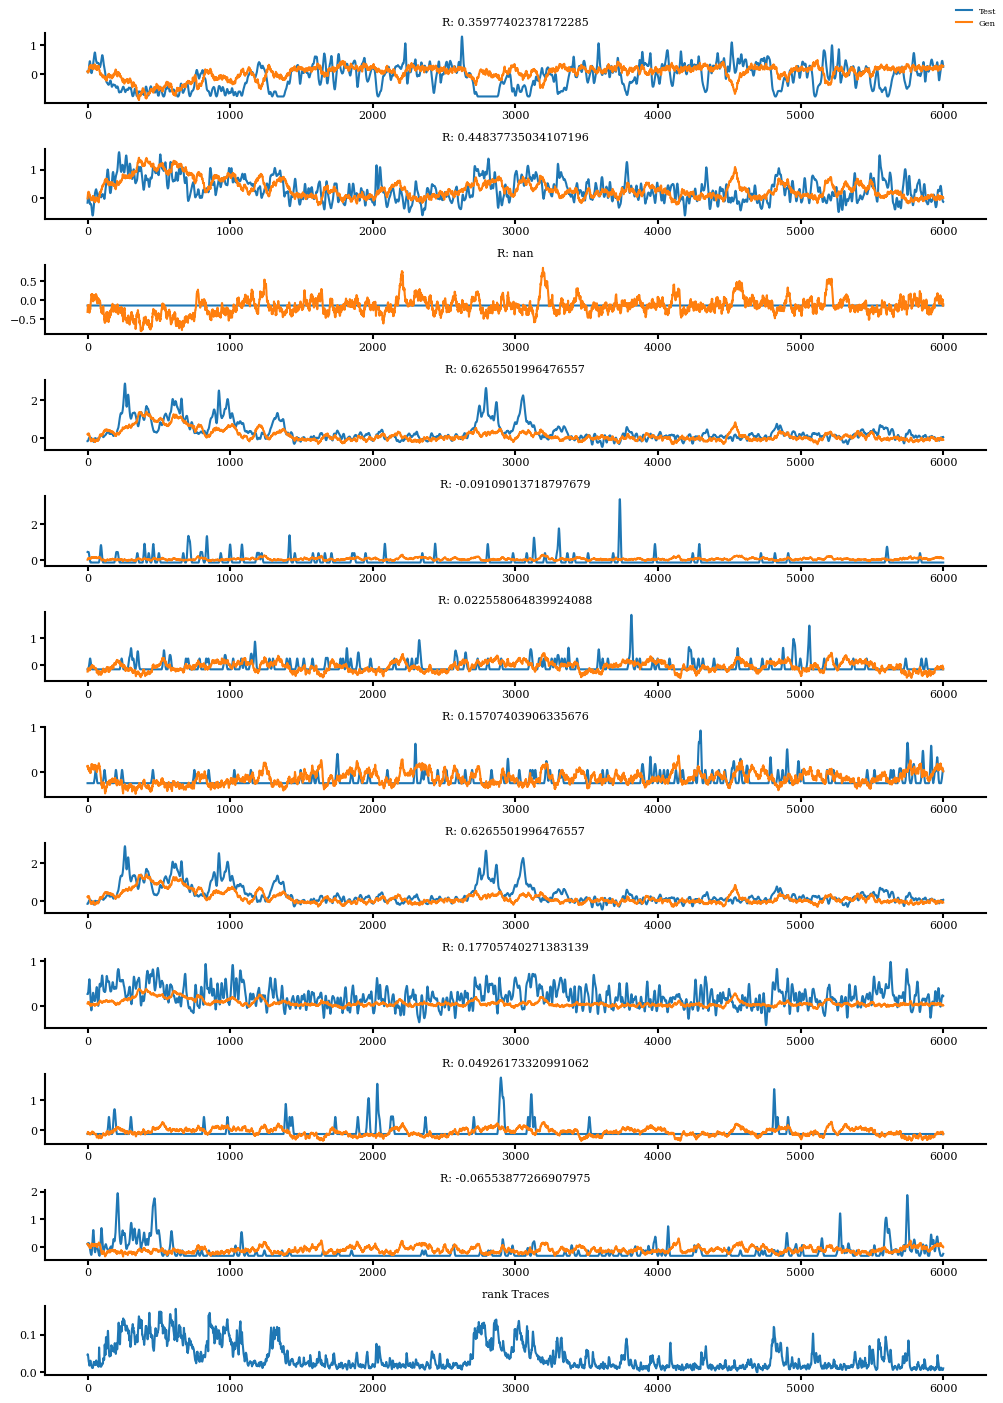

In [181]:
plot_traces(neurons, trajs['rank'], spike_counts_val, neuromod_val, 'rank')

### Compute stats for validation period

In [189]:
compute_stats(t_start_post_trial - 900, t_start_post_trial, 'validation', num_trajs=5, stim_idx=0)

None
n outliers: 0.96975
Sample 0, KL Div: 1.1965466737747192, Wasserstein: 4.670493015725777, r: 0.5562049367420595, PSH: 0.24233645514419125, mean-rate: 179.64935431677463
n outliers: 0.9765
Sample 1, KL Div: 1.0739612579345703, Wasserstein: 4.567135561265078, r: 0.5551511864780264, PSH: 0.24283987541098123, mean-rate: 187.82443700412324
n outliers: 0.975
Sample 2, KL Div: 1.3255330324172974, Wasserstein: 4.5594336478633, r: 0.5553305877327995, PSH: 0.24219192010900942, mean-rate: 180.6851236277217
n outliers: 0.975
Sample 3, KL Div: 0.8310631513595581, Wasserstein: 4.699804776600444, r: 0.5605053248121112, PSH: 0.24221672553339113, mean-rate: 177.01354414655808
n outliers: 0.97525
Sample 4, KL Div: 1.2825889587402344, Wasserstein: 4.48550508960762, r: 0.5534969234651925, PSH: 0.2435958376437699, mean-rate: 175.9135308662748
None
KL Div: 1.141938614845276 std: 0.17761528332406912
Wasserstein dist: 4.596474418212444 std: 0.07836184636476436
Mean rate error: 180.2171979922905 std: 4.17

In [172]:
compute_stats(white_noise_blocks[4][0], white_noise_blocks[-1][1], 'wn_white_noise', num_trajs=5, stim_idx=1)

None
n outliers: 0.982
Sample 0, KL Div: 2.3475658893585205, Wasserstein: 5.514312876074141, r: 0.40013248615697183, PSH: 0.2502857814315793, mean-rate: 96.92219300023561
n outliers: 0.9835
Sample 1, KL Div: 2.6472246646881104, Wasserstein: 5.642112671443937, r: 0.3807835824290695, PSH: 0.25035132630620743, mean-rate: 106.9817751301165
n outliers: 0.98725
Sample 2, KL Div: 2.1875510215759277, Wasserstein: 5.6139846759076315, r: 0.385000787794307, PSH: 0.24971197840886467, mean-rate: 107.08944535930824
n outliers: 0.98325
Sample 3, KL Div: 2.403130292892456, Wasserstein: 5.795287980546943, r: 0.36594145463570854, PSH: 0.25143458610394503, mean-rate: 124.18689063434502
n outliers: 0.983
Sample 4, KL Div: 2.288914442062378, Wasserstein: 5.559730849678189, r: 0.3770867467358233, PSH: 0.24890235516747128, mean-rate: 97.71289441831192
None
KL Div: 2.3748772621154783 std: 0.15375173452301402
Wasserstein dist: 5.625085810730168 std: 0.09583719713855032
Mean rate error: 106.57863970846347 std: 

In [173]:
compute_stats(airpuff_blocks[3][0], airpuff_blocks[-1][1], 'airpuff_1_white_noise', num_trajs=5, stim_idx=2)

None
n outliers: 0.98125
Sample 0, KL Div: 0.8127425909042358, Wasserstein: 5.387342503334823, r: 0.5469553171905233, PSH: 0.24324239616262336, mean-rate: 55.24170511477
n outliers: 0.9795
Sample 1, KL Div: 1.482690453529358, Wasserstein: 5.287692822980489, r: 0.5126019418204715, PSH: 0.23893972562328866, mean-rate: 51.389415542138714
n outliers: 0.9795
Sample 2, KL Div: 1.508624792098999, Wasserstein: 5.195634900995861, r: 0.5103662859941661, PSH: 0.24000861541755716, mean-rate: 44.08051852666714
n outliers: 0.98575
Sample 3, KL Div: 1.3563071489334106, Wasserstein: 5.211938937207543, r: 0.525940604859808, PSH: 0.24364227004770847, mean-rate: 47.12697440352802
n outliers: 0.98375
Sample 4, KL Div: 1.6292064189910889, Wasserstein: 5.26633575351857, r: 0.5141360314095245, PSH: 0.237040771101358, mean-rate: 47.70900817232782
None
KL Div: 1.3579142808914184 std: 0.2860408817207516
Wasserstein dist: 5.269788983607457 std: 0.06781851974066373
Mean rate error: 49.109524351886336 std: 3.84667

In [184]:
reward_blocks

[[865, 885],
 [884, 904],
 [903, 923],
 [923, 943],
 [1039, 1059],
 [1058, 1078],
 [1078, 1098],
 [1219, 1239],
 [1238, 1258],
 [1258, 1278],
 [1277, 1297],
 [1393, 1413],
 [1413, 1433],
 [1432, 1452],
 [1573, 1593],
 [1592, 1612],
 [1612, 1632],
 [1631, 1651],
 [1747, 1767],
 [1767, 1787],
 [1786, 1806],
 [1927, 1947],
 [1947, 1967],
 [1966, 1986],
 [1985, 2005],
 [2102, 2122],
 [2121, 2141],
 [2140, 2160],
 [2550, 2570],
 [2570, 2590],
 [2589, 2609],
 [2608, 2628],
 [2725, 2745],
 [2744, 2764],
 [2763, 2783],
 [3194, 3214],
 [3213, 3233],
 [3232, 3252],
 [3252, 3272],
 [3368, 3388],
 [3387, 3407],
 [3406, 3426],
 [4106, 4126],
 [4125, 4145],
 [4145, 4165],
 [4164, 4184],
 [4280, 4300],
 [4300, 4320],
 [4319, 4339]]

In [185]:
compute_stats(odor_blocks[0][0], odor_blocks[2][1], 'airpuff_1_white_noise', num_trajs=5, stim_idx=3)

None
n outliers: 0.96475
Sample 0, KL Div: 0.7415079474449158, Wasserstein: 4.0498165668756085, r: 0.3615854183769701, PSH: 0.18321685006602487, mean-rate: 2.9049687166171396
n outliers: 0.96575
Sample 1, KL Div: 0.3292387127876282, Wasserstein: 4.1188863243453016, r: 0.3401477133313884, PSH: 0.1807545809229789, mean-rate: 5.572854842504378
n outliers: 0.9655
Sample 2, KL Div: 0.6169199347496033, Wasserstein: 4.0558934936036755, r: 0.37030572300306475, PSH: 0.18971744553347714, mean-rate: 1.7511314108018774
n outliers: 0.9652499999999999
Sample 3, KL Div: 1.1674253940582275, Wasserstein: 4.0971129254797445, r: 0.36944543683795805, PSH: 0.18978600474678617, mean-rate: 1.7209679815912564
n outliers: 0.96475
Sample 4, KL Div: 0.5118655562400818, Wasserstein: 4.018454454011927, r: 0.3631100541711306, PSH: 0.18523737717287106, mean-rate: 0.9356931226200562
None
KL Div: 0.6733915090560914 std: 0.2815777505508053
Wasserstein dist: 4.068032752863251 std: 0.03569016933606188
Mean rate error: 2.

KeyboardInterrupt: 

In [187]:
compute_stats(reward_blocks[4][0], reward_blocks[7][1], 'airpuff_1_white_noise', num_trajs=5, stim_idx=4)

None
n outliers: 0.9795
Sample 0, KL Div: 1.4172937870025635, Wasserstein: 5.060168632345354, r: 0.45835210338165233, PSH: 0.2176219617123319, mean-rate: 82.9620732329982
n outliers: 0.9785
Sample 1, KL Div: 1.8406709432601929, Wasserstein: 5.180433338643134, r: 0.4639767808543014, PSH: 0.21774669583132789, mean-rate: 95.67710238066796
n outliers: 0.98025
Sample 2, KL Div: 1.9882924556732178, Wasserstein: 5.040967267637822, r: 0.44837912041133243, PSH: 0.21328632272316034, mean-rate: 83.57680700217904
n outliers: 0.98075
Sample 3, KL Div: 1.7760347127914429, Wasserstein: 5.051536504084917, r: 0.45465652558693903, PSH: 0.21779974442445696, mean-rate: 87.34364503631912
n outliers: 0.979
Sample 4, KL Div: 1.4983490705490112, Wasserstein: 5.061201161959649, r: 0.45287606898829375, PSH: 0.21394013141378593, mean-rate: 86.87414490975605
None
KL Div: 1.7041281938552857 std: 0.21409475571267472
Wasserstein dist: 5.078861380934176 std: 0.05130453682513373
Mean rate error: 87.28675451238408 std: